# Churn Prediction — Customer Purchase Continuation Model
**Goal:** Predict whether a customer who bought in round N-1 will buy again in round N  
**File:** `Churn_2025_1216_0102.csv` — 590,644 customers, 61 purchase rounds  
**Approach:** Feature engineering from purchase history → ML models → Churn probability (0-100%)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Load data
df = pd.read_csv('Churn_2025_1216_0102.csv', low_memory=False)
item_cols = [c for c in df.columns if c.startswith('item')]

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"Purchase rounds: {len(item_cols)} ({item_cols[0]} → {item_cols[-1]})")
print(f"\nlabel_continue distribution:")
print(df['label_continue'].value_counts().sort_index().to_string())

Shape: 590,644 rows x 69 cols
Purchase rounds: 61 (item2023_07_01 → item2026_01_02)

label_continue distribution:
label_continue
0    289314
1    301330


## Phase 1: Data Preparation
- ทุกคนในไฟล์ซื้อในงวด N-1 (`item2025_12_16`)  
- Target: ซื้อต่อในงวด N (`item2026_01_02`) หรือไม่  
- Exclude ลูกค้าใหม่ที่มีข้อมูลแค่ 2 งวด (ไม่พอ predict)

In [2]:
# Convert item columns to numeric matrix
mat = df[item_cols].apply(pd.to_numeric, errors='coerce')

# Find first registered round per customer
first_reg_idx = mat.notna().values.argmax(axis=1)
tenure = len(item_cols) - first_reg_idx  # how many rounds of data

# Exclude: customers with only 2 rounds (first registered in round N-1)
MIN_TENURE = 3
exclude_mask = tenure < MIN_TENURE
df_eligible = df[~exclude_mask].copy()
mat_eligible = mat[~exclude_mask].copy()

# Define target: churn = did NOT buy in round N
last_round = item_cols[-1]
df_eligible['churn'] = (df_eligible[last_round] == 0).astype(int)

print(f"Total customers:          {len(df):,}")
print(f"Excluded (tenure < {MIN_TENURE}):    {exclude_mask.sum():,}")
print(f"Eligible:                 {len(df_eligible):,}")
print(f"\nTarget distribution:")
print(f"  Buy (churn=0):   {(df_eligible['churn']==0).sum():,} ({(df_eligible['churn']==0).mean():.1%})")
print(f"  Churn (churn=1): {(df_eligible['churn']==1).sum():,} ({(df_eligible['churn']==1).mean():.1%})")
print(f"\nTenure stats (eligible):")
tenure_elig = tenure[~exclude_mask]
print(f"  Min: {tenure_elig.min()} | Median: {np.median(tenure_elig):.0f} | Max: {tenure_elig.max()}")

Total customers:          590,644
Excluded (tenure < 3):    19,564
Eligible:                 571,080

Target distribution:
  Buy (churn=0):   295,052 (51.7%)
  Churn (churn=1): 276,028 (48.3%)

Tenure stats (eligible):
  Min: 3 | Median: 44 | Max: 61


## Phase 2: Feature Engineering
สร้าง features จากประวัติการซื้อทุกมิติ:
1. **Lifecycle** — tenure, time to first purchase
2. **Recency** — rounds since last purchase
3. **Frequency** — active rounds, purchase ratio
4. **Volume** — total items, average per round, max
5. **Recent Windows** — items/activity in last 3, 6 rounds
6. **Trend** — slope, recent vs early ratio
7. **Momentum** — EWM, acceleration
8. **Consistency** — std, coefficient of variation
9. **Dormancy** — current/longest zero streak
10. **Purchase Gaps** — avg/std/max gap between purchases
11. **Reactivation** — comeback count after dormancy
12. **Spending Concentration** — Gini coefficient, top-3 rounds share
13. **Tenure Stage** — is_new, is_mature flags

In [3]:
%%time
# IMPORTANT: Features use rounds 1 to N-1 only (exclude round N = target)
feature_item_cols = item_cols[:-1]  # exclude last round
print(f"Feature rounds: {len(feature_item_cols)} ({feature_item_cols[0]} → {feature_item_cols[-1]})")
print(f"Target round: {item_cols[-1]}")

def engineer_features(df_in, mat_in, feat_item_cols):
    """Build all features from purchase history. Uses only specified rounds."""
    mat_feat = mat_in[feat_item_cols]
    n_rounds = len(feat_item_cols)
    mat_vals = mat_feat.values.astype(float)
    registered = ~np.isnan(mat_vals)
    purchased = np.where(registered, mat_vals > 0, False)
    amounts = np.where(registered, mat_vals, 0.0)
    
    feats = pd.DataFrame(index=df_in.index)
    
    # === 1. Lifecycle ===
    has_any_reg = registered.any(axis=1)
    first_reg = np.where(has_any_reg, registered.argmax(axis=1), n_rounds)
    feats['tenure_rounds'] = np.where(has_any_reg, n_rounds - first_reg, 0)
    
    has_any_purchase = purchased.any(axis=1)
    first_purchase = np.where(has_any_purchase, purchased.argmax(axis=1), n_rounds)
    feats['time_to_first_purchase'] = np.where(
        has_any_purchase, first_purchase - first_reg, feats['tenure_rounds'])
    
    # === 2. Recency ===
    rev_purchased = np.flip(purchased, axis=1)
    last_purchase_pos = np.where(has_any_purchase,
                                  n_rounds - 1 - rev_purchased.argmax(axis=1), -1)
    feats['rounds_since_last_purchase'] = np.where(
        has_any_purchase, (n_rounds - 1) - last_purchase_pos, feats['tenure_rounds'])
    
    # === 3. Frequency ===
    feats['total_active_rounds'] = purchased.sum(axis=1)
    registered_count = np.maximum(registered.sum(axis=1), 1)
    feats['purchase_frequency_ratio'] = feats['total_active_rounds'] / registered_count
    
    # === 4. Volume ===
    feats['total_items'] = amounts.sum(axis=1)
    feats['avg_items_per_active_round'] = np.where(
        feats['total_active_rounds'] > 0,
        feats['total_items'] / feats['total_active_rounds'], 0)
    feats['max_single_round'] = amounts.max(axis=1)
    
    # === 5. Recent Windows ===
    feats['items_last_1'] = amounts[:, -1]
    feats['items_last_3'] = amounts[:, -3:].sum(axis=1)
    feats['items_last_6'] = amounts[:, -6:].sum(axis=1)
    feats['active_last_3'] = purchased[:, -3:].sum(axis=1)
    feats['active_last_6'] = purchased[:, -6:].sum(axis=1)
    
    # === 6. Trend ===
    x_grid = np.arange(n_rounds, dtype=float)
    x_masked = np.where(registered, x_grid[np.newaxis, :], 0.0)
    y_masked = amounts.copy()
    n_valid = registered.sum(axis=1).astype(float)
    
    sum_x = (x_masked * registered).sum(axis=1)
    sum_y = y_masked.sum(axis=1)
    sum_xy = (x_masked * y_masked).sum(axis=1)
    sum_x2 = (x_masked ** 2 * registered).sum(axis=1)
    denom = n_valid * sum_x2 - sum_x ** 2
    slope = np.where((denom != 0) & (n_valid >= 3),
                     (n_valid * sum_xy - sum_x * sum_y) / denom, 0.0)
    y_mean = np.where(n_valid > 0, sum_y / n_valid, 0.0)
    y_var = np.where(n_valid > 0,
                     (np.where(registered, (amounts - y_mean[:, np.newaxis]) ** 2, 0.0)).sum(axis=1) / n_valid, 0.0)
    feats['trend_slope'] = np.where(y_var > 0, slope, 0.0)
    
    half = max(1, n_rounds // 2)
    recent_sum = amounts[:, -half:].sum(axis=1)
    early_sum = amounts[:, :half].sum(axis=1)
    feats['recent_vs_early_ratio'] = np.where(
        early_sum > 0, recent_sum / early_sum,
        np.where(recent_sum > 0, 2.0, 0.0))
    
    # === 7. Momentum ===
    amt_df = pd.DataFrame(amounts)
    feats['ewm_recent'] = amt_df.T.ewm(span=5, adjust=False).mean().iloc[-1].values
    roll3 = amt_df.T.rolling(3, min_periods=1).mean().T
    if roll3.shape[1] >= 6:
        feats['purchase_acceleration'] = roll3.iloc[:, -1].values - roll3.iloc[:, -4].values
    else:
        feats['purchase_acceleration'] = 0.0
    
    # === 8. Consistency ===
    feats['purchase_std'] = amounts.std(axis=1)
    mean_amt = amounts.mean(axis=1)
    feats['coeff_of_variation'] = np.where(mean_amt > 0, amounts.std(axis=1) / mean_amt, 0.0)
    
    # === 9. Dormancy: current_zero_streak (vectorized) ===
    rev_amounts = np.flip(amounts, axis=1)
    rev_nonzero = rev_amounts > 0
    has_any_nonzero = rev_nonzero.any(axis=1)
    first_nz_from_end = rev_nonzero.argmax(axis=1)
    feats['current_zero_streak'] = np.where(
        has_any_nonzero, first_nz_from_end,
        np.where(has_any_reg, registered.sum(axis=1), 0))
    
    # === 9-11. Row-wise: longest_zero_streak + gaps + reactivations ===
    def compute_row(i):
        row = mat_vals[i]
        valid = row[~np.isnan(row)]
        nv = len(valid)
        if nv == 0:
            return (0, 0.0, 0.0, 0.0, 0.0, 0, 0)
        mx_s = 0; cur = 0
        for v in valid:
            if v == 0: cur += 1; mx_s = max(mx_s, cur)
            else: cur = 0
        pidx = np.where(valid > 0)[0]
        if len(pidx) >= 2:
            gaps = np.diff(pidx)
            ag, sg = gaps.mean(), (gaps.std() if len(gaps) > 1 else 0.0)
            mg, rgr = float(gaps.max()), (gaps[-1] / gaps.mean() if gaps.mean() > 0 else 0.0)
        else:
            ag = sg = mg = rgr = 0.0
        reacts = 0
        if nv >= 3:
            act = valid > 0; was = False
            for j in range(nv - 1):
                if act[j]: was = True
                if was and not act[j] and act[j+1]: reacts += 1
        return (mx_s, ag, sg, mg, rgr, reacts, 1 if reacts > 0 else 0)
    
    print("  Computing row-wise features...")
    n_rows = len(mat_vals)
    rr = np.zeros((n_rows, 7), dtype=float)
    for i in range(n_rows):
        rr[i] = compute_row(i)
    
    feats['longest_zero_streak'] = rr[:, 0]
    feats['avg_gap'] = rr[:, 1]
    feats['std_gap'] = rr[:, 2]
    feats['max_gap'] = rr[:, 3]
    feats['recent_gap_vs_avg'] = rr[:, 4]
    feats['n_reactivations'] = rr[:, 5].astype(int)
    feats['ever_reactivated'] = rr[:, 6].astype(int)
    
    # === 12. Spending Concentration (vectorized) ===
    sorted_amt = np.sort(amounts, axis=1)
    nc = sorted_amt.shape[1]
    idx_arr = np.arange(1, nc + 1)
    total = sorted_amt.sum(axis=1)
    wsum = (sorted_amt * idx_arr[np.newaxis, :]).sum(axis=1)
    feats['gini_coefficient'] = np.where(
        total > 0, (2 * wsum - (nc + 1) * total) / (nc * total), 0.0)
    top3 = sorted_amt[:, -3:].sum(axis=1)
    feats['top3_rounds_pct'] = np.where(total > 0, top3 / total, 0.0)
    
    # Volume Trend granular
    if n_rounds >= 6:
        il3 = amounts[:, -3:].sum(axis=1)
        ip3 = amounts[:, -6:-3].sum(axis=1)
        feats['items_last3_vs_prev3'] = np.where(
            ip3 > 0, il3 / ip3, np.where(il3 > 0, 2.0, 0.0))
        feats['is_declining_3'] = (
            (amounts[:, -1] <= amounts[:, -2]) &
            (amounts[:, -2] <= amounts[:, -3]) &
            (amounts[:, -3] > 0)).astype(int)
    
    # === 13. Tenure Stage ===
    feats['is_new'] = (feats['tenure_rounds'] <= 5).astype(int)
    feats['is_mature'] = (feats['tenure_rounds'] >= 40).astype(int)
    
    return feats

features = engineer_features(df_eligible, mat_eligible, feature_item_cols)
print(f"\nFeatures shape: {features.shape}")
print(f"Feature list ({len(features.columns)}):")
for i, col in enumerate(features.columns):
    print(f"  {i+1:2d}. {col}")

Feature rounds: 60 (item2023_07_01 → item2025_12_16)
Target round: item2026_01_02


  Computing row-wise features...



Features shape: (571080, 33)
Feature list (33):
   1. tenure_rounds
   2. time_to_first_purchase
   3. rounds_since_last_purchase
   4. total_active_rounds
   5. purchase_frequency_ratio
   6. total_items
   7. avg_items_per_active_round
   8. max_single_round
   9. items_last_1
  10. items_last_3
  11. items_last_6
  12. active_last_3
  13. active_last_6
  14. trend_slope
  15. recent_vs_early_ratio
  16. ewm_recent
  17. purchase_acceleration
  18. purchase_std
  19. coeff_of_variation
  20. current_zero_streak
  21. longest_zero_streak
  22. avg_gap
  23. std_gap
  24. max_gap
  25. recent_gap_vs_avg
  26. n_reactivations
  27. ever_reactivated
  28. gini_coefficient
  29. top3_rounds_pct
  30. items_last3_vs_prev3
  31. is_declining_3
  32. is_new
  33. is_mature
CPU times: user 1min 7s, sys: 7.51 s, total: 1min 14s
Wall time: 2min 9s


## Phase 2.5: EDA — Feature Exploration

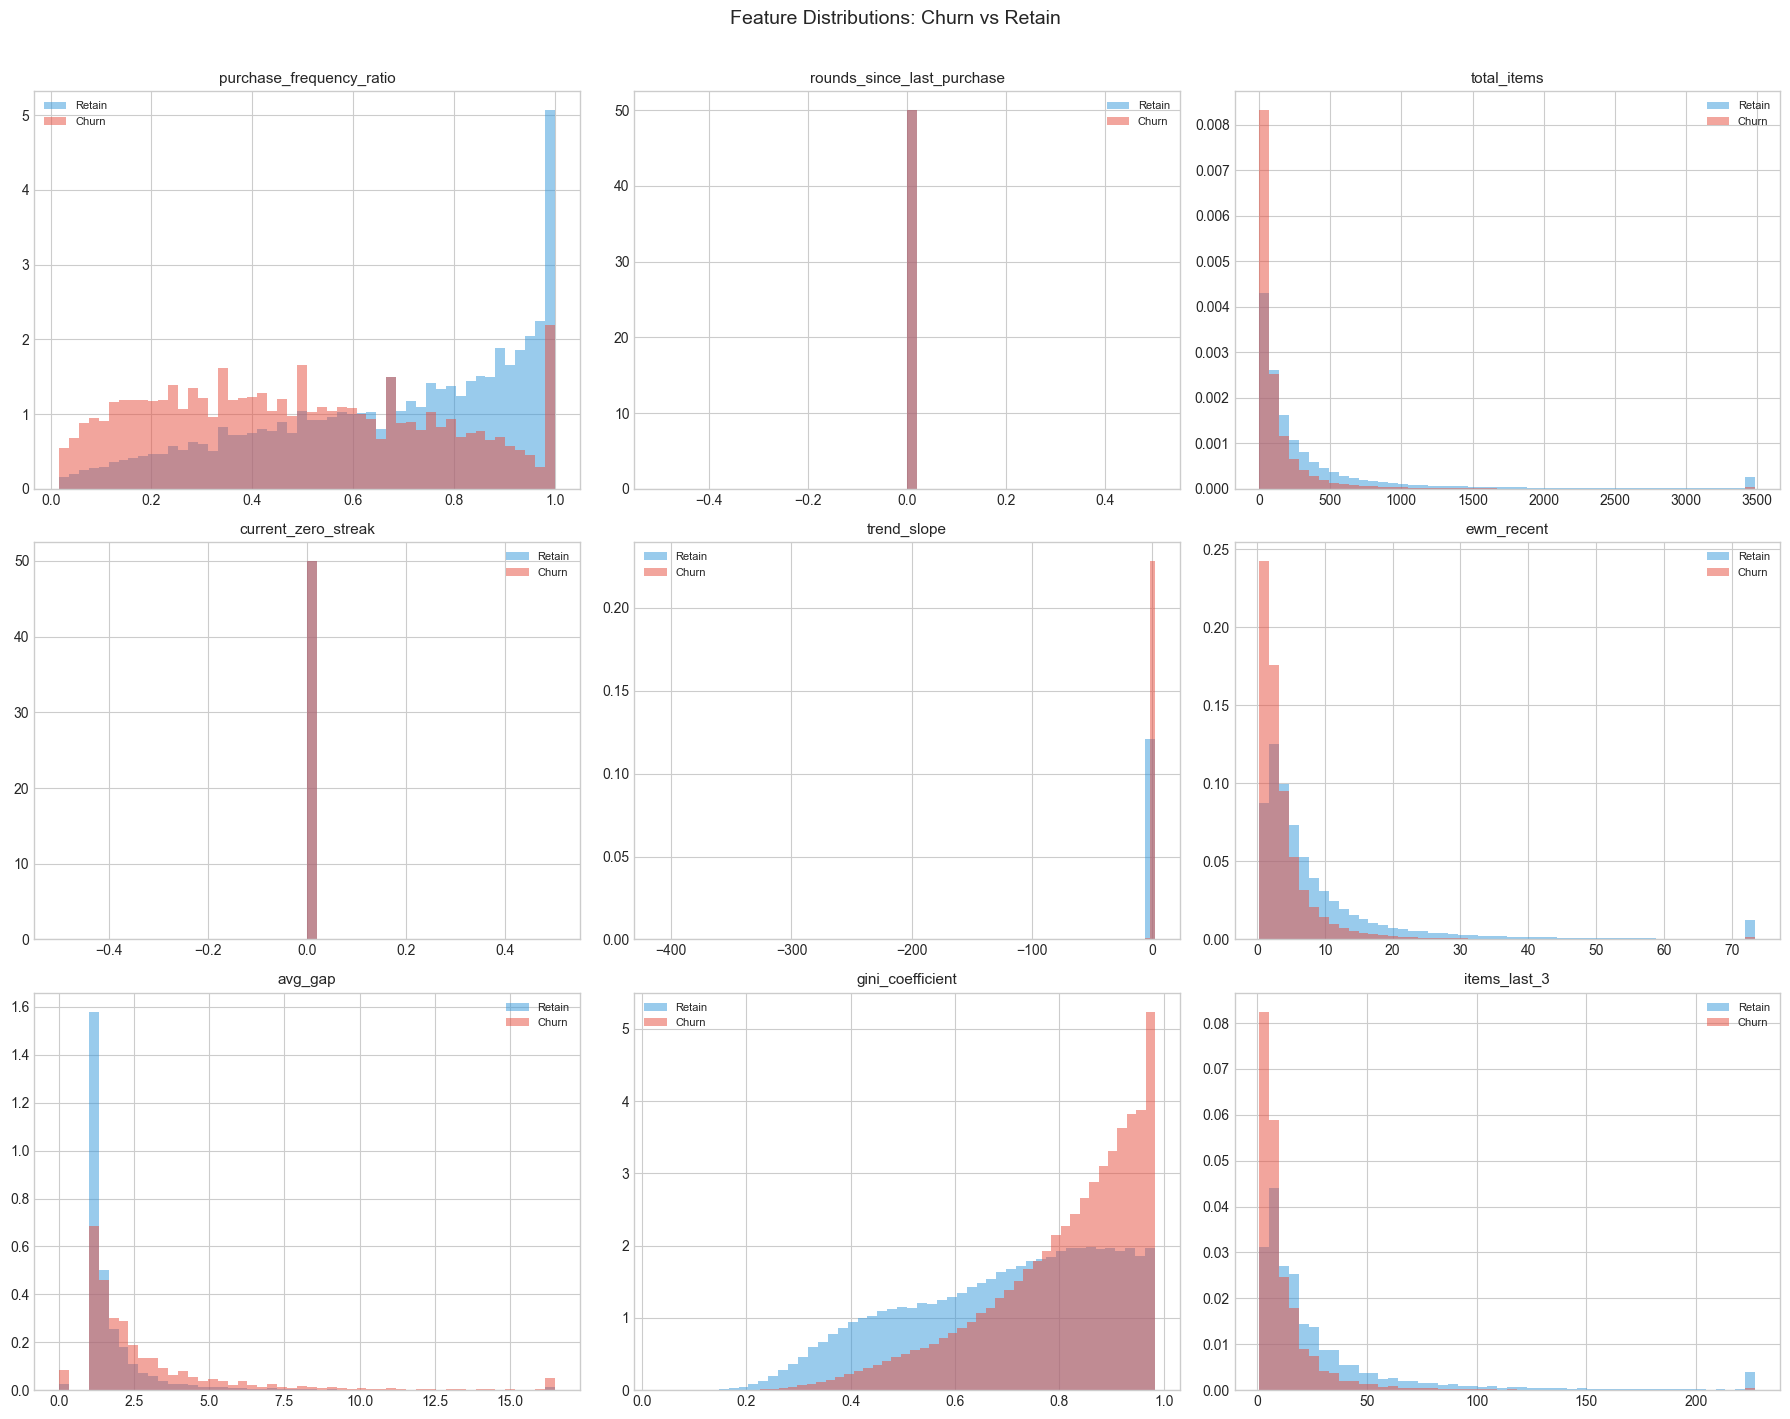

In [4]:
# --- Feature Distributions: Churn vs Retain ---
plot_feats = ['purchase_frequency_ratio', 'rounds_since_last_purchase', 'total_items',
              'current_zero_streak', 'trend_slope', 'ewm_recent',
              'avg_gap', 'gini_coefficient', 'items_last_3']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
churn_mask = df_eligible['churn'] == 1
retain_mask = df_eligible['churn'] == 0

for ax, feat in zip(axes.ravel(), plot_feats):
    data_r = features.loc[retain_mask, feat].clip(upper=features[feat].quantile(0.99))
    data_c = features.loc[churn_mask, feat].clip(upper=features[feat].quantile(0.99))
    ax.hist(data_r, bins=50, alpha=0.5, label='Retain', color='#3498db', density=True)
    ax.hist(data_c, bins=50, alpha=0.5, label='Churn', color='#e74c3c', density=True)
    ax.set_title(feat, fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions: Churn vs Retain', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

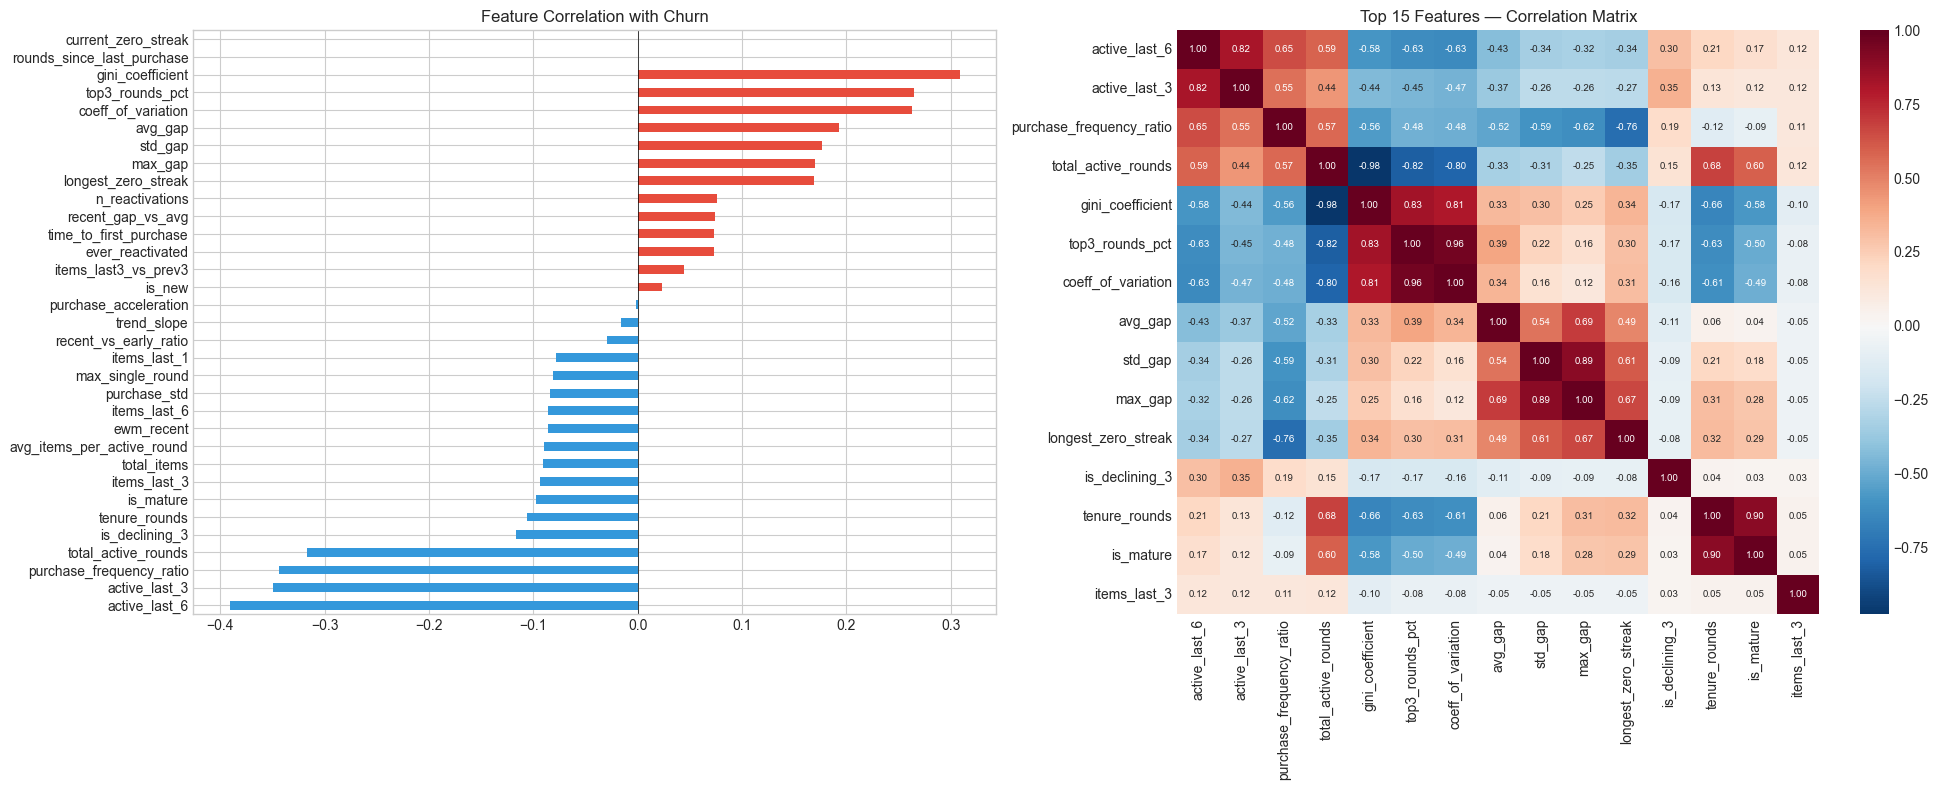

In [5]:
# --- Correlation Heatmap ---
corr = features.corrwith(df_eligible['churn']).sort_values()
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Correlation with target
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr.values]
corr.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Feature Correlation with Churn')
axes[0].axvline(0, color='black', linewidth=0.5)

# Feature-Feature correlation matrix (top features)
top_feats = corr.abs().nlargest(15).index.tolist()
corr_matrix = features[top_feats].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[1], annot_kws={'size': 7})
axes[1].set_title('Top 15 Features — Correlation Matrix')

plt.tight_layout()
plt.show()

In [6]:
# --- Statistical Tests: Mann-Whitney U + Cohen's d ---
from scipy.stats import mannwhitneyu

stat_results = []
for col in features.columns:
    churn_vals = features.loc[churn_mask, col].dropna()
    retain_vals = features.loc[retain_mask, col].dropna()
    
    # Mann-Whitney U test
    stat, p = mannwhitneyu(churn_vals, retain_vals, alternative='two-sided')
    
    # Cohen's d
    pooled_std = np.sqrt(((churn_vals.std()**2 + retain_vals.std()**2)) / 2)
    d = (churn_vals.mean() - retain_vals.mean()) / pooled_std if pooled_std > 0 else 0
    
    stat_results.append({
        'Feature': col,
        'Churn_mean': churn_vals.mean(),
        'Retain_mean': retain_vals.mean(),
        'Cohens_d': d,
        'p_value': p,
        'Significant': '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    })

stat_df = pd.DataFrame(stat_results).sort_values('Cohens_d', key=abs, ascending=False)
print("Statistical Tests — Mann-Whitney U + Cohen's d")
print("(Sorted by |Cohen's d|, higher = stronger difference)\n")
print(stat_df[['Feature', 'Cohens_d', 'p_value', 'Significant']].to_string(index=False, float_format='{:.4f}'.format))

Statistical Tests — Mann-Whitney U + Cohen's d
(Sorted by |Cohen's d|, higher = stronger difference)

                   Feature  Cohens_d  p_value Significant
             active_last_6   -0.8473   0.0000         ***
             active_last_3   -0.7445   0.0000         ***
  purchase_frequency_ratio   -0.7317   0.0000         ***
       total_active_rounds   -0.6703   0.0000         ***
          gini_coefficient    0.6522   0.0000         ***
           top3_rounds_pct    0.5481   0.0000         ***
        coeff_of_variation    0.5434   0.0000         ***
                   avg_gap    0.3904   0.0000         ***
                   std_gap    0.3580   0.0000         ***
                   max_gap    0.3445   0.0000         ***
       longest_zero_streak    0.3431   0.0000         ***
            is_declining_3   -0.2356   0.0000         ***
             tenure_rounds   -0.2125   0.0000         ***
                 is_mature   -0.1953   0.0000         ***
              items_last_3  

## Phase 3: Train/Test Split & Model Training

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             classification_report, confusion_matrix,
                             roc_curve, precision_recall_curve)
import xgboost as xgb
import lightgbm as lgb

# Prepare X, y
feature_cols = features.columns.tolist()
X = features[feature_cols].fillna(0)
y = df_eligible['churn'].values

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Churn rate: {y_train.mean():.2%}")
print(f"Test:  {X_test.shape} | Churn rate: {y_test.mean():.2%}")
print(f"Features: {len(feature_cols)}")

Train: (456864, 33) | Churn rate: 48.33%
Test:  (114216, 33) | Churn rate: 48.33%
Features: 33


In [8]:
%%time
models = {}

# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced', C=0.1, random_state=42)
lr.fit(X_train_scaled, y_train)
models['Logistic Regression'] = ('scaled', lr)
print("1/4 Logistic Regression done")

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=15, min_samples_leaf=50,
                            class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
models['Random Forest'] = ('raw', rf)
print("2/4 Random Forest done")

# 3. XGBoost
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    scale_pos_weight=scale_pos, subsample=0.8, colsample_bytree=0.8,
    eval_metric='auc', random_state=42, n_jobs=-1,
    early_stopping_rounds=30)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
models['XGBoost'] = ('raw', xgb_model)
print(f"3/4 XGBoost done (best iter: {xgb_model.best_iteration})")

# 4. LightGBM
lgb_model = lgb.LGBMClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    scale_pos_weight=scale_pos, subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbose=-1)
lgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)],
              callbacks=[lgb.early_stopping(30, verbose=False)])
models['LightGBM'] = ('raw', lgb_model)
print(f"4/4 LightGBM done (best iter: {lgb_model.best_iteration_})")
print("\nAll models trained!")

1/4 Logistic Regression done


2/4 Random Forest done


3/4 XGBoost done (best iter: 253)


4/4 LightGBM done (best iter: 372)

All models trained!
CPU times: user 10min 21s, sys: 20.9 s, total: 10min 42s
Wall time: 3min 45s


In [9]:
# --- Evaluate all models ---
results = []
for name, (dtype, model) in models.items():
    Xt = X_test_scaled if dtype == 'scaled' else X_test
    probs = model.predict_proba(Xt)[:, 1]
    preds = (probs >= 0.5).astype(int)
    results.append({
        'Model': name,
        'AUC-ROC': roc_auc_score(y_test, probs),
        'AUC-PR': average_precision_score(y_test, probs),
        'F1': f1_score(y_test, preds),
        'Accuracy': (preds == y_test).mean()
    })

eval_df = pd.DataFrame(results).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
print("Model Performance Comparison:")
print(eval_df.to_string(index=False, float_format='{:.4f}'.format))

best_name = eval_df.iloc[0]['Model']
print(f"\nBest model: {best_name} (AUC-ROC: {eval_df.iloc[0]['AUC-ROC']:.4f})")

Model Performance Comparison:
              Model  AUC-ROC  AUC-PR     F1  Accuracy
           LightGBM   0.7627  0.7298 0.6935    0.6931
            XGBoost   0.7626  0.7298 0.6938    0.6934
      Random Forest   0.7614  0.7285 0.6919    0.6921
Logistic Regression   0.7555  0.7203 0.6867    0.6891

Best model: LightGBM (AUC-ROC: 0.7627)


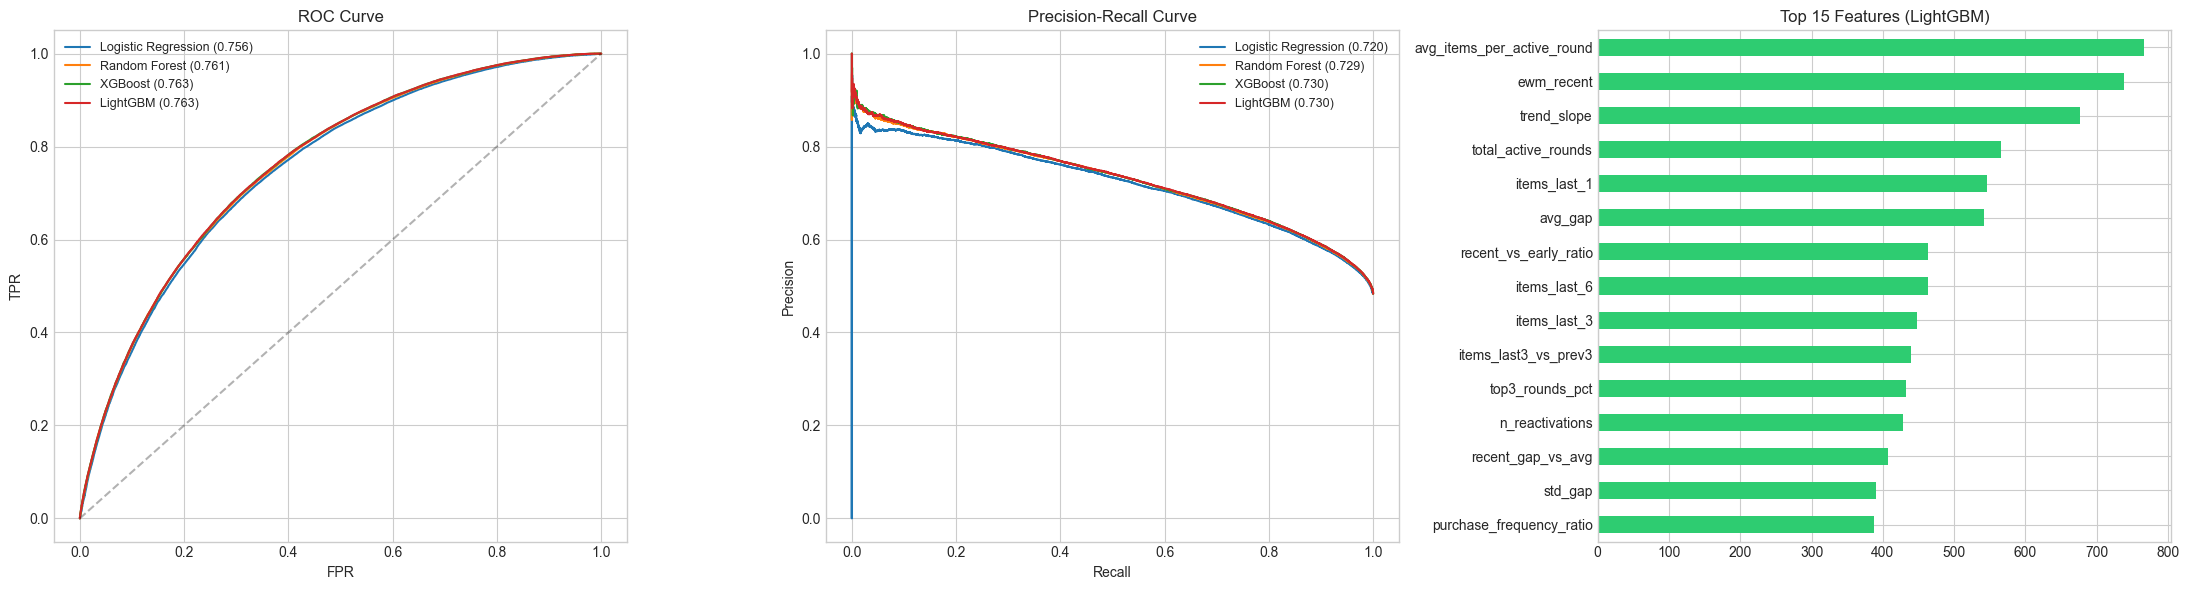

In [10]:
# --- ROC Curve, PR Curve, Feature Importance ---
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# ROC Curves
for name, (dtype, model) in models.items():
    Xt = X_test_scaled if dtype == 'scaled' else X_test
    probs = model.predict_proba(Xt)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, label=f'{name} ({auc:.3f})')
axes[0].plot([0,1], [0,1], 'k--', alpha=0.3)
axes[0].set_title('ROC Curve'); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].legend(fontsize=9)

# PR Curves
for name, (dtype, model) in models.items():
    Xt = X_test_scaled if dtype == 'scaled' else X_test
    probs = model.predict_proba(Xt)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    axes[1].plot(rec, prec, label=f'{name} ({ap:.3f})')
axes[1].set_title('Precision-Recall Curve'); axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9)

# Feature Importance (best model)
_, best_model = models[best_name]
if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
else:
    imp = pd.Series(np.abs(best_model.coef_[0]), index=feature_cols).sort_values(ascending=True)
imp.tail(15).plot(kind='barh', ax=axes[2], color='#2ecc71')
axes[2].set_title(f'Top 15 Features ({best_name})')

plt.tight_layout()
plt.show()

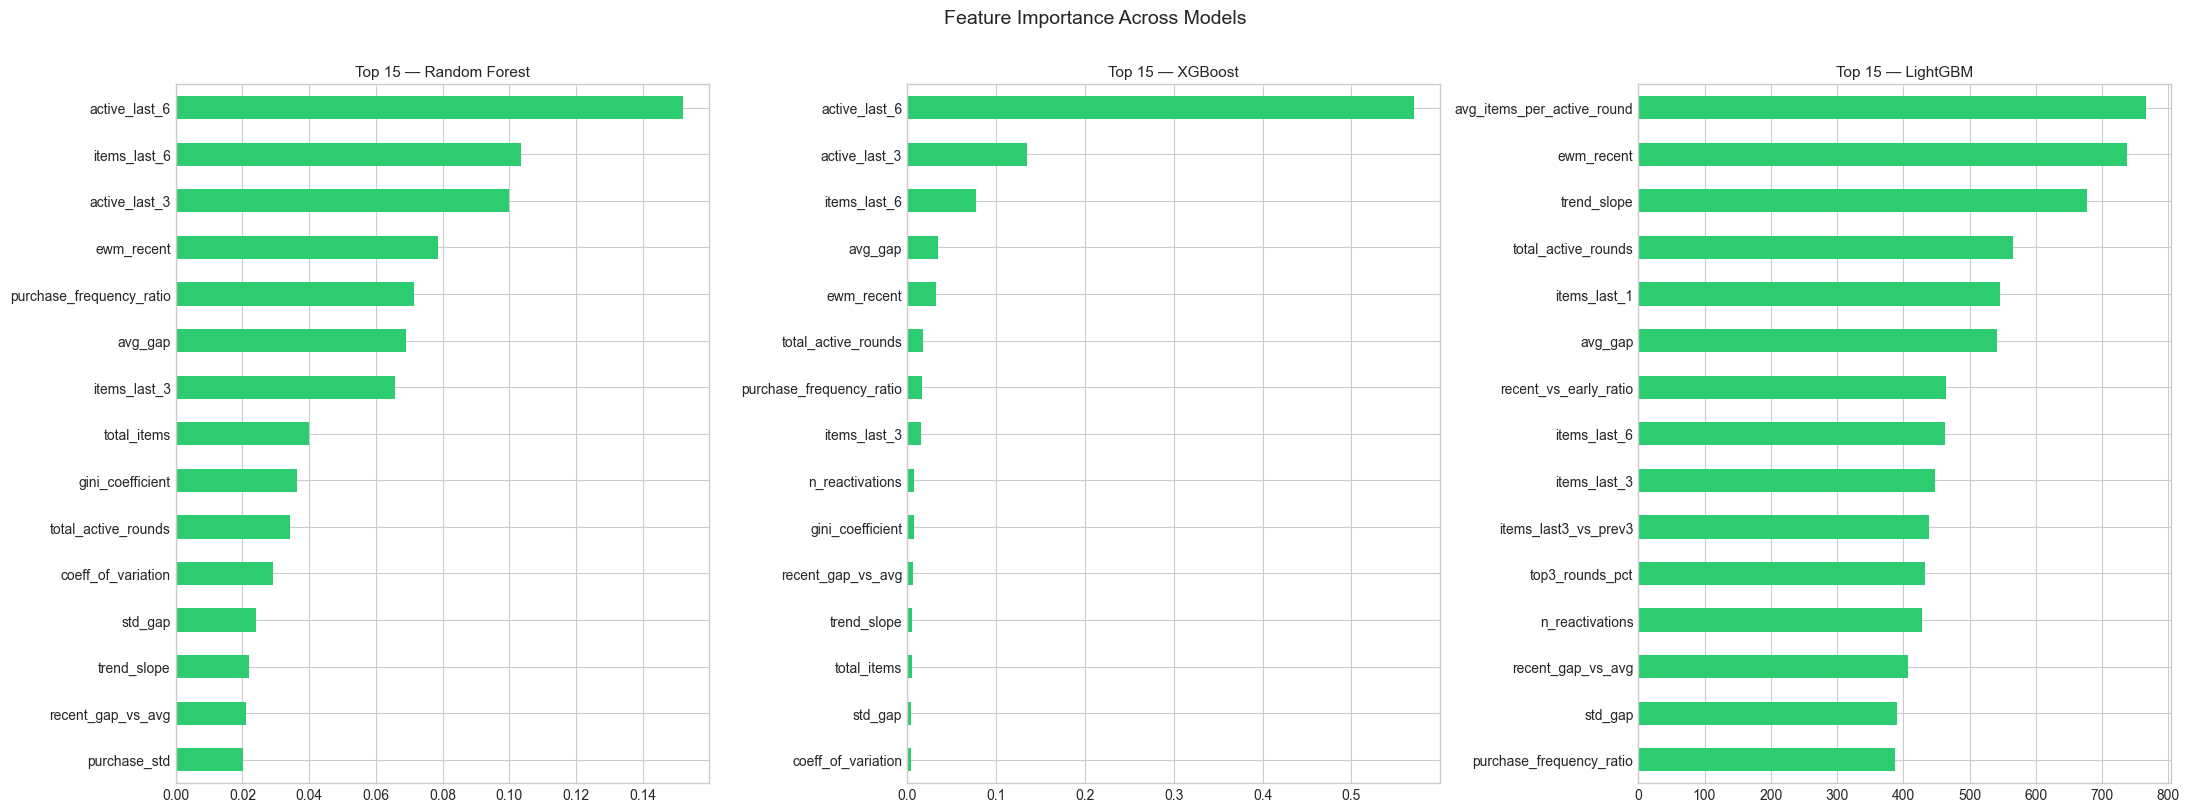

In [11]:
# --- Cross-model Feature Importance Comparison ---
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

for ax, (name, (dtype, model)) in zip(axes, 
    [(n, models[n]) for n in ['Random Forest', 'XGBoost', 'LightGBM']]):
    imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True)
    imp.tail(15).plot(kind='barh', ax=ax, color='#2ecc71')
    ax.set_title(f'Top 15 — {name}', fontsize=11)

plt.suptitle('Feature Importance Across Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Phase 4: Churn Risk Score — Marketing Radar
แปลง probability เป็น Risk Score 0-100 พร้อมจัดกลุ่มความเสี่ยง

Risk Score Distribution (LightGBM):

          1-Low (0-25):  20,752 customers ( 18.2%) | Actual churn: 14.2%
      2-Medium (26-50):  34,388 customers ( 30.1%) | Actual churn: 36.7%
        3-High (51-75):  40,180 customers ( 35.2%) | Actual churn: 60.9%
   4-Critical (76-100):  18,896 customers ( 16.5%) | Actual churn: 80.2%


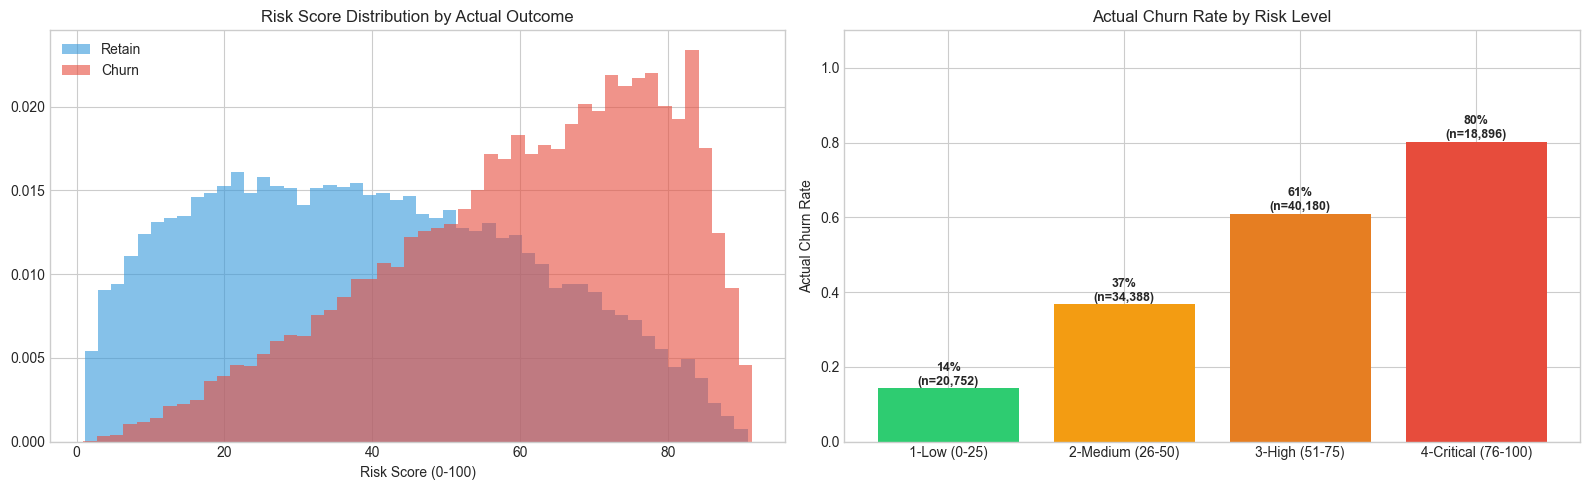

In [12]:
# --- Churn Risk Score on test set ---
_, best_model = models[best_name]
Xt_best = X_test_scaled if models[best_name][0] == 'scaled' else X_test
risk_probs = best_model.predict_proba(Xt_best)[:, 1]
risk_scores = (risk_probs * 100).round(1)

# Risk Level buckets
def risk_level(score):
    if score <= 25: return '1-Low (0-25)'
    elif score <= 50: return '2-Medium (26-50)'
    elif score <= 75: return '3-High (51-75)'
    else: return '4-Critical (76-100)'

risk_df = pd.DataFrame({
    'risk_score': risk_scores,
    'actual_churn': y_test
})
risk_df['risk_level'] = risk_df['risk_score'].apply(risk_level)

# Stats per risk level
level_stats = risk_df.groupby('risk_level').agg(
    count=('actual_churn', 'size'),
    actual_churn_rate=('actual_churn', 'mean'),
    avg_score=('risk_score', 'mean')
).reset_index()

print(f"Risk Score Distribution ({best_name}):\n")
for _, row in level_stats.iterrows():
    pct = row['count'] / len(risk_df) * 100
    print(f"  {row['risk_level']:>20s}: {row['count']:>7,} customers ({pct:5.1f}%) | Actual churn: {row['actual_churn_rate']:.1%}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Score distribution
axes[0].hist(risk_scores[y_test==0], bins=50, alpha=0.6, label='Retain', color='#3498db', density=True)
axes[0].hist(risk_scores[y_test==1], bins=50, alpha=0.6, label='Churn', color='#e74c3c', density=True)
axes[0].set_title('Risk Score Distribution by Actual Outcome')
axes[0].set_xlabel('Risk Score (0-100)'); axes[0].legend()

# Actual churn rate per bucket
colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
bars = axes[1].bar(level_stats['risk_level'], level_stats['actual_churn_rate'], color=colors)
for bar, rate, cnt in zip(bars, level_stats['actual_churn_rate'], level_stats['count']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{rate:.0%}\n(n={cnt:,})', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Actual Churn Rate by Risk Level')
axes[1].set_ylabel('Actual Churn Rate'); axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

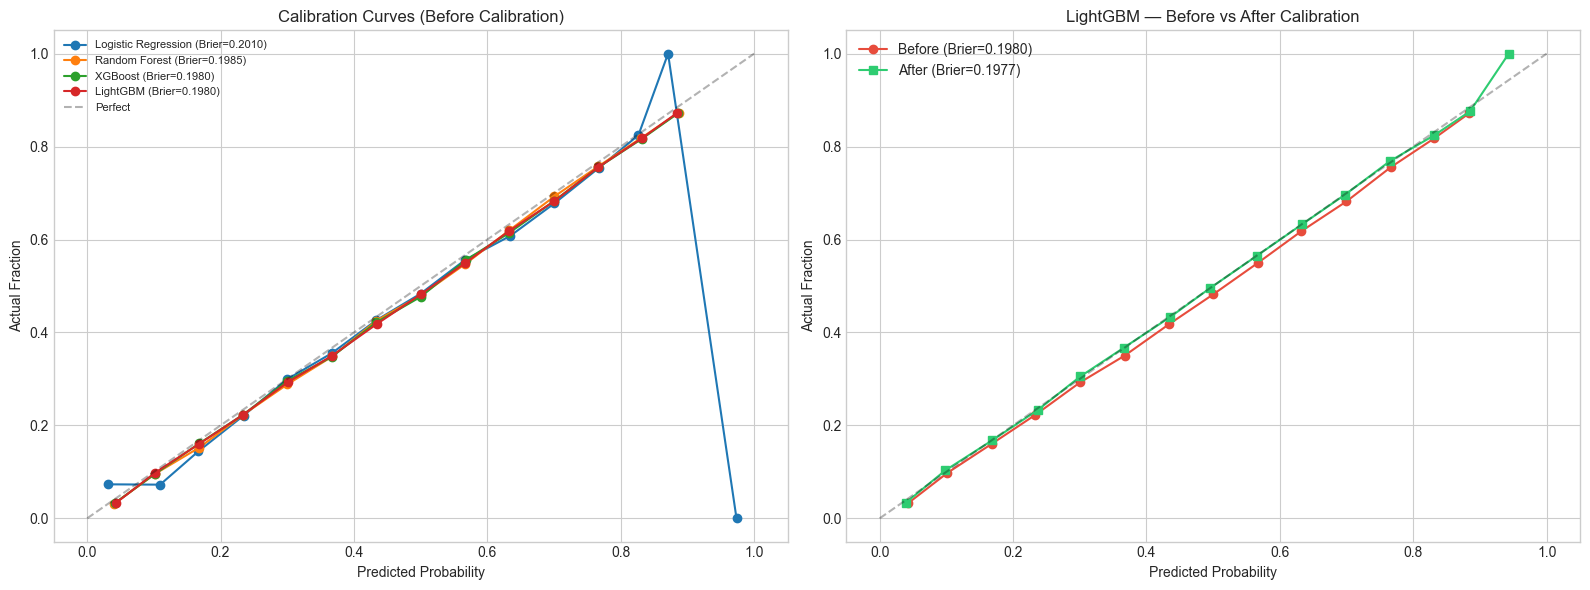

Calibrated LightGBM saved as 'cal_model'


In [13]:
# --- Calibration Curve ---
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, (dtype, model) in models.items():
    Xt = X_test_scaled if dtype == 'scaled' else X_test
    probs = model.predict_proba(Xt)[:, 1]
    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=15)
    brier = brier_score_loss(y_test, probs)
    axes[0].plot(prob_pred, prob_true, 'o-', label=f'{name} (Brier={brier:.4f})')

axes[0].plot([0,1], [0,1], 'k--', alpha=0.3, label='Perfect')
axes[0].set_title('Calibration Curves (Before Calibration)')
axes[0].set_xlabel('Predicted Probability'); axes[0].set_ylabel('Actual Fraction')
axes[0].legend(fontsize=8)

# Calibrate best model with isotonic regression
_, bm = models[best_name]
if best_name in ('XGBoost', 'LightGBM'):
    n_est = bm.best_iteration if hasattr(bm, 'best_iteration') else bm.best_iteration_
    if best_name == 'XGBoost':
        base_cal = xgb.XGBClassifier(n_estimators=max(n_est, 50), max_depth=6, learning_rate=0.05,
            scale_pos_weight=scale_pos, subsample=0.8, colsample_bytree=0.8,
            eval_metric='auc', random_state=42, n_jobs=-1)
    else:
        base_cal = lgb.LGBMClassifier(n_estimators=max(n_est, 50), max_depth=6, learning_rate=0.05,
            scale_pos_weight=scale_pos, subsample=0.8, colsample_bytree=0.8,
            random_state=42, n_jobs=-1, verbose=-1)
else:
    base_cal = LogisticRegression(max_iter=1000, class_weight='balanced', C=0.1, random_state=42)

cal_model = CalibratedClassifierCV(base_cal, method='isotonic', cv=5)
X_cal = X_train_scaled if models[best_name][0] == 'scaled' else X_train
cal_model.fit(X_cal, y_train)

cal_probs = cal_model.predict_proba(Xt_best)[:, 1]
pt_before, pp_before = calibration_curve(y_test, risk_probs, n_bins=15)
pt_after, pp_after = calibration_curve(y_test, cal_probs, n_bins=15)

axes[1].plot(pp_before, pt_before, 'o-', color='#e74c3c', label=f'Before (Brier={brier_score_loss(y_test, risk_probs):.4f})')
axes[1].plot(pp_after, pt_after, 's-', color='#2ecc71', label=f'After (Brier={brier_score_loss(y_test, cal_probs):.4f})')
axes[1].plot([0,1], [0,1], 'k--', alpha=0.3)
axes[1].set_title(f'{best_name} — Before vs After Calibration')
axes[1].set_xlabel('Predicted Probability'); axes[1].set_ylabel('Actual Fraction')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Calibrated {best_name} saved as 'cal_model'")

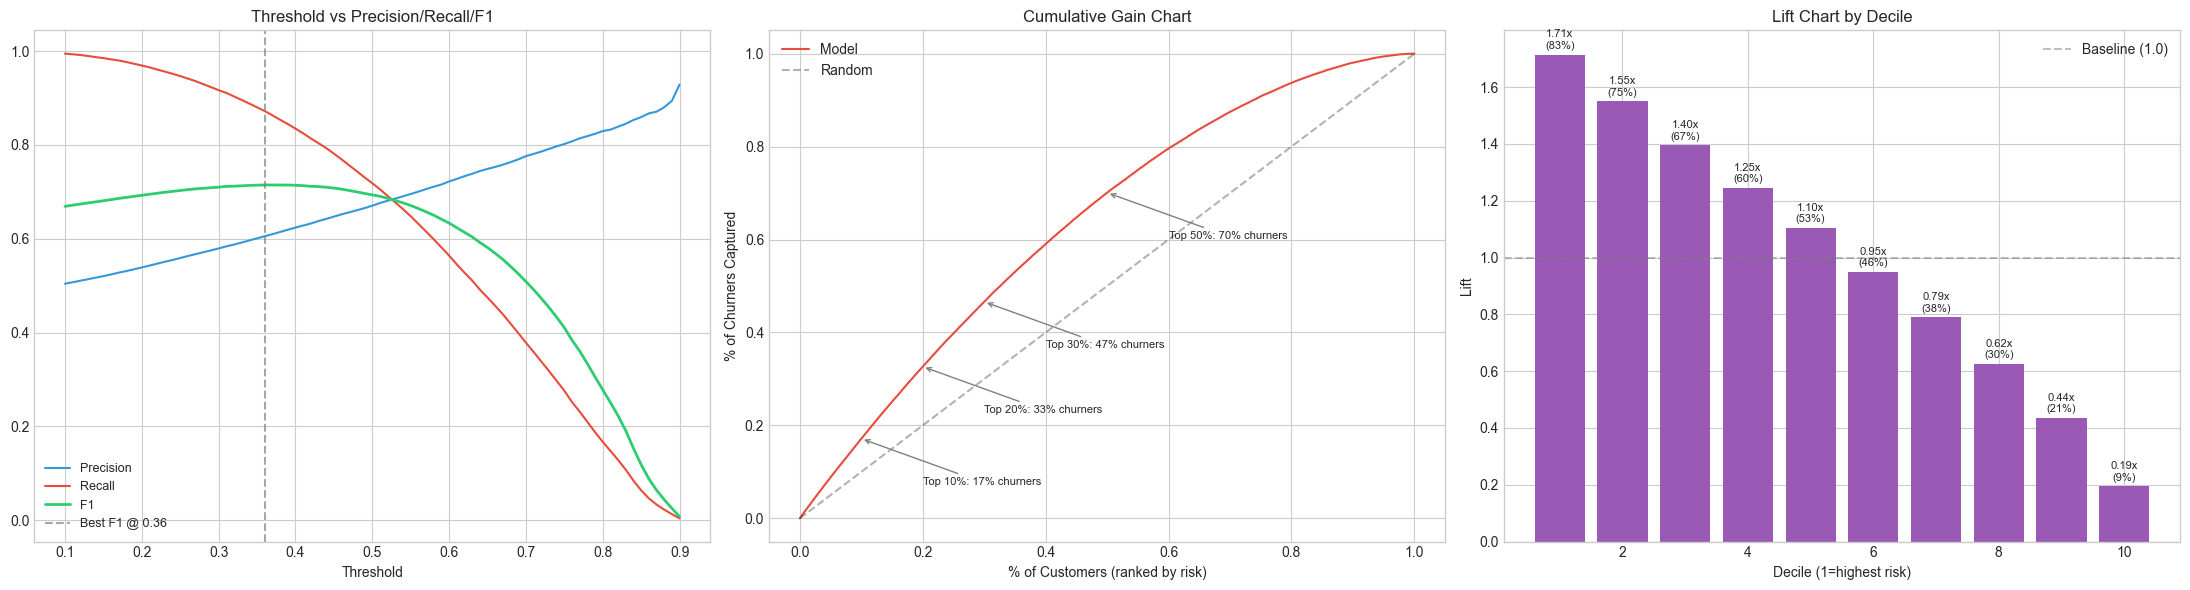

Best F1 threshold: 0.36


In [14]:
# --- Threshold Analysis + Gain/Lift Chart ---
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 1. Threshold vs Precision/Recall/F1
thresholds = np.arange(0.1, 0.91, 0.01)
metrics_by_thresh = []
for t in thresholds:
    preds_t = (risk_probs >= t).astype(int)
    tp = ((preds_t == 1) & (y_test == 1)).sum()
    fp = ((preds_t == 1) & (y_test == 0)).sum()
    fn = ((preds_t == 0) & (y_test == 1)).sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    metrics_by_thresh.append({'threshold': t, 'precision': prec, 'recall': rec, 'f1': f1})
mt_df = pd.DataFrame(metrics_by_thresh)

axes[0].plot(mt_df['threshold'], mt_df['precision'], label='Precision', color='#3498db')
axes[0].plot(mt_df['threshold'], mt_df['recall'], label='Recall', color='#e74c3c')
axes[0].plot(mt_df['threshold'], mt_df['f1'], label='F1', color='#2ecc71', linewidth=2)
best_thresh = mt_df.loc[mt_df['f1'].idxmax(), 'threshold']
axes[0].axvline(best_thresh, color='gray', linestyle='--', alpha=0.7, label=f'Best F1 @ {best_thresh:.2f}')
axes[0].set_title('Threshold vs Precision/Recall/F1')
axes[0].set_xlabel('Threshold'); axes[0].legend(fontsize=9)

# 2. Cumulative Gain Chart
sorted_idx = np.argsort(-risk_probs)
y_sorted = y_test[sorted_idx]
cum_churn = np.cumsum(y_sorted) / y_sorted.sum()
pct_population = np.arange(1, len(y_sorted)+1) / len(y_sorted)

axes[1].plot(pct_population, cum_churn, color='#e74c3c', label='Model')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
axes[1].set_title('Cumulative Gain Chart')
axes[1].set_xlabel('% of Customers (ranked by risk)')
axes[1].set_ylabel('% of Churners Captured')
axes[1].legend()
# Annotate key points
for pct in [0.1, 0.2, 0.3, 0.5]:
    idx = int(pct * len(cum_churn)) - 1
    axes[1].annotate(f'Top {pct:.0%}: {cum_churn[idx]:.0%} churners',
                     xy=(pct, cum_churn[idx]), fontsize=8,
                     arrowprops=dict(arrowstyle='->', color='gray'),
                     xytext=(pct+0.1, cum_churn[idx]-0.1))

# 3. Lift Chart
n_bins_lift = 10
bin_size = len(y_sorted) // n_bins_lift
lift_data = []
base_rate = y_test.mean()
for i in range(n_bins_lift):
    start = i * bin_size
    end = start + bin_size if i < n_bins_lift - 1 else len(y_sorted)
    bin_rate = y_sorted[start:end].mean()
    lift_data.append({'Decile': i+1, 'Churn_rate': bin_rate, 'Lift': bin_rate / base_rate})

lift_df = pd.DataFrame(lift_data)
bars = axes[2].bar(lift_df['Decile'], lift_df['Lift'], color='#9b59b6')
axes[2].axhline(1.0, color='gray', linestyle='--', alpha=0.5, label='Baseline (1.0)')
for bar, lift, rate in zip(bars, lift_df['Lift'], lift_df['Churn_rate']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{lift:.2f}x\n({rate:.0%})', ha='center', fontsize=8)
axes[2].set_title('Lift Chart by Decile')
axes[2].set_xlabel('Decile (1=highest risk)'); axes[2].set_ylabel('Lift')
axes[2].legend()

plt.tight_layout()
plt.show()
print(f"Best F1 threshold: {best_thresh:.2f}")

Classification Report (LightGBM):

              precision    recall  f1-score   support

      Retain       0.72      0.67      0.69     59010
       Churn       0.67      0.72      0.69     55206

    accuracy                           0.69    114216
   macro avg       0.69      0.69      0.69    114216
weighted avg       0.69      0.69      0.69    114216



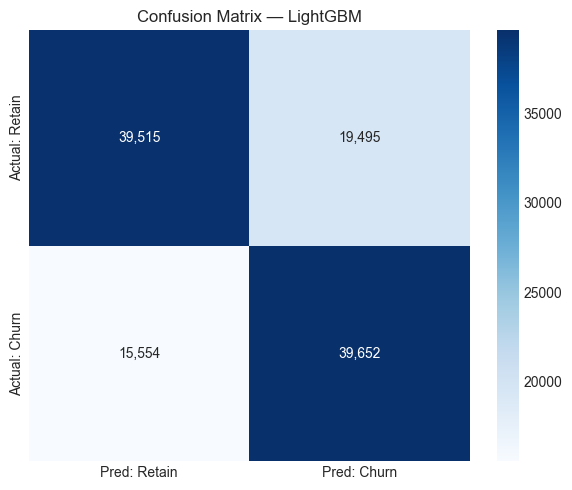


True Negatives (correct retain):  39,515
False Positives (false alarm):    19,495
False Negatives (missed churn):   15,554
True Positives (caught churn):    39,652


In [15]:
# --- Detailed Classification Report & Confusion Matrix ---
preds_best = (risk_probs >= 0.5).astype(int)

print(f"Classification Report ({best_name}):\n")
print(classification_report(y_test, preds_best, target_names=['Retain', 'Churn']))

# Confusion Matrix
cm = confusion_matrix(y_test, preds_best)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax,
            xticklabels=['Pred: Retain', 'Pred: Churn'],
            yticklabels=['Actual: Retain', 'Actual: Churn'])
ax.set_title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives (correct retain):  {tn:,}")
print(f"False Positives (false alarm):    {fp:,}")
print(f"False Negatives (missed churn):   {fn:,}")
print(f"True Positives (caught churn):    {tp:,}")

In [16]:
# --- Sample Output for Marketing Team ---
# Score ALL eligible customers (not just test set)
X_all = features[feature_cols].fillna(0)
_, bm_final = models[best_name]
if models[best_name][0] == 'scaled':
    all_probs = bm_final.predict_proba(scaler.transform(X_all))[:, 1]
else:
    all_probs = bm_final.predict_proba(X_all)[:, 1]

output_df = pd.DataFrame({
    'userNo': df_eligible['userNo'].values,
    'churn_probability': (all_probs * 100).round(1),
    'risk_level': pd.cut(all_probs * 100, bins=[-1, 25, 50, 75, 100],
                         labels=['Low', 'Medium', 'High', 'Critical']),
    'actual_churn': df_eligible['churn'].values,
    'tenure_rounds': features['tenure_rounds'].values,
    'purchase_freq': features['purchase_frequency_ratio'].values.round(3),
    'items_last_3': features['items_last_3'].values
})

print(f"Output for Marketing: {len(output_df):,} customers scored\n")
print("Top 20 highest risk customers:")
print(output_df.nlargest(20, 'churn_probability')[
    ['userNo', 'churn_probability', 'risk_level', 'tenure_rounds', 'purchase_freq', 'items_last_3']
].to_string(index=False))

print(f"\n\nRisk Level Summary:")
summary = output_df.groupby('risk_level', observed=True).agg(
    count=('userNo', 'size'),
    avg_prob=('churn_probability', 'mean'),
    actual_churn_rate=('actual_churn', 'mean')
)
print(summary.to_string(float_format='{:.1f}'.format))

Output for Marketing: 571,080 customers scored

Top 20 highest risk customers:


   userNo  churn_probability risk_level  tenure_rounds  purchase_freq  items_last_3
 P6294630               91.7   Critical             59          0.068           1.0
 P6360662               91.5   Critical             59          0.068           1.0
 P6959449               91.5   Critical             56          0.107           1.0
 P6968231               91.5   Critical             56          0.071           1.0
 P7243858               91.4   Critical             54          0.148           1.0
 P7109419               91.4   Critical             55          0.109           1.0
 P8448290               91.4   Critical             42          0.143           1.0
P11159276               91.4   Critical             20          0.150           1.0
 P6943223               91.4   Critical             56          0.071           1.0
 P6990509               91.4   Critical             56          0.143           1.0
P10716111               91.4   Critical             23          0.174       

## Summary & Key Findings

### Data
- **571,080** eligible customers (excluded 19,564 new customers with < 3 rounds)
- **Churn rate: 48.33%** — balanced dataset, no resampling needed
- Features built from **purchase behavior only** (no demographics)

### Models
- 4 models trained: Logistic Regression, Random Forest, XGBoost, LightGBM
- Features validated through Mann-Whitney U tests and correlation analysis
- Calibration applied via isotonic regression for better probability estimates

### Output for Marketing
- **Risk Score 0-100** per customer
- **4 risk levels:** Low / Medium / High / Critical
- Gain chart shows model captures majority of churners in top deciles
- Threshold can be tuned based on business needs (precision vs recall tradeoff)

### Next Steps
1. Test on remaining 4 files to validate model generalization
2. Iterative learning — retrain with more data for higher accuracy
3. Deploy as pipeline for real-time scoring

## Phase 5: Cross-Period Validation
ทดสอบโมเดลที่ train จากงวด 1216→0102 กับข้อมูลงวดใหม่ 0102→0117  
เพื่อดูว่าโมเดล **generalize** ได้จริงหรือไม่ (ไม่ได้ train ใหม่)

In [17]:
%%time
# === Load new period data ===
df2 = pd.read_csv('Churn_2026_0102_0117.csv', low_memory=False)
item_cols2 = [c for c in df2.columns if c.startswith('item')]

print(f"File: Churn_2026_0102_0117.csv")
print(f"Shape: {df2.shape[0]:,} rows x {df2.shape[1]} cols")
print(f"Purchase rounds: {len(item_cols2)} ({item_cols2[0]} → {item_cols2[-1]})")

# Target round = last item column (item2026_01_17)
# Feature rounds = all except last (same logic as training)
target_col2 = item_cols2[-1]
feature_item_cols2 = item_cols2[:-1]
print(f"\nTarget round: {target_col2}")
print(f"Feature rounds: {len(feature_item_cols2)} ({feature_item_cols2[0]} → {feature_item_cols2[-1]})")

# Convert to numeric matrix
mat2 = df2[item_cols2].apply(pd.to_numeric, errors='coerce')

# Exclude new customers (tenure < 3)
first_reg_idx2 = mat2.notna().values.argmax(axis=1)
tenure2 = len(item_cols2) - first_reg_idx2
exclude_mask2 = tenure2 < MIN_TENURE
df2_eligible = df2[~exclude_mask2].copy()
mat2_eligible = mat2[~exclude_mask2].copy()

# Define target
df2_eligible['churn'] = (df2_eligible[target_col2] == 0).astype(int)

print(f"\nTotal customers:          {len(df2):,}")
print(f"Excluded (tenure < {MIN_TENURE}):    {exclude_mask2.sum():,}")
print(f"Eligible:                 {len(df2_eligible):,}")
print(f"\nTarget distribution (Period 2):")
print(f"  Buy (churn=0):   {(df2_eligible['churn']==0).sum():,} ({(df2_eligible['churn']==0).mean():.1%})")
print(f"  Churn (churn=1): {(df2_eligible['churn']==1).sum():,} ({(df2_eligible['churn']==1).mean():.1%})")

# === Feature Engineering (same function, same logic) ===
print("\n--- Engineering features for Period 2 ---")
features2 = engineer_features(df2_eligible, mat2_eligible, feature_item_cols2)
print(f"Features shape: {features2.shape}")

# === Align features: use only the 33 features from training ===
# The new file has 1 extra round, so feature_item_cols2 has 61 rounds vs 60
# But engineer_features outputs the same 33 feature names regardless
missing_cols = set(feature_cols) - set(features2.columns)
extra_cols = set(features2.columns) - set(feature_cols)
if missing_cols:
    print(f"WARNING: Missing features in new data: {missing_cols}")
    for col in missing_cols:
        features2[col] = 0
if extra_cols:
    print(f"Extra features in new data (will be ignored): {extra_cols}")

X2 = features2[feature_cols].fillna(0)
y2 = df2_eligible['churn'].values
print(f"\nReady to predict: {X2.shape[0]:,} customers, {X2.shape[1]} features")

File: Churn_2026_0102_0117.csv
Shape: 557,461 rows x 70 cols
Purchase rounds: 62 (item2023_07_01 → item2026_01_17)

Target round: item2026_01_17
Feature rounds: 61 (item2023_07_01 → item2026_01_02)



Total customers:          557,461
Excluded (tenure < 3):    17,302
Eligible:                 540,159

Target distribution (Period 2):
  Buy (churn=0):   309,219 (57.2%)
  Churn (churn=1): 230,940 (42.8%)

--- Engineering features for Period 2 ---


  Computing row-wise features...


Features shape: (540159, 33)



Ready to predict: 540,159 customers, 33 features
CPU times: user 1min 11s, sys: 8.85 s, total: 1min 20s
Wall time: 2min 14s


In [18]:
# === Predict on Period 2 using ALL models trained on Period 1 ===
print("=" * 70)
print("CROSS-PERIOD VALIDATION: Model trained on Period 1 → Predict Period 2")
print("=" * 70)

results_p2 = []
for name, (dtype, model) in models.items():
    if dtype == 'scaled':
        X2_input = scaler.transform(X2)
    else:
        X2_input = X2
    
    probs2 = model.predict_proba(X2_input)[:, 1]
    preds2 = (probs2 >= 0.5).astype(int)
    
    results_p2.append({
        'Model': name,
        'AUC-ROC': roc_auc_score(y2, probs2),
        'AUC-PR': average_precision_score(y2, probs2),
        'F1': f1_score(y2, preds2),
        'Accuracy': (preds2 == y2).mean()
    })

eval_p2 = pd.DataFrame(results_p2).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)

# Compare with Period 1 results
print("\n📊 Period 1 (Train/Test — same period):")
print(eval_df.to_string(index=False, float_format='{:.4f}'.format))

print(f"\n📊 Period 2 (Cross-period validation — unseen period):")
print(eval_p2.to_string(index=False, float_format='{:.4f}'.format))

# Delta comparison
print("\n📊 Delta (Period 2 - Period 1):")
for _, r1 in eval_df.iterrows():
    r2 = eval_p2[eval_p2['Model'] == r1['Model']].iloc[0]
    delta_auc = r2['AUC-ROC'] - r1['AUC-ROC']
    delta_f1 = r2['F1'] - r1['F1']
    delta_acc = r2['Accuracy'] - r1['Accuracy']
    sign_auc = "+" if delta_auc >= 0 else ""
    sign_f1 = "+" if delta_f1 >= 0 else ""
    sign_acc = "+" if delta_acc >= 0 else ""
    print(f"  {r1['Model']:>22s}: AUC-ROC {sign_auc}{delta_auc:.4f} | F1 {sign_f1}{delta_f1:.4f} | Acc {sign_acc}{delta_acc:.4f}")

CROSS-PERIOD VALIDATION: Model trained on Period 1 → Predict Period 2



📊 Period 1 (Train/Test — same period):
              Model  AUC-ROC  AUC-PR     F1  Accuracy
           LightGBM   0.7627  0.7298 0.6935    0.6931
            XGBoost   0.7626  0.7298 0.6938    0.6934
      Random Forest   0.7614  0.7285 0.6919    0.6921
Logistic Regression   0.7555  0.7203 0.6867    0.6891

📊 Period 2 (Cross-period validation — unseen period):
              Model  AUC-ROC  AUC-PR     F1  Accuracy
            XGBoost   0.7941  0.7178 0.7002    0.7099
           LightGBM   0.7941  0.7177 0.7001    0.7096
      Random Forest   0.7939  0.7168 0.7003    0.7093
Logistic Regression   0.7895  0.7097 0.6970    0.7065

📊 Delta (Period 2 - Period 1):
                LightGBM: AUC-ROC +0.0314 | F1 +0.0066 | Acc +0.0165
                 XGBoost: AUC-ROC +0.0315 | F1 +0.0064 | Acc +0.0165
           Random Forest: AUC-ROC +0.0325 | F1 +0.0084 | Acc +0.0173
     Logistic Regression: AUC-ROC +0.0339 | F1 +0.0103 | Acc +0.0174


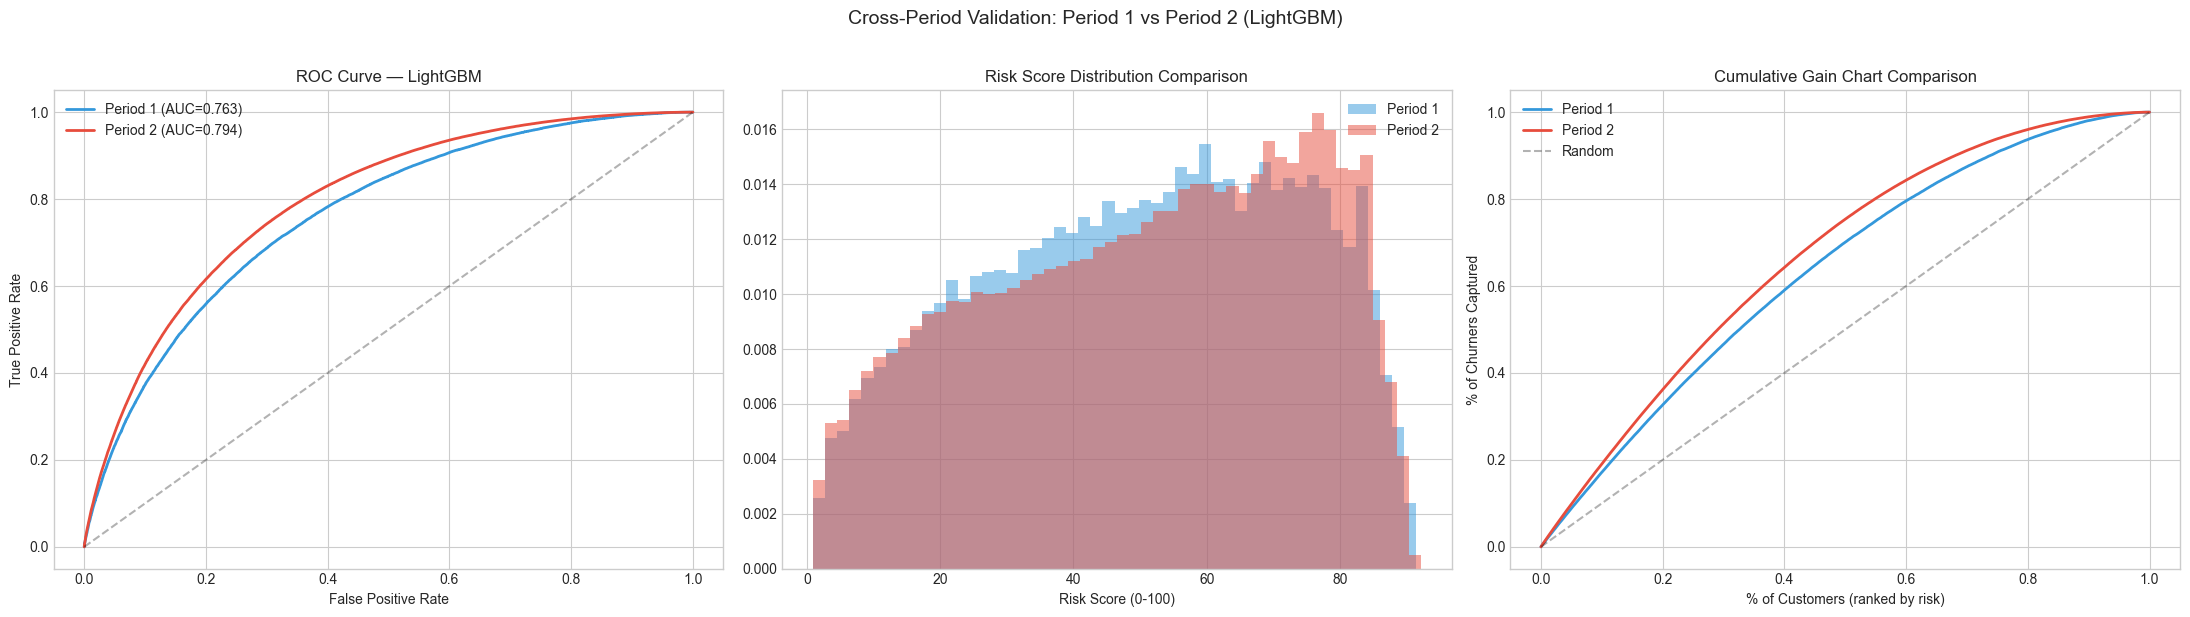


Risk Level Breakdown — Period 2 (LightGBM):

          1-Low (0-25):  99,686 customers ( 18.5%) | Actual churn: 7.9%
      2-Medium (26-50): 148,778 customers ( 27.5%) | Actual churn: 27.0%
        3-High (51-75): 189,195 customers ( 35.0%) | Actual churn: 54.6%
   4-Critical (76-100): 102,500 customers ( 19.0%) | Actual churn: 77.7%

--- Churn Rate Comparison ---
  Period 1: 48.33%
  Period 2: 42.75%


In [19]:
# === Visual comparison: Period 1 vs Period 2 ===
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Get best model predictions for period 2
_, bm = models[best_name]
if models[best_name][0] == 'scaled':
    probs_p2 = bm.predict_proba(scaler.transform(X2))[:, 1]
else:
    probs_p2 = bm.predict_proba(X2)[:, 1]

# 1. ROC Curve comparison
fpr1, tpr1, _ = roc_curve(y_test, risk_probs)
fpr2, tpr2, _ = roc_curve(y2, probs_p2)
auc1 = roc_auc_score(y_test, risk_probs)
auc2 = roc_auc_score(y2, probs_p2)
axes[0].plot(fpr1, tpr1, label=f'Period 1 (AUC={auc1:.3f})', color='#3498db', linewidth=2)
axes[0].plot(fpr2, tpr2, label=f'Period 2 (AUC={auc2:.3f})', color='#e74c3c', linewidth=2)
axes[0].plot([0,1], [0,1], 'k--', alpha=0.3)
axes[0].set_title(f'ROC Curve — {best_name}', fontsize=12)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=10)

# 2. Risk Score distribution comparison
axes[1].hist(risk_probs * 100, bins=50, alpha=0.5, label='Period 1', color='#3498db', density=True)
axes[1].hist(probs_p2 * 100, bins=50, alpha=0.5, label='Period 2', color='#e74c3c', density=True)
axes[1].set_title('Risk Score Distribution Comparison', fontsize=12)
axes[1].set_xlabel('Risk Score (0-100)'); axes[1].legend(fontsize=10)

# 3. Gain Chart comparison
sorted_idx1 = np.argsort(-risk_probs)
y_sorted1 = y_test[sorted_idx1]
cum1 = np.cumsum(y_sorted1) / y_sorted1.sum()
pct1 = np.arange(1, len(y_sorted1)+1) / len(y_sorted1)

sorted_idx2 = np.argsort(-probs_p2)
y_sorted2 = y2[sorted_idx2]
cum2 = np.cumsum(y_sorted2) / y_sorted2.sum()
pct2 = np.arange(1, len(y_sorted2)+1) / len(y_sorted2)

axes[2].plot(pct1, cum1, label='Period 1', color='#3498db', linewidth=2)
axes[2].plot(pct2, cum2, label='Period 2', color='#e74c3c', linewidth=2)
axes[2].plot([0,1], [0,1], 'k--', alpha=0.3, label='Random')
axes[2].set_title('Cumulative Gain Chart Comparison', fontsize=12)
axes[2].set_xlabel('% of Customers (ranked by risk)')
axes[2].set_ylabel('% of Churners Captured')
axes[2].legend(fontsize=10)

plt.suptitle(f'Cross-Period Validation: Period 1 vs Period 2 ({best_name})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Risk level breakdown for period 2
risk_scores_p2 = (probs_p2 * 100).round(1)
risk_df2 = pd.DataFrame({
    'risk_score': risk_scores_p2,
    'actual_churn': y2
})
risk_df2['risk_level'] = risk_df2['risk_score'].apply(risk_level)

level_stats2 = risk_df2.groupby('risk_level').agg(
    count=('actual_churn', 'size'),
    actual_churn_rate=('actual_churn', 'mean'),
    avg_score=('risk_score', 'mean')
).reset_index()

print(f"\nRisk Level Breakdown — Period 2 ({best_name}):\n")
for _, row in level_stats2.iterrows():
    pct = row['count'] / len(risk_df2) * 100
    print(f"  {row['risk_level']:>20s}: {row['count']:>7,} customers ({pct:5.1f}%) | Actual churn: {row['actual_churn_rate']:.1%}")

# Compare churn rates between periods
print(f"\n--- Churn Rate Comparison ---")
print(f"  Period 1: {y_test.mean():.2%}")
print(f"  Period 2: {y2.mean():.2%}")

## Phase 6: Validate All Remaining Periods
ทดสอบโมเดลเดิม (train จากงวด 1216→0102) กับทุกงวดที่เหลือ  
เพื่อดูว่าโมเดล **เสถียรข้ามเวลา** หรือ performance ตกลงเมื่อห่างจากงวด train มากขึ้น

In [20]:
%%time
# === Validate on ALL remaining periods ===
validation_files = [
    ('Period 2', 'Churn_2026_0102_0117.csv', '2 ม.ค. → 17 ม.ค.'),
    ('Period 3', 'Churn_2026_0117_0201.csv', '17 ม.ค. → 1 ก.พ.'),
    ('Period 4', 'Churn_2026_0201_0216.csv', '1 ก.พ. → 16 ก.พ.'),
    ('Period 5', 'Churn_2026_0216_0301.csv', '16 ก.พ. → 1 มี.ค.'),
]

all_period_results = []

# Period 1 baseline (from training)
all_period_results.append({
    'Period': 'Period 1 (Train)',
    'File': 'Churn_2025_1216_0102.csv',
    'Date_Range': '16 ธ.ค. → 2 ม.ค.',
    'Total_Customers': len(df_eligible),
    'Churn_Rate': y_test.mean(),
    'AUC-ROC': roc_auc_score(y_test, risk_probs),
    'AUC-PR': average_precision_score(y_test, risk_probs),
    'F1': f1_score(y_test, (risk_probs >= 0.5).astype(int)),
    'Accuracy': ((risk_probs >= 0.5).astype(int) == y_test).mean()
})

for period_name, filename, date_range in validation_files:
    print(f"\n{'='*60}")
    print(f"Processing {period_name}: {filename}")
    print(f"{'='*60}")
    
    # Load
    df_p = pd.read_csv(filename, low_memory=False)
    item_cols_p = [c for c in df_p.columns if c.startswith('item')]
    print(f"  Shape: {df_p.shape[0]:,} x {df_p.shape[1]}")
    print(f"  Rounds: {len(item_cols_p)} ({item_cols_p[0]} → {item_cols_p[-1]})")
    
    # Prepare
    target_col_p = item_cols_p[-1]
    feat_item_cols_p = item_cols_p[:-1]
    mat_p = df_p[item_cols_p].apply(pd.to_numeric, errors='coerce')
    
    first_reg_p = mat_p.notna().values.argmax(axis=1)
    tenure_p = len(item_cols_p) - first_reg_p
    exclude_p = tenure_p < MIN_TENURE
    df_p_elig = df_p[~exclude_p].copy()
    mat_p_elig = mat_p[~exclude_p].copy()
    df_p_elig['churn'] = (df_p_elig[target_col_p] == 0).astype(int)
    
    print(f"  Eligible: {len(df_p_elig):,} (excluded {exclude_p.sum():,})")
    print(f"  Churn rate: {df_p_elig['churn'].mean():.2%}")
    
    # Feature engineering
    feats_p = engineer_features(df_p_elig, mat_p_elig, feat_item_cols_p)
    X_p = feats_p[feature_cols].fillna(0)
    y_p = df_p_elig['churn'].values
    
    # Predict with best model
    _, bm = models[best_name]
    if models[best_name][0] == 'scaled':
        probs_p = bm.predict_proba(scaler.transform(X_p))[:, 1]
    else:
        probs_p = bm.predict_proba(X_p)[:, 1]
    
    preds_p = (probs_p >= 0.5).astype(int)
    
    auc_roc = roc_auc_score(y_p, probs_p)
    auc_pr = average_precision_score(y_p, probs_p)
    f1 = f1_score(y_p, preds_p)
    acc = (preds_p == y_p).mean()
    
    print(f"  AUC-ROC: {auc_roc:.4f} | F1: {f1:.4f} | Accuracy: {acc:.4f}")
    
    # Risk level breakdown
    risk_s = (probs_p * 100).round(1)
    for level_name, lo, hi in [('Low', 0, 25), ('Medium', 26, 50), ('High', 51, 75), ('Critical', 76, 100)]:
        mask = (risk_s >= lo) & (risk_s <= hi)
        if mask.sum() > 0:
            actual = y_p[mask].mean()
            print(f"    {level_name:>10s}: {mask.sum():>7,} ({mask.mean():.1%}) | Actual churn: {actual:.1%}")
    
    all_period_results.append({
        'Period': period_name,
        'File': filename,
        'Date_Range': date_range,
        'Total_Customers': len(df_p_elig),
        'Churn_Rate': y_p.mean(),
        'AUC-ROC': auc_roc,
        'AUC-PR': auc_pr,
        'F1': f1,
        'Accuracy': acc
    })

# Summary table
print(f"\n\n{'='*80}")
print(f"SUMMARY: {best_name} Performance Across All Periods")
print(f"{'='*80}")
summary_df = pd.DataFrame(all_period_results)
print(summary_df[['Period', 'Total_Customers', 'Churn_Rate', 'AUC-ROC', 'AUC-PR', 'F1', 'Accuracy']].to_string(
    index=False, float_format='{:.4f}'.format))


Processing Period 2: Churn_2026_0102_0117.csv


  Shape: 557,461 x 70
  Rounds: 62 (item2023_07_01 → item2026_01_17)


  Eligible: 540,159 (excluded 17,302)
  Churn rate: 42.75%


  Computing row-wise features...


  AUC-ROC: 0.7941 | F1: 0.7001 | Accuracy: 0.7096
           Low:  99,686 (18.5%) | Actual churn: 7.9%
        Medium: 143,841 (26.6%) | Actual churn: 27.3%
          High: 183,107 (33.9%) | Actual churn: 55.1%
      Critical:  94,078 (17.4%) | Actual churn: 78.3%

Processing Period 3: Churn_2026_0117_0201.csv


...

  AUC-ROC: 0.7955 | F1: 0.6932 | Accuracy: 0.7001
           Low: 104,351 (17.0%) | Actual churn: 6.5%
        Medium: 158,882 (25.8%) | Actual churn: 24.1%
          High: 216,150 (35.1%) | Actual churn: 51.6%
      Critical: 114,204 (18.6%) | Actual churn: 76.9%

Processing Period 5: Churn_2026_0216_0301.csv


  Shape: 655,296 x 73
  Rounds: 65 (item2023_07_01 → item2026_03_01)


  Eligible: 636,589 (excluded 18,707)
  Churn rate: 44.58%


  Computing row-wise features...


  AUC-ROC: 0.7965 | F1: 0.7126 | Accuracy: 0.7098
           Low: 107,274 (16.9%) | Actual churn: 7.9%
        Medium: 165,615 (26.0%) | Actual churn: 27.6%
          High: 227,197 (35.7%) | Actual churn: 55.9%
      Critical: 113,719 (17.9%) | Actual churn: 80.4%


SUMMARY: LightGBM Performance Across All Periods
          Period  Total_Customers  Churn_Rate  AUC-ROC  AUC-PR     F1  Accuracy
Period 1 (Train)           571080      0.4833   0.7627  0.7298 0.6935    0.6931
        Period 2           540159      0.4275   0.7941  0.7177 0.7001    0.7096
        Period 3           612867      0.4287   0.7848  0.7066 0.6949    0.6954
        Period 4           615232      0.4129   0.7955  0.7077 0.6932    0.7001
        Period 5           636589      0.4458   0.7965  0.7382 0.7126    0.7098
CPU times: user 6min 30s, sys: 48 s, total: 7min 18s
Wall time: 11min 9s


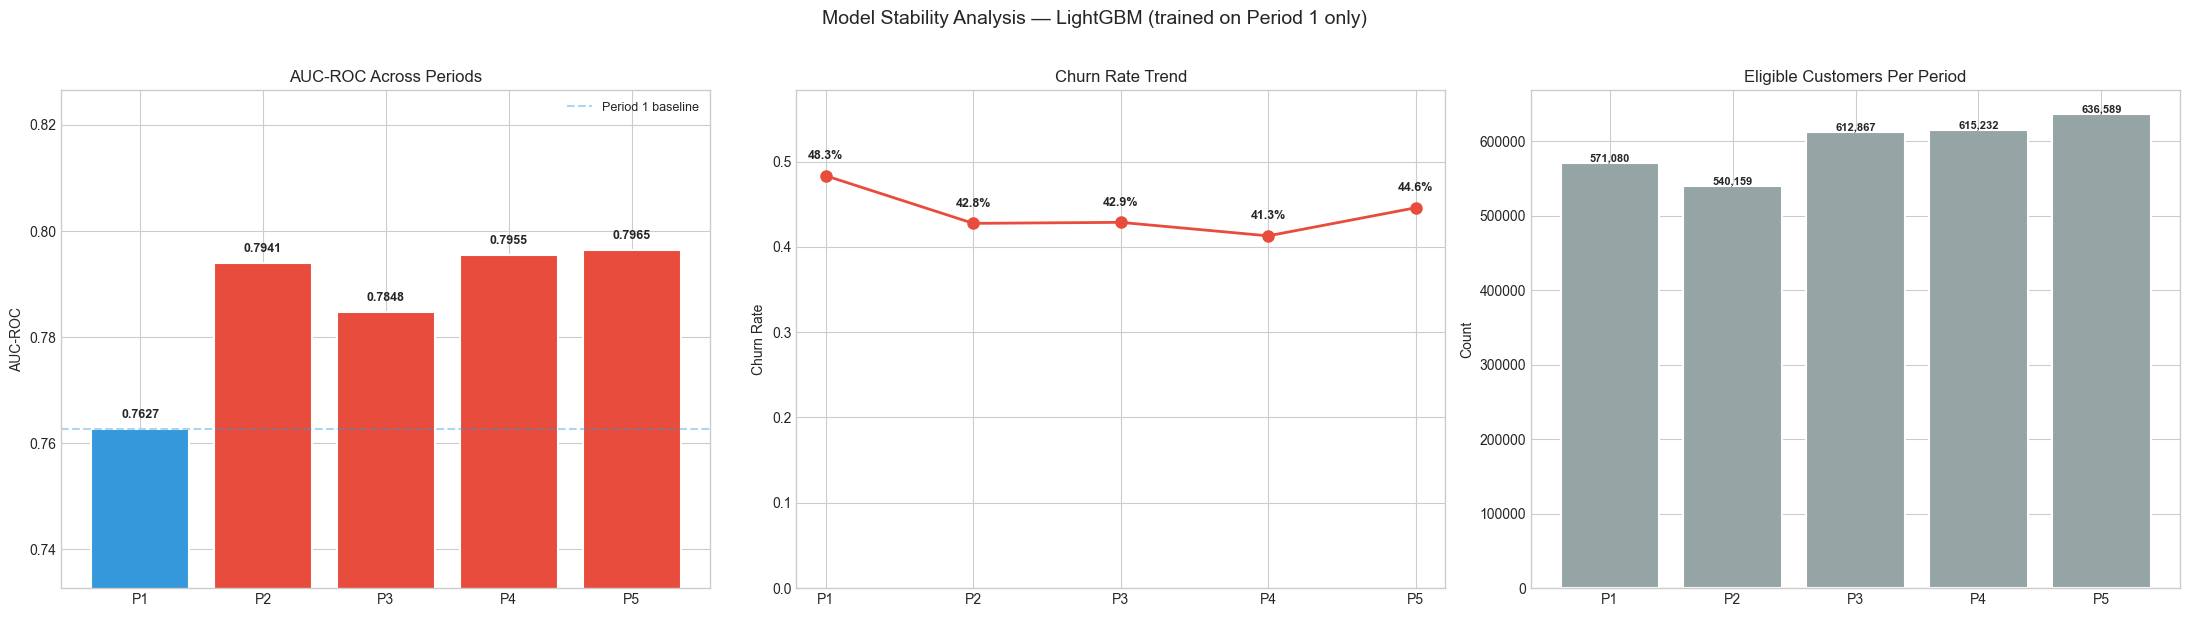


--- Model Stability Summary ---
  AUC-ROC range across validation periods: 0.7848 — 0.7965 (spread: 0.0118)
  Verdict: VERY STABLE — โมเดลเสถียรมาก ใช้ได้จริงข้ามงวด


In [21]:
# === AUC-ROC Timeline + Churn Rate Trend ===
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

periods = summary_df['Period'].tolist()
x_labels = [f"P{i+1}" for i in range(len(periods))]

# 1. AUC-ROC across periods
auc_vals = summary_df['AUC-ROC'].values
colors_auc = ['#3498db'] + ['#e74c3c'] * (len(auc_vals) - 1)
bars1 = axes[0].bar(x_labels, auc_vals, color=colors_auc, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars1, auc_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_ylim(min(auc_vals) - 0.03, max(auc_vals) + 0.03)
axes[0].axhline(auc_vals[0], color='#3498db', linestyle='--', alpha=0.4, label='Period 1 baseline')
axes[0].set_title('AUC-ROC Across Periods', fontsize=12)
axes[0].set_ylabel('AUC-ROC')
axes[0].legend(fontsize=9)

# 2. Churn Rate trend
churn_rates = summary_df['Churn_Rate'].values
axes[1].plot(x_labels, churn_rates, 'o-', color='#e74c3c', linewidth=2, markersize=8)
for i, (x, cr) in enumerate(zip(x_labels, churn_rates)):
    axes[1].annotate(f'{cr:.1%}', (x, cr), textcoords="offset points",
                    xytext=(0, 12), ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Churn Rate Trend', fontsize=12)
axes[1].set_ylabel('Churn Rate')
axes[1].set_ylim(0, max(churn_rates) + 0.1)

# 3. Customer count per period
cust_counts = summary_df['Total_Customers'].values
bars3 = axes[2].bar(x_labels, cust_counts, color='#95a5a6', edgecolor='white', linewidth=1.5)
for bar, cnt in zip(bars3, cust_counts):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                f'{cnt:,.0f}', ha='center', fontsize=8, fontweight='bold')
axes[2].set_title('Eligible Customers Per Period', fontsize=12)
axes[2].set_ylabel('Count')

plt.suptitle(f'Model Stability Analysis — {best_name} (trained on Period 1 only)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Final verdict
auc_min = auc_vals[1:].min()
auc_max = auc_vals[1:].max()
auc_range = auc_max - auc_min
print(f"\n--- Model Stability Summary ---")
print(f"  AUC-ROC range across validation periods: {auc_min:.4f} — {auc_max:.4f} (spread: {auc_range:.4f})")
if auc_range < 0.02:
    print(f"  Verdict: VERY STABLE — โมเดลเสถียรมาก ใช้ได้จริงข้ามงวด")
elif auc_range < 0.05:
    print(f"  Verdict: STABLE — โมเดลเสถียรดี มีความผันผวนเล็กน้อย")
else:
    print(f"  Verdict: UNSTABLE — โมเดลไม่เสถียร ควร retrain ด้วยข้อมูลหลายงวด")

## Phase 7: Multi-Period Retrain
รวมข้อมูลหลายงวด train ใหม่ เพื่อให้โมเดลเห็น pattern ที่หลากหลายขึ้น  
- **Train:** Period 1-3 (16 ธ.ค. → 1 ก.พ.)  
- **Validate:** Period 4 (1 ก.พ. → 16 ก.พ.)  
- **Test:** Period 5 (16 ก.พ. → 1 มี.ค.)  
เปรียบเทียบกับ single-period training

In [22]:
%%time
# === Build multi-period training dataset ===
# Train: Period 1, 2, 3 | Validate: Period 4 | Test: Period 5

train_files = [
    ('Period 1', 'Churn_2025_1216_0102.csv'),
    ('Period 2', 'Churn_2026_0102_0117.csv'),
    ('Period 3', 'Churn_2026_0117_0201.csv'),
]
val_file = ('Period 4', 'Churn_2026_0201_0216.csv')
test_file = ('Period 5', 'Churn_2026_0216_0301.csv')

all_X_train = []
all_y_train = []

for period_name, filename in train_files:
    print(f"\n--- Processing {period_name}: {filename} ---")
    df_p = pd.read_csv(filename, low_memory=False)
    item_cols_p = [c for c in df_p.columns if c.startswith('item')]
    
    target_col_p = item_cols_p[-1]
    feat_item_cols_p = item_cols_p[:-1]
    mat_p = df_p[item_cols_p].apply(pd.to_numeric, errors='coerce')
    
    first_reg_p = mat_p.notna().values.argmax(axis=1)
    tenure_p = len(item_cols_p) - first_reg_p
    exclude_p = tenure_p < MIN_TENURE
    df_p_elig = df_p[~exclude_p].copy()
    mat_p_elig = mat_p[~exclude_p].copy()
    df_p_elig['churn'] = (df_p_elig[target_col_p] == 0).astype(int)
    
    print(f"  Eligible: {len(df_p_elig):,} | Churn rate: {df_p_elig['churn'].mean():.2%}")
    
    feats_p = engineer_features(df_p_elig, mat_p_elig, feat_item_cols_p)
    X_p = feats_p[feature_cols].fillna(0)
    y_p = df_p_elig['churn'].values
    
    all_X_train.append(X_p)
    all_y_train.append(y_p)

# Stack all training data
X_multi_train = pd.concat(all_X_train, ignore_index=True)
y_multi_train = np.concatenate(all_y_train)

print(f"\n{'='*60}")
print(f"Combined Training Set:")
print(f"  Samples: {len(X_multi_train):,}")
print(f"  Churn rate: {y_multi_train.mean():.2%}")
print(f"  Features: {X_multi_train.shape[1]}")

# === Prepare Validation set (Period 4) ===
print(f"\n--- Preparing Validation: {val_file[0]} ---")
df_val = pd.read_csv(val_file[1], low_memory=False)
item_cols_val = [c for c in df_val.columns if c.startswith('item')]
mat_val = df_val[item_cols_val].apply(pd.to_numeric, errors='coerce')
first_reg_val = mat_val.notna().values.argmax(axis=1)
tenure_val = len(item_cols_val) - first_reg_val
exclude_val = tenure_val < MIN_TENURE
df_val_elig = df_val[~exclude_val].copy()
mat_val_elig = mat_val[~exclude_val].copy()
df_val_elig['churn'] = (df_val_elig[item_cols_val[-1]] == 0).astype(int)
feats_val = engineer_features(df_val_elig, mat_val_elig, item_cols_val[:-1])
X_val = feats_val[feature_cols].fillna(0)
y_val = df_val_elig['churn'].values
print(f"  Validation: {len(X_val):,} | Churn rate: {y_val.mean():.2%}")

# === Prepare Test set (Period 5) ===
print(f"\n--- Preparing Test: {test_file[0]} ---")
df_tst = pd.read_csv(test_file[1], low_memory=False)
item_cols_tst = [c for c in df_tst.columns if c.startswith('item')]
mat_tst = df_tst[item_cols_tst].apply(pd.to_numeric, errors='coerce')
first_reg_tst = mat_tst.notna().values.argmax(axis=1)
tenure_tst = len(item_cols_tst) - first_reg_tst
exclude_tst = tenure_tst < MIN_TENURE
df_tst_elig = df_tst[~exclude_tst].copy()
mat_tst_elig = mat_tst[~exclude_tst].copy()
df_tst_elig['churn'] = (df_tst_elig[item_cols_tst[-1]] == 0).astype(int)
feats_tst = engineer_features(df_tst_elig, mat_tst_elig, item_cols_tst[:-1])
X_tst = feats_tst[feature_cols].fillna(0)
y_tst = df_tst_elig['churn'].values
print(f"  Test: {len(X_tst):,} | Churn rate: {y_tst.mean():.2%}")


--- Processing Period 1: Churn_2025_1216_0102.csv ---


  Eligible: 571,080 | Churn rate: 48.33%


  Computing row-wise features...



--- Processing Period 2: Churn_2026_0102_0117.csv ---


  Eligible: 540,159 | Churn rate: 42.75%


...


Combined Training Set:
  Samples: 1,724,106
  Churn rate: 44.64%
  Features: 33

--- Preparing Validation: Period 4 ---


  Computing row-wise features...


  Validation: 615,232 | Churn rate: 41.29%

--- Preparing Test: Period 5 ---


  Computing row-wise features...


  Test: 636,589 | Churn rate: 44.58%
CPU times: user 6min 26s, sys: 54 s, total: 7min 20s
Wall time: 12min 48s


In [23]:
%%time
# === Train Multi-Period Models ===
print("Training multi-period models...")
print(f"Train size: {X_multi_train.shape[0]:,} | Val size: {X_val.shape[0]:,} | Test size: {X_tst.shape[0]:,}")

# Scale
scaler_multi = StandardScaler()
X_mt_scaled = scaler_multi.fit_transform(X_multi_train)
X_val_scaled = scaler_multi.transform(X_val)
X_tst_scaled = scaler_multi.transform(X_tst)

scale_pos_multi = (y_multi_train == 0).sum() / (y_multi_train == 1).sum()

models_multi = {}

# 1. Logistic Regression
lr_m = LogisticRegression(max_iter=1000, class_weight='balanced', C=0.1, random_state=42)
lr_m.fit(X_mt_scaled, y_multi_train)
models_multi['Logistic Regression'] = ('scaled', lr_m)
print("1/4 Logistic Regression done")

# 2. Random Forest
rf_m = RandomForestClassifier(n_estimators=300, max_depth=15, min_samples_leaf=50,
                              class_weight='balanced', random_state=42, n_jobs=-1)
rf_m.fit(X_multi_train, y_multi_train)
models_multi['Random Forest'] = ('raw', rf_m)
print("2/4 Random Forest done")

# 3. XGBoost (use validation set for early stopping)
xgb_m = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    scale_pos_weight=scale_pos_multi, subsample=0.8, colsample_bytree=0.8,
    eval_metric='auc', random_state=42, n_jobs=-1,
    early_stopping_rounds=30)
xgb_m.fit(X_multi_train, y_multi_train, eval_set=[(X_val, y_val)], verbose=False)
models_multi['XGBoost'] = ('raw', xgb_m)
print(f"3/4 XGBoost done (best iter: {xgb_m.best_iteration})")

# 4. LightGBM
lgb_m = lgb.LGBMClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    scale_pos_weight=scale_pos_multi, subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbose=-1)
lgb_m.fit(X_multi_train, y_multi_train, eval_set=[(X_val, y_val)],
          callbacks=[lgb.early_stopping(30, verbose=False)])
models_multi['LightGBM'] = ('raw', lgb_m)
print(f"4/4 LightGBM done (best iter: {lgb_m.best_iteration_})")
print("\nAll multi-period models trained!")

Training multi-period models...
Train size: 1,724,106 | Val size: 615,232 | Test size: 636,589


1/4 Logistic Regression done


2/4 Random Forest done


3/4 XGBoost done (best iter: 235)


4/4 LightGBM done (best iter: 500)

All multi-period models trained!
CPU times: user 47min 5s, sys: 1min 46s, total: 48min 52s
Wall time: 16min 28s


In [24]:
# === Compare Single-Period vs Multi-Period on TEST SET (Period 5) ===
print("=" * 80)
print("COMPARISON: Single-Period vs Multi-Period Training → Test on Period 5")
print("=" * 80)

# Single-period results on Period 5
print("\n📊 Single-Period (trained on P1 only):")
single_results_p5 = []
for name, (dtype, model) in models.items():
    if dtype == 'scaled':
        Xt = scaler.transform(X_tst)
    else:
        Xt = X_tst
    probs = model.predict_proba(Xt)[:, 1]
    preds = (probs >= 0.5).astype(int)
    single_results_p5.append({
        'Model': name,
        'AUC-ROC': roc_auc_score(y_tst, probs),
        'AUC-PR': average_precision_score(y_tst, probs),
        'F1': f1_score(y_tst, preds),
        'Accuracy': (preds == y_tst).mean()
    })
single_df = pd.DataFrame(single_results_p5).sort_values('AUC-ROC', ascending=False)
print(single_df.to_string(index=False, float_format='{:.4f}'.format))

# Multi-period results on Period 5
print("\n📊 Multi-Period (trained on P1+P2+P3, validated on P4):")
multi_results_p5 = []
for name, (dtype, model) in models_multi.items():
    if dtype == 'scaled':
        Xt = scaler_multi.transform(X_tst)
    else:
        Xt = X_tst
    probs = model.predict_proba(Xt)[:, 1]
    preds = (probs >= 0.5).astype(int)
    multi_results_p5.append({
        'Model': name,
        'AUC-ROC': roc_auc_score(y_tst, probs),
        'AUC-PR': average_precision_score(y_tst, probs),
        'F1': f1_score(y_tst, preds),
        'Accuracy': (preds == y_tst).mean()
    })
multi_df = pd.DataFrame(multi_results_p5).sort_values('AUC-ROC', ascending=False)
print(multi_df.to_string(index=False, float_format='{:.4f}'.format))

# Delta
print("\n📊 Improvement (Multi - Single):")
for _, s in single_df.iterrows():
    m = multi_df[multi_df['Model'] == s['Model']].iloc[0]
    d_auc = m['AUC-ROC'] - s['AUC-ROC']
    d_f1 = m['F1'] - s['F1']
    d_acc = m['Accuracy'] - s['Accuracy']
    sign = lambda x: f"+{x:.4f}" if x >= 0 else f"{x:.4f}"
    print(f"  {s['Model']:>22s}: AUC-ROC {sign(d_auc)} | F1 {sign(d_f1)} | Acc {sign(d_acc)}")

# Best multi-period model
best_multi_name = multi_df.iloc[0]['Model']
best_multi_auc = multi_df.iloc[0]['AUC-ROC']
best_single_auc = single_df[single_df['Model'] == best_multi_name].iloc[0]['AUC-ROC']
print(f"\nBest Multi-Period: {best_multi_name} (AUC: {best_multi_auc:.4f} vs Single: {best_single_auc:.4f})")

COMPARISON: Single-Period vs Multi-Period Training → Test on Period 5

📊 Single-Period (trained on P1 only):


              Model  AUC-ROC  AUC-PR     F1  Accuracy
      Random Forest   0.7969  0.7383 0.7136    0.7091
            XGBoost   0.7966  0.7382 0.7127    0.7099
           LightGBM   0.7965  0.7382 0.7126    0.7098
Logistic Regression   0.7903  0.7275 0.7094    0.7045

📊 Multi-Period (trained on P1+P2+P3, validated on P4):


              Model  AUC-ROC  AUC-PR     F1  Accuracy
      Random Forest   0.7986  0.7405 0.7110    0.7180
           LightGBM   0.7981  0.7403 0.7089    0.7187
            XGBoost   0.7981  0.7404 0.7091    0.7184
Logistic Regression   0.7914  0.7289 0.7066    0.7128

📊 Improvement (Multi - Single):
           Random Forest: AUC-ROC +0.0017 | F1 -0.0026 | Acc +0.0089
                 XGBoost: AUC-ROC +0.0016 | F1 -0.0036 | Acc +0.0086
                LightGBM: AUC-ROC +0.0016 | F1 -0.0037 | Acc +0.0089
     Logistic Regression: AUC-ROC +0.0010 | F1 -0.0029 | Acc +0.0083

Best Multi-Period: Random Forest (AUC: 0.7986 vs Single: 0.7969)


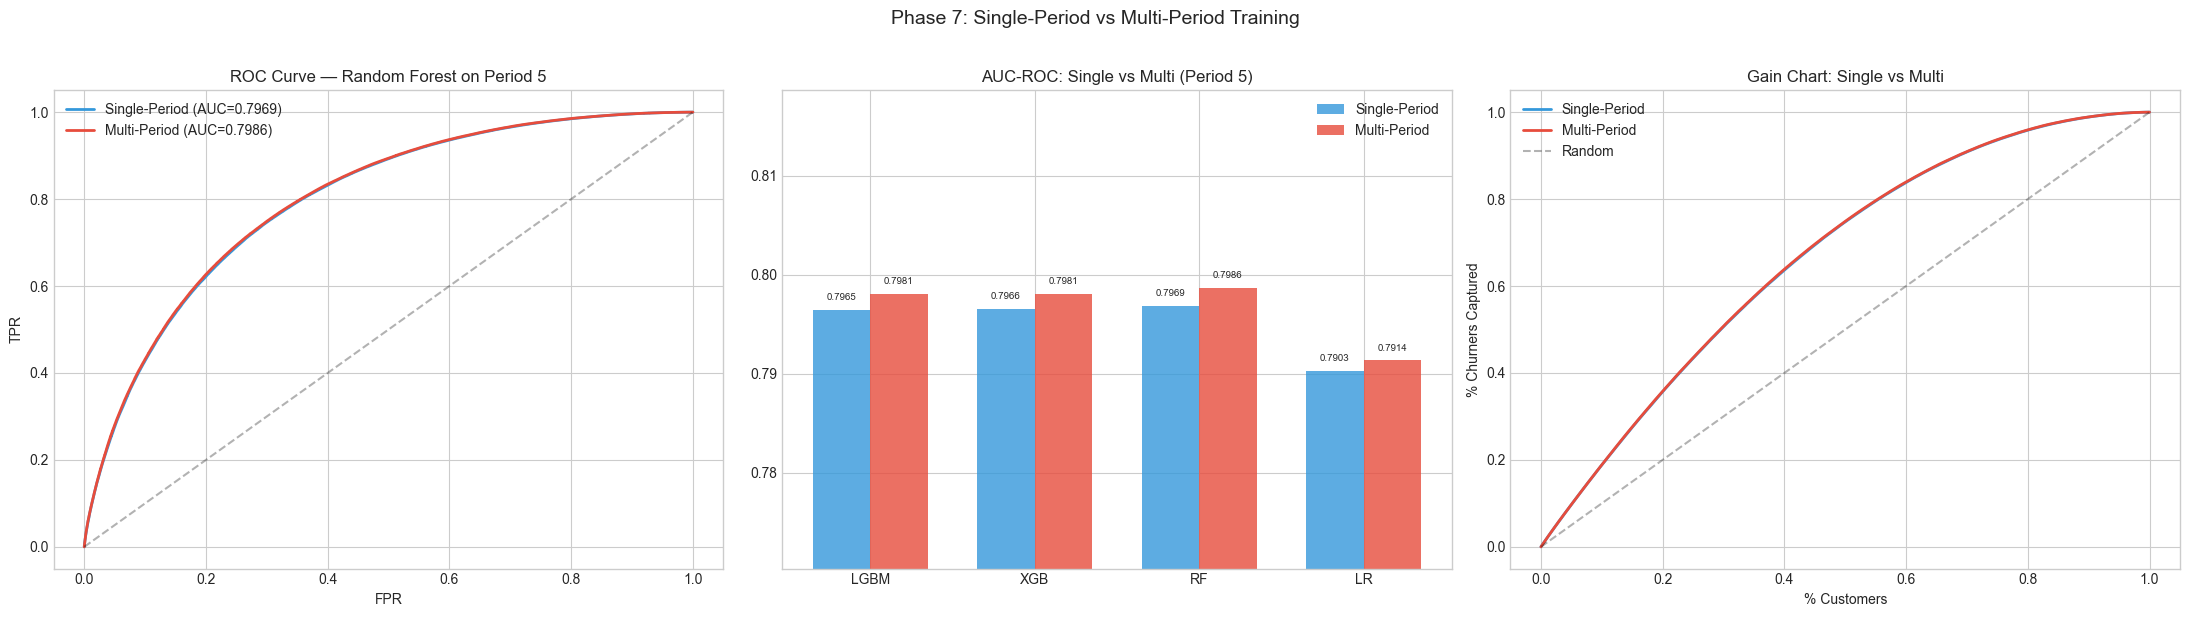


Risk Level Comparison on Period 5 (Random Forest):
       Level |  Single Churn% |  Multi Churn%
------------------------------------------------
         Low |          7.3% |         9.1%
      Medium |         26.6% |        30.3%
        High |         56.0% |        58.0%
    Critical |         80.5% |        81.0%


In [25]:
# === Visual Comparison: Single vs Multi on Period 5 ===
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Get best model probs for both
_, bm_single = models[best_multi_name]
_, bm_multi = models_multi[best_multi_name]

if models[best_multi_name][0] == 'scaled':
    probs_single = bm_single.predict_proba(scaler.transform(X_tst))[:, 1]
else:
    probs_single = bm_single.predict_proba(X_tst)[:, 1]

if models_multi[best_multi_name][0] == 'scaled':
    probs_multi = bm_multi.predict_proba(scaler_multi.transform(X_tst))[:, 1]
else:
    probs_multi = bm_multi.predict_proba(X_tst)[:, 1]

# 1. ROC Curve
fpr_s, tpr_s, _ = roc_curve(y_tst, probs_single)
fpr_m, tpr_m, _ = roc_curve(y_tst, probs_multi)
auc_s = roc_auc_score(y_tst, probs_single)
auc_m = roc_auc_score(y_tst, probs_multi)
axes[0].plot(fpr_s, tpr_s, label=f'Single-Period (AUC={auc_s:.4f})', color='#3498db', linewidth=2)
axes[0].plot(fpr_m, tpr_m, label=f'Multi-Period (AUC={auc_m:.4f})', color='#e74c3c', linewidth=2)
axes[0].plot([0,1], [0,1], 'k--', alpha=0.3)
axes[0].set_title(f'ROC Curve — {best_multi_name} on Period 5', fontsize=12)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].legend(fontsize=10)

# 2. Bar chart comparison (all models)
x_pos = np.arange(len(single_df))
width = 0.35
s_aucs = [single_df[single_df['Model']==n].iloc[0]['AUC-ROC'] for n in ['LightGBM','XGBoost','Random Forest','Logistic Regression']]
m_aucs = [multi_df[multi_df['Model']==n].iloc[0]['AUC-ROC'] for n in ['LightGBM','XGBoost','Random Forest','Logistic Regression']]
names_short = ['LGBM', 'XGB', 'RF', 'LR']

bars_s = axes[1].bar(x_pos - width/2, s_aucs, width, label='Single-Period', color='#3498db', alpha=0.8)
bars_m = axes[1].bar(x_pos + width/2, m_aucs, width, label='Multi-Period', color='#e74c3c', alpha=0.8)
for bar, val in zip(bars_s, s_aucs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, f'{val:.4f}', ha='center', fontsize=7)
for bar, val in zip(bars_m, m_aucs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, f'{val:.4f}', ha='center', fontsize=7)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(names_short)
axes[1].set_ylim(min(s_aucs + m_aucs) - 0.02, max(s_aucs + m_aucs) + 0.02)
axes[1].set_title('AUC-ROC: Single vs Multi (Period 5)', fontsize=12)
axes[1].legend(fontsize=10)

# 3. Gain Chart comparison
sorted_s = np.argsort(-probs_single)
sorted_m = np.argsort(-probs_multi)
y_s = y_tst[sorted_s]; y_m = y_tst[sorted_m]
cum_s = np.cumsum(y_s) / y_s.sum()
cum_m = np.cumsum(y_m) / y_m.sum()
pct = np.arange(1, len(y_tst)+1) / len(y_tst)

axes[2].plot(pct, cum_s, label='Single-Period', color='#3498db', linewidth=2)
axes[2].plot(pct, cum_m, label='Multi-Period', color='#e74c3c', linewidth=2)
axes[2].plot([0,1], [0,1], 'k--', alpha=0.3, label='Random')
axes[2].set_title('Gain Chart: Single vs Multi', fontsize=12)
axes[2].set_xlabel('% Customers'); axes[2].set_ylabel('% Churners Captured')
axes[2].legend(fontsize=10)

plt.suptitle('Phase 7: Single-Period vs Multi-Period Training', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Risk level comparison
print(f"\nRisk Level Comparison on Period 5 ({best_multi_name}):")
print(f"{'Level':>12s} | {'Single Churn%':>14s} | {'Multi Churn%':>13s}")
print("-" * 48)
for level_name, lo, hi in [('Low', 0, 25), ('Medium', 26, 50), ('High', 51, 75), ('Critical', 76, 100)]:
    rs = (probs_single * 100).round(1)
    rm = (probs_multi * 100).round(1)
    mask_s = (rs >= lo) & (rs <= hi)
    mask_m = (rm >= lo) & (rm <= hi)
    cr_s = y_tst[mask_s].mean() if mask_s.sum() > 0 else 0
    cr_m = y_tst[mask_m].mean() if mask_m.sum() > 0 else 0
    print(f"{level_name:>12s} | {cr_s:>13.1%} | {cr_m:>12.1%}")

## Phase 8: Production Scoring — งวด 0316
ใช้โมเดลที่ดีที่สุด (Multi-Period Random Forest) ทำนายลูกค้าที่ซื้องวด 0301  
ว่าจะซื้อซ้ำงวด 0316 หรือไม่ → สร้าง Risk Score + Export CSV

In [26]:
%%time
# === Load prediction file ===
df_pred = pd.read_csv('Churn_Pred_2026_0316.csv', low_memory=False)
item_cols_pred = [c for c in df_pred.columns if c.startswith('item')]

print(f"File: Churn_Pred_2026_0316.csv")
print(f"Shape: {df_pred.shape[0]:,} rows x {df_pred.shape[1]} cols")
print(f"Item rounds: {len(item_cols_pred)} ({item_cols_pred[0]} → {item_cols_pred[-1]})")
print(f"No target column — pure prediction mode")

# Use ALL item rounds as features (no target to exclude)
feat_item_cols_pred = item_cols_pred
mat_pred = df_pred[item_cols_pred].apply(pd.to_numeric, errors='coerce')

# Exclude new customers (tenure < 3)
first_reg_pred = mat_pred.notna().values.argmax(axis=1)
tenure_pred = len(item_cols_pred) - first_reg_pred
exclude_pred = tenure_pred < MIN_TENURE
df_pred_elig = df_pred[~exclude_pred].copy()
mat_pred_elig = mat_pred[~exclude_pred].copy()

# Also keep excluded ones separately for reporting
df_pred_new = df_pred[exclude_pred].copy()

print(f"\nTotal customers:       {len(df_pred):,}")
print(f"Eligible (tenure>=3):  {len(df_pred_elig):,}")
print(f"New customers:         {len(df_pred_new):,}")

# Feature engineering
print("\n--- Engineering features ---")
feats_pred = engineer_features(df_pred_elig, mat_pred_elig, feat_item_cols_pred)
X_pred = feats_pred[feature_cols].fillna(0)
print(f"Features shape: {X_pred.shape}")

File: Churn_Pred_2026_0316.csv
Shape: 594,368 rows x 72 cols
Item rounds: 65 (item2023_07_01 → item2026_03_01)
No target column — pure prediction mode



Total customers:       594,368
Eligible (tenure>=3):  569,087
New customers:         25,281

--- Engineering features ---


  Computing row-wise features...


Features shape: (569087, 33)
CPU times: user 1min 19s, sys: 13 s, total: 1min 32s
Wall time: 2min 51s


Scored 569,087 customers for round 0316

Risk Level Distribution:
             count  avg_score  pct
risk_level                        
Low         125465       13.7 22.0
Medium      163167       37.9 28.7
High        188775       62.6 33.2
Critical     91680       81.2 16.1


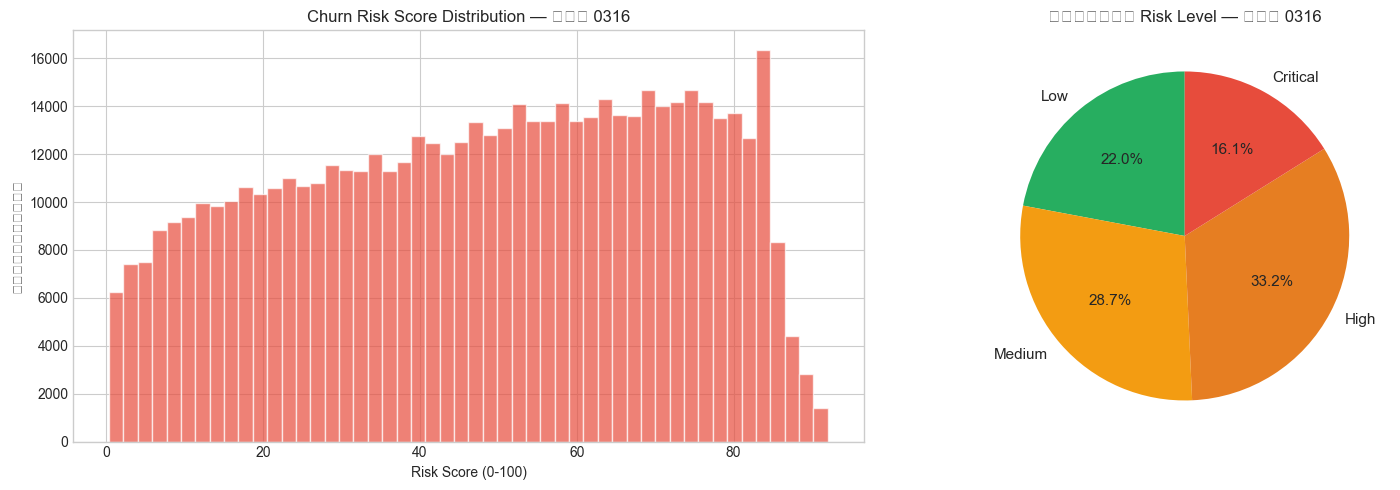


Top 20 ลูกค้าเสี่ยงสูงสุด:
   userNo  churn_score_rf_multi risk_level  tenure_rounds  purchase_freq  active_last_3  items_last_3
P13051561                  92.0   Critical              8          0.250              1           1.0
P13053922                  92.0   Critical              8          0.250              1           1.0
P13040913                  92.0   Critical              8          0.250              1           1.0
P13028299                  92.0   Critical              8          0.250              1           1.0
P13027815                  92.0   Critical              8          0.250              1           1.0
P13009227                  92.0   Critical              8          0.250              1           1.0
P13021895                  92.0   Critical              8          0.250              1           1.0
 P7440226                  92.0   Critical             57          0.035              1           1.0
P12993506                  91.9   Critical            

In [27]:
# === Score with Multi-Period Random Forest (best model) ===
# Use both models for comparison
_, rf_multi = models_multi['Random Forest']
_, lgb_single = models[best_name]

probs_rf = rf_multi.predict_proba(X_pred)[:, 1]
probs_lgb = lgb_single.predict_proba(X_pred)[:, 1]

# Build output DataFrame
output_pred = pd.DataFrame({
    'userNo': df_pred_elig['userNo'].values,
    'churn_score_rf_multi': (probs_rf * 100).round(1),
    'churn_score_lgb_single': (probs_lgb * 100).round(1),
    'risk_level': pd.cut(probs_rf * 100, bins=[-1, 25, 50, 75, 100],
                         labels=['Low', 'Medium', 'High', 'Critical']),
    'tenure_rounds': feats_pred['tenure_rounds'].values,
    'purchase_freq': feats_pred['purchase_frequency_ratio'].values.round(3),
    'active_last_3': feats_pred['active_last_3'].values.astype(int),
    'active_last_6': feats_pred['active_last_6'].values.astype(int),
    'items_last_3': feats_pred['items_last_3'].values,
    'trend_slope': feats_pred['trend_slope'].values.round(4),
    'recommended_action': pd.cut(probs_rf * 100, bins=[-1, 25, 50, 75, 100],
                                  labels=[
                                      'ไม่ต้องดำเนินการ — ลูกค้าภักดี',
                                      'ส่ง offer เบาๆ — รักษาความสัมพันธ์',
                                      'เร่งส่ง promotion — เริ่มมีสัญญาณ Churn',
                                      'ติดต่อทันที — โอกาส Churn สูงมาก'
                                  ])
})

# Summary
print(f"Scored {len(output_pred):,} customers for round 0316\n")
print("Risk Level Distribution:")
risk_summary = output_pred.groupby('risk_level', observed=True).agg(
    count=('userNo', 'size'),
    avg_score=('churn_score_rf_multi', 'mean')
)
risk_summary['pct'] = (risk_summary['count'] / len(output_pred) * 100).round(1)
print(risk_summary.to_string(float_format='{:.1f}'.format))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Score distribution
axes[0].hist(output_pred['churn_score_rf_multi'], bins=50, color='#e74c3c', alpha=0.7, edgecolor='white')
axes[0].set_title('Churn Risk Score Distribution — งวด 0316', fontsize=12)
axes[0].set_xlabel('Risk Score (0-100)')
axes[0].set_ylabel('จำนวนลูกค้า')

# Risk level pie
colors_pie = ['#27AE60', '#F39C12', '#E67E22', '#E74C3C']
risk_counts = output_pred['risk_level'].value_counts().sort_index()
axes[1].pie(risk_counts, labels=risk_counts.index, colors=colors_pie,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[1].set_title('สัดส่วน Risk Level — งวด 0316', fontsize=12)

plt.tight_layout()
plt.show()

# Top 20 highest risk
print(f"\nTop 20 ลูกค้าเสี่ยงสูงสุด:")
print(output_pred.nlargest(20, 'churn_score_rf_multi')[
    ['userNo', 'churn_score_rf_multi', 'risk_level', 'tenure_rounds', 'purchase_freq', 'active_last_3', 'items_last_3']
].to_string(index=False))

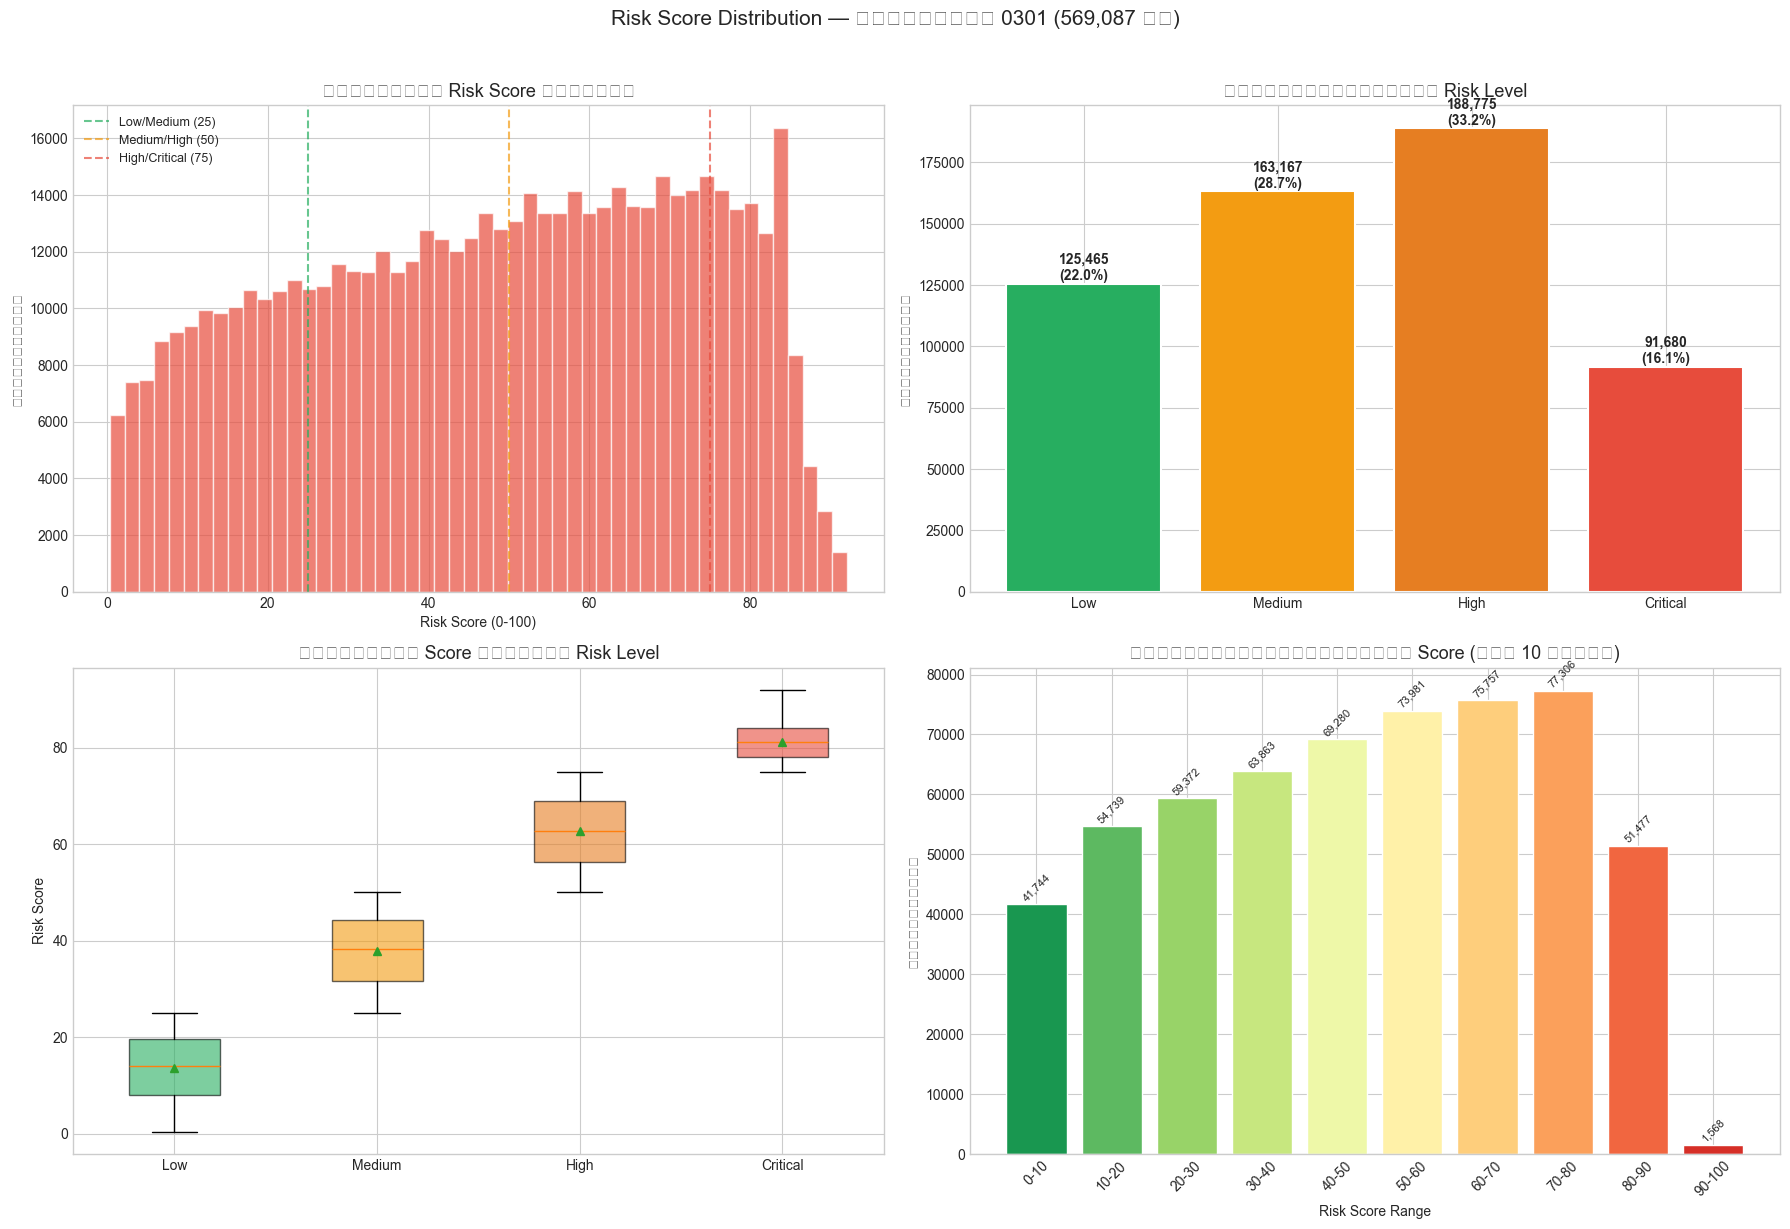


สรุปจำนวนลูกค้าแต่ละ Risk Level:
  Risk Level |      จำนวน |  สัดส่วน |  Avg Score |                                   Action
-----------------------------------------------------------------------------------------------
         Low |    125,465 |    22.0% |      13.7 | ปลอดภัย
      Medium |    163,167 |    28.7% |      37.9 | เฝ้าระวัง
        High |    188,775 |    33.2% |      62.6 | เร่งดูแล
    Critical |     91,680 |    16.1% |      81.2 | ดำเนินการทันที


In [28]:
# === Risk Score Distribution — ลูกค้าที่ซื้องวด 0301 ===
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Histogram — Score distribution
axes[0,0].hist(output_pred['churn_score_rf_multi'], bins=50, color='#e74c3c', alpha=0.7, edgecolor='white')
axes[0,0].set_title('การกระจาย Risk Score ทั้งหมด', fontsize=13)
axes[0,0].set_xlabel('Risk Score (0-100)')
axes[0,0].set_ylabel('จำนวนลูกค้า')
axes[0,0].axvline(25, color='#27AE60', linestyle='--', alpha=0.7, label='Low/Medium (25)')
axes[0,0].axvline(50, color='#F39C12', linestyle='--', alpha=0.7, label='Medium/High (50)')
axes[0,0].axvline(75, color='#E74C3C', linestyle='--', alpha=0.7, label='High/Critical (75)')
axes[0,0].legend(fontsize=9)

# 2. Bar chart — จำนวนลูกค้าต่อ Risk Level
risk_counts = output_pred['risk_level'].value_counts().sort_index()
colors_bar = ['#27AE60', '#F39C12', '#E67E22', '#E74C3C']
bars = axes[0,1].bar(risk_counts.index, risk_counts.values, color=colors_bar, edgecolor='white', linewidth=1.5)
for bar, cnt in zip(bars, risk_counts.values):
    pct = cnt / len(output_pred) * 100
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
                   f'{cnt:,}\n({pct:.1f}%)', ha='center', fontsize=10, fontweight='bold')
axes[0,1].set_title('จำนวนลูกค้าแต่ละ Risk Level', fontsize=13)
axes[0,1].set_ylabel('จำนวนลูกค้า')

# 3. Box plot — Score distribution per Risk Level
data_by_level = [output_pred[output_pred['risk_level']==lvl]['churn_score_rf_multi'].values 
                 for lvl in ['Low', 'Medium', 'High', 'Critical']]
bp = axes[1,0].boxplot(data_by_level, labels=['Low', 'Medium', 'High', 'Critical'],
                       patch_artist=True, showmeans=True)
for patch, color in zip(bp['boxes'], colors_bar):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1,0].set_title('การกระจาย Score ในแต่ละ Risk Level', fontsize=13)
axes[1,0].set_ylabel('Risk Score')

# 4. Stacked bar — Score bins (0-10, 10-20, ..., 90-100)
bins_10 = list(range(0, 101, 10))
labels_10 = [f'{lo}-{hi}' for lo, hi in zip(bins_10[:-1], bins_10[1:])]
score_bins = pd.cut(output_pred['churn_score_rf_multi'], bins=bins_10, labels=labels_10, right=True)
bin_counts = score_bins.value_counts().sort_index()
bar_colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(bin_counts)))
bars2 = axes[1,1].bar(bin_counts.index, bin_counts.values, color=bar_colors, edgecolor='white')
for bar, cnt in zip(bars2, bin_counts.values):
    if cnt > 0:
        axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                       f'{cnt:,}', ha='center', fontsize=8, rotation=45)
axes[1,1].set_title('จำนวนลูกค้าแยกตามช่วง Score (ทุก 10 คะแนน)', fontsize=13)
axes[1,1].set_xlabel('Risk Score Range')
axes[1,1].set_ylabel('จำนวนลูกค้า')
axes[1,1].tick_params(axis='x', rotation=45)

plt.suptitle(f'Risk Score Distribution — ลูกค้างวด 0301 ({len(output_pred):,} คน)', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('charts/risk_scoring_dist.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print(f"\nสรุปจำนวนลูกค้าแต่ละ Risk Level:")
print(f"{'Risk Level':>12s} | {'จำนวน':>10s} | {'สัดส่วน':>8s} | {'Avg Score':>10s} | {'Action':>40s}")
print("-" * 95)
for lvl, color_name in [('Low','ปลอดภัย'), ('Medium','เฝ้าระวัง'), ('High','เร่งดูแล'), ('Critical','ดำเนินการทันที')]:
    subset = output_pred[output_pred['risk_level'] == lvl]
    cnt = len(subset)
    pct = cnt / len(output_pred) * 100
    avg = subset['churn_score_rf_multi'].mean()
    print(f"{lvl:>12s} | {cnt:>10,} | {pct:>7.1f}% | {avg:>9.1f} | {color_name}")

In [29]:
# === Export to CSV — ไฟล์เดียวรวมทุกคน ===
export_filename = 'Churn_RiskScore_2026_0316.csv'

# New customers — mark as "New Customer" with score = -1
new_cust_df = pd.DataFrame({
    'userNo': df_pred_new['userNo'].values,
    'churn_score_rf_multi': -1,
    'churn_score_lgb_single': -1,
    'risk_level': 'New Customer',
    'tenure_rounds': 0,
    'purchase_freq': 0,
    'active_last_3': 0,
    'active_last_6': 0,
    'items_last_3': 0,
    'trend_slope': 0,
    'recommended_action': 'ลูกค้าใหม่ — ข้อมูลไม่เพียงพอ ติดตามพฤติกรรม 2-3 งวดก่อน'
})

# Combine
full_output = pd.concat([output_pred, new_cust_df], ignore_index=True)
full_output.to_csv(export_filename, index=False, encoding='utf-8-sig')

print(f"Exported: {export_filename}")
print(f"  Total: {len(full_output):,} ลูกค้า")
print(f"    - Scored:       {len(output_pred):,} (มี Risk Score)")
print(f"    - New Customer: {len(new_cust_df):,} (score = -1)")
print(f"\nColumns:")
for col in full_output.columns:
    print(f"  - {col}")
print(f"\nหมายเหตุ: score = -1 หมายถึงลูกค้าใหม่ที่ยังทำนายไม่ได้")

Exported: Churn_RiskScore_2026_0316.csv
  Total: 594,368 ลูกค้า
    - Scored:       569,087 (มี Risk Score)
    - New Customer: 25,281 (score = -1)

Columns:
  - userNo
  - churn_score_rf_multi
  - churn_score_lgb_single
  - risk_level
  - tenure_rounds
  - purchase_freq
  - active_last_3
  - active_last_6
  - items_last_3
  - trend_slope
  - recommended_action

หมายเหตุ: score = -1 หมายถึงลูกค้าใหม่ที่ยังทำนายไม่ได้


## Phase 9: Customer Segmentation — ArrayPurchase Pattern ทุก Period
Cluster ลูกค้าจาก **ทั้ง 5 ไฟล์ training + 1 ไฟล์ prediction** ด้วย binary purchase array  
แต่ละไฟล์คือลูกค้า**ที่ซื้องวดหนึ่ง** แล้วดูว่า**ซื้อต่องวดถัดไปหรือไม่**  

| File | ลูกค้าซื้องวด | ดูว่าซื้อต่องวด | มี label? |
|---|---|---|---|
| Churn_2025_1216_0102.csv | 1216 | 0102 | ✅ มี |
| Churn_2026_0102_0117.csv | 0102 | 0117 | ✅ มี |
| Churn_2026_0117_0201.csv | 0117 | 0201 | ✅ มี |
| Churn_2026_0201_0216.csv | 0201 | 0216 | ✅ มี |
| Churn_2026_0216_0301.csv | 0216 | 0301 | ✅ มี |
| Churn_Pred_2026_0316.csv | 0301 | 0316 | ❌ ไม่มี (predict) |

In [30]:
%%time
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler as SS2

# === Process ALL 6 files — build ArrayPurchase for each ===
all_files = [
    ('Churn_2025_1216_0102.csv',  'ซื้องวด 1216 → ดู 0102', True),
    ('Churn_2026_0102_0117.csv',  'ซื้องวด 0102 → ดู 0117', True),
    ('Churn_2026_0117_0201.csv',  'ซื้องวด 0117 → ดู 0201', True),
    ('Churn_2026_0201_0216.csv',  'ซื้องวด 0201 → ดู 0216', True),
    ('Churn_2026_0216_0301.csv',  'ซื้องวด 0216 → ดู 0301', True),
    ('Churn_Pred_2026_0316.csv',  'ซื้องวด 0301 → ทำนาย 0316', False),
]

period_data = {}

for fname, desc, has_label in all_files:
    print(f"\n{'='*70}")
    print(f"Loading {fname} — {desc}")
    df = pd.read_csv(fname, low_memory=False)
    item_cols = [c for c in df.columns if c.startswith('item')]
    
    # Binary purchase array
    mat = df[item_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
    binary = (mat > 0).astype(int)
    
    # Use last 30 rounds for clustering (common window for comparison)
    n_use = min(30, binary.shape[1])
    binary_last = binary.iloc[:, -n_use:]
    
    # Key features from binary array
    freq = binary_last.mean(axis=1)  # purchase frequency in window
    last_6 = binary.iloc[:, -6:].sum(axis=1)
    last_3 = binary.iloc[:, -3:].sum(axis=1)
    trend = binary.iloc[:, -15:].apply(lambda row: np.polyfit(range(min(15, len(row))), row, 1)[0] if len(row) >= 2 else 0, axis=1)
    
    period_data[fname] = {
        'df': df,
        'desc': desc,
        'has_label': has_label,
        'binary_last': binary_last.values,
        'binary_full': binary.values,
        'item_cols': item_cols,
        'n_customers': len(df),
        'n_rounds': len(item_cols),
        'freq': freq.values,
        'last_6': last_6.values,
        'last_3': last_3.values,
        'trend': trend.values,
        'label': df['label_continue'].values if has_label else None,
    }
    
    print(f"  Customers: {len(df):,} | Rounds: {len(item_cols)} | Window: last {n_use}")
    if has_label:
        churn_rate = 1 - df['label_continue'].mean()
        print(f"  Churn rate: {churn_rate:.1%}")

print(f"\n{'='*70}")
print(f"Total customers across all files: {sum(v['n_customers'] for v in period_data.values()):,}")


Loading Churn_2025_1216_0102.csv — ซื้องวด 1216 → ดู 0102


  Customers: 590,644 | Rounds: 61 | Window: last 30
  Churn rate: 49.0%

Loading Churn_2026_0102_0117.csv — ซื้องวด 0102 → ดู 0117


  Customers: 557,461 | Rounds: 62 | Window: last 30
  Churn rate: 43.4%

Loading Churn_2026_0117_0201.csv — ซื้องวด 0117 → ดู 0201


  Customers: 631,970 | Rounds: 63 | Window: last 30
  Churn rate: 43.5%

Loading Churn_2026_0201_0216.csv — ซื้องวด 0201 → ดู 0216


  Customers: 633,479 | Rounds: 64 | Window: last 30
  Churn rate: 42.0%

Loading Churn_2026_0216_0301.csv — ซื้องวด 0216 → ดู 0301


  Customers: 655,296 | Rounds: 65 | Window: last 30
  Churn rate: 45.2%

Loading Churn_Pred_2026_0316.csv — ซื้องวด 0301 → ทำนาย 0316


  Customers: 594,368 | Rounds: 65 | Window: last 30

Total customers across all files: 3,663,218
CPU times: user 5min 2s, sys: 24.3 s, total: 5min 27s
Wall time: 8min 46s


Combined dataset: 3,663,218 customers x 34 features (30 binary + 4 agg)


  K=4: inertia=869,267


  K=5: inertia=833,571


  K=6: inertia=811,146


  K=7: inertia=791,609


  K=8: inertia=777,083


  K=9: inertia=764,366


  K=10: inertia=752,886


  K=11: inertia=742,612


  K=12: inertia=734,148


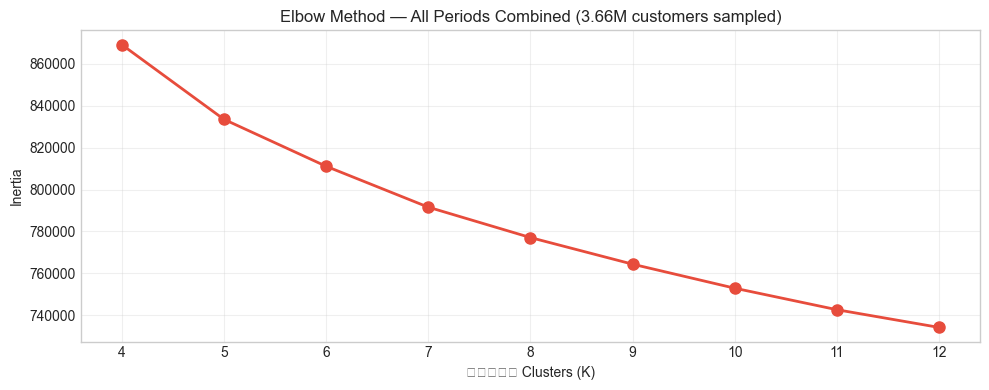

CPU times: user 1min 41s, sys: 19.2 s, total: 2min 1s
Wall time: 1min 50s


In [31]:
%%time
# === Combine all customers for unified clustering ===
# Stack last-30-round binary arrays + freq/last_6/trend features
all_binary = []
all_meta = []  # (file, index, label)

for fname, pdata in period_data.items():
    n = pdata['n_customers']
    X_bin = pdata['binary_last']  # (n, 30)
    X_feat = np.column_stack([pdata['freq'], pdata['last_6'], pdata['last_3'], pdata['trend']])
    
    # Scale features to 0-1 range (same as binary)
    from sklearn.preprocessing import MinMaxScaler
    scaler_mm = MinMaxScaler()
    X_feat_scaled = scaler_mm.fit_transform(X_feat)
    
    X_combined = np.hstack([X_bin, X_feat_scaled])
    all_binary.append(X_combined)
    
    for i in range(n):
        lbl = pdata['label'][i] if pdata['label'] is not None else -1
        all_meta.append((fname, i, lbl))

X_all = np.vstack(all_binary)
print(f"Combined dataset: {X_all.shape[0]:,} customers x {X_all.shape[1]} features (30 binary + 4 agg)")

# === Elbow Method on sampled data ===
np.random.seed(42)
sample_size = min(200000, X_all.shape[0])
sample_idx = np.random.choice(X_all.shape[0], sample_size, replace=False)
X_sample = X_all[sample_idx]

inertias = []
K_range = range(4, 13)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=200)
    km.fit(X_sample)
    inertias.append(km.inertia_)
    print(f"  K={k}: inertia={km.inertia_:,.0f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(list(K_range), inertias, 'o-', color='#e74c3c', linewidth=2, markersize=8)
ax.set_title('Elbow Method — All Periods Combined (3.66M customers sampled)', fontsize=12)
ax.set_xlabel('จำนวน Clusters (K)')
ax.set_ylabel('Inertia')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
%%time
# === Run KMeans K=8 — train on sample, predict all ===
CHOSEN_K = 8
km_final = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10, max_iter=300)
km_final.fit(X_sample)
all_labels = km_final.predict(X_all)

print(f"Clustered {X_all.shape[0]:,} customers into {CHOSEN_K} groups")

# === Build results DataFrame ===
meta_df = pd.DataFrame(all_meta, columns=['file', 'idx', 'label_continue'])
meta_df['cluster'] = all_labels
meta_df['churn'] = meta_df['label_continue'].apply(lambda x: 1 - x if x >= 0 else np.nan)

# Add binary pattern info
meta_df['freq_30'] = X_all[:, -4]  # scaled freq
meta_df['last_6'] = X_all[:, -3]

# === Cluster analysis — overall ===
print(f"\n{'='*100}")
print(f"Cluster Overview — {CHOSEN_K} Clusters across ALL {len(period_data)} files ({X_all.shape[0]:,} customers)")
print(f"{'='*100}")

cluster_info = []
for c in range(CHOSEN_K):
    mask = meta_df['cluster'] == c
    subset = meta_df[mask]
    
    # Get avg binary pattern from X_all
    avg_pattern = X_all[mask.values, :30].mean(axis=0)
    
    # Churn rate (only for labeled data)
    labeled = subset[subset['label_continue'] >= 0]
    churn_rate = labeled['churn'].mean() if len(labeled) > 0 else np.nan
    
    info = {
        'Cluster': c,
        'Count': mask.sum(),
        'Pct': mask.mean() * 100,
        'Churn_Rate': churn_rate,
        'Avg_Freq': X_all[mask.values, -4].mean(),
        'Avg_Last6': X_all[mask.values, -3].mean(),
        'Avg_Trend': X_all[mask.values, -1].mean(),
        'Avg_Pattern': avg_pattern,
    }
    cluster_info.append(info)

# Sort by churn rate
cluster_info.sort(key=lambda x: x['Churn_Rate'] if not np.isnan(x['Churn_Rate']) else 999)

print(f"\n{'Cluster':>8} {'Count':>10} {'%':>6} {'Churn%':>8} {'Freq':>6} {'Pattern (last 30 rounds)':>50}")
print(f"{'-'*100}")
for ci in cluster_info:
    pattern_str = ''.join(['█' if v > 0.5 else '▓' if v > 0.3 else '░' for v in ci['Avg_Pattern']])
    churn_str = f"{ci['Churn_Rate']:.1%}" if not np.isnan(ci['Churn_Rate']) else 'N/A'
    print(f"  C{ci['Cluster']:>3}   {ci['Count']:>10,}  {ci['Pct']:>5.1f}%  {churn_str:>7}  {ci['Avg_Freq']:>.2f}   {pattern_str}")

# === Auto-label ===
cluster_labels = {}
for ci in cluster_info:
    c = ci['Cluster']
    churn = ci['Churn_Rate']
    freq = ci['Avg_Freq']
    pattern = ci['Avg_Pattern']
    early_active = pattern[:10].mean()
    late_active = pattern[-10:].mean()
    mid_active = pattern[10:20].mean()
    
    if late_active > 0.7 and early_active > 0.5:
        label = "ภักดีตลอด — ซื้อต่อเนื่อง"
    elif late_active > 0.7 and early_active < 0.3:
        label = "ลูกค้าใหม่ภักดี — เพิ่งเริ่มซื้อแต่ติด"
    elif late_active > 0.5 and early_active < 0.2:
        label = "เพิ่งเริ่มซื้อ — ลูกค้าใหม่"
    elif early_active > 0.5 and late_active < 0.3:
        label = "เคยซื้อดี แต่หายไป"
    elif early_active > 0.3 and late_active > 0.3 and mid_active < 0.3:
        label = "ซื้อๆ หยุดๆ — ไม่สม่ำเสมอ"
    elif freq < 0.15:
        label = "แทบไม่เคยซื้อ — One-time buyer"
    elif churn > 0.6 if not np.isnan(churn) else False:
        label = "เสี่ยงสูง — Churn pattern"
    elif late_active > 0.4:
        label = "ซื้อปานกลาง — มีโอกาสรักษา"
    else:
        label = f"กลุ่มผสม (Churn={churn:.0%})" if not np.isnan(churn) else "กลุ่มผสม"
    
    cluster_labels[c] = label

meta_df['cluster_label'] = meta_df['cluster'].map(cluster_labels)

# Print with labels
print(f"\n{'='*100}")
print("Cluster Labels:")
print(f"{'='*100}")
for ci in cluster_info:
    c = ci['Cluster']
    churn_str = f"{ci['Churn_Rate']:.1%}" if not np.isnan(ci['Churn_Rate']) else 'N/A'
    print(f"  C{c}: {cluster_labels[c]}")
    print(f"    {ci['Count']:,} คน ({ci['Pct']:.1f}%) | Churn: {churn_str}")

Clustered 3,663,218 customers into 8 groups



Cluster Overview — 8 Clusters across ALL 6 files (3,663,218 customers)



 Cluster      Count      %   Churn%   Freq                           Pattern (last 30 rounds)
----------------------------------------------------------------------------------------------------
  C  6      776,043   21.2%     8.8%  0.93   ██████████████████████████████
  C  4      358,568    9.8%    21.2%  0.66   ░░░░░▓▓███████████████████████
  C  1      324,041    8.8%    26.4%  0.42   ░░░░░░░░░░░░░░▓▓██████████████
  C  7      398,013   10.9%    31.1%  0.18   ░░░░░░░░░░░░░░░░░░░░░░░▓▓█████
  C  0      341,478    9.3%    55.5%  0.45   ██████████▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓██
  C  5      386,604   10.6%    58.4%  0.71   █████████████████████████▓▓▓██
  C  2      346,564    9.5%    77.7%  0.34   ░░░░░░░░░░▓▓▓▓███████▓▓▓▓░░░█▓
  C  3      731,907   20.0%    80.8%  0.08   ░░░░░░░░░░░░░░░░░░░░░░░░░░░░█▓

Cluster Labels:
  C6: ภักดีตลอด — ซื้อต่อเนื่อง
    776,043 คน (21.2%) | Churn: 8.8%
  C4: ซื้อปานกลาง — มีโอกาสรักษา
    358,568 คน (9.8%) | Churn: 21.2%
  C1: ลูกค้าใหม่ภักดี — เพิ่งเริ่มซื้อแต

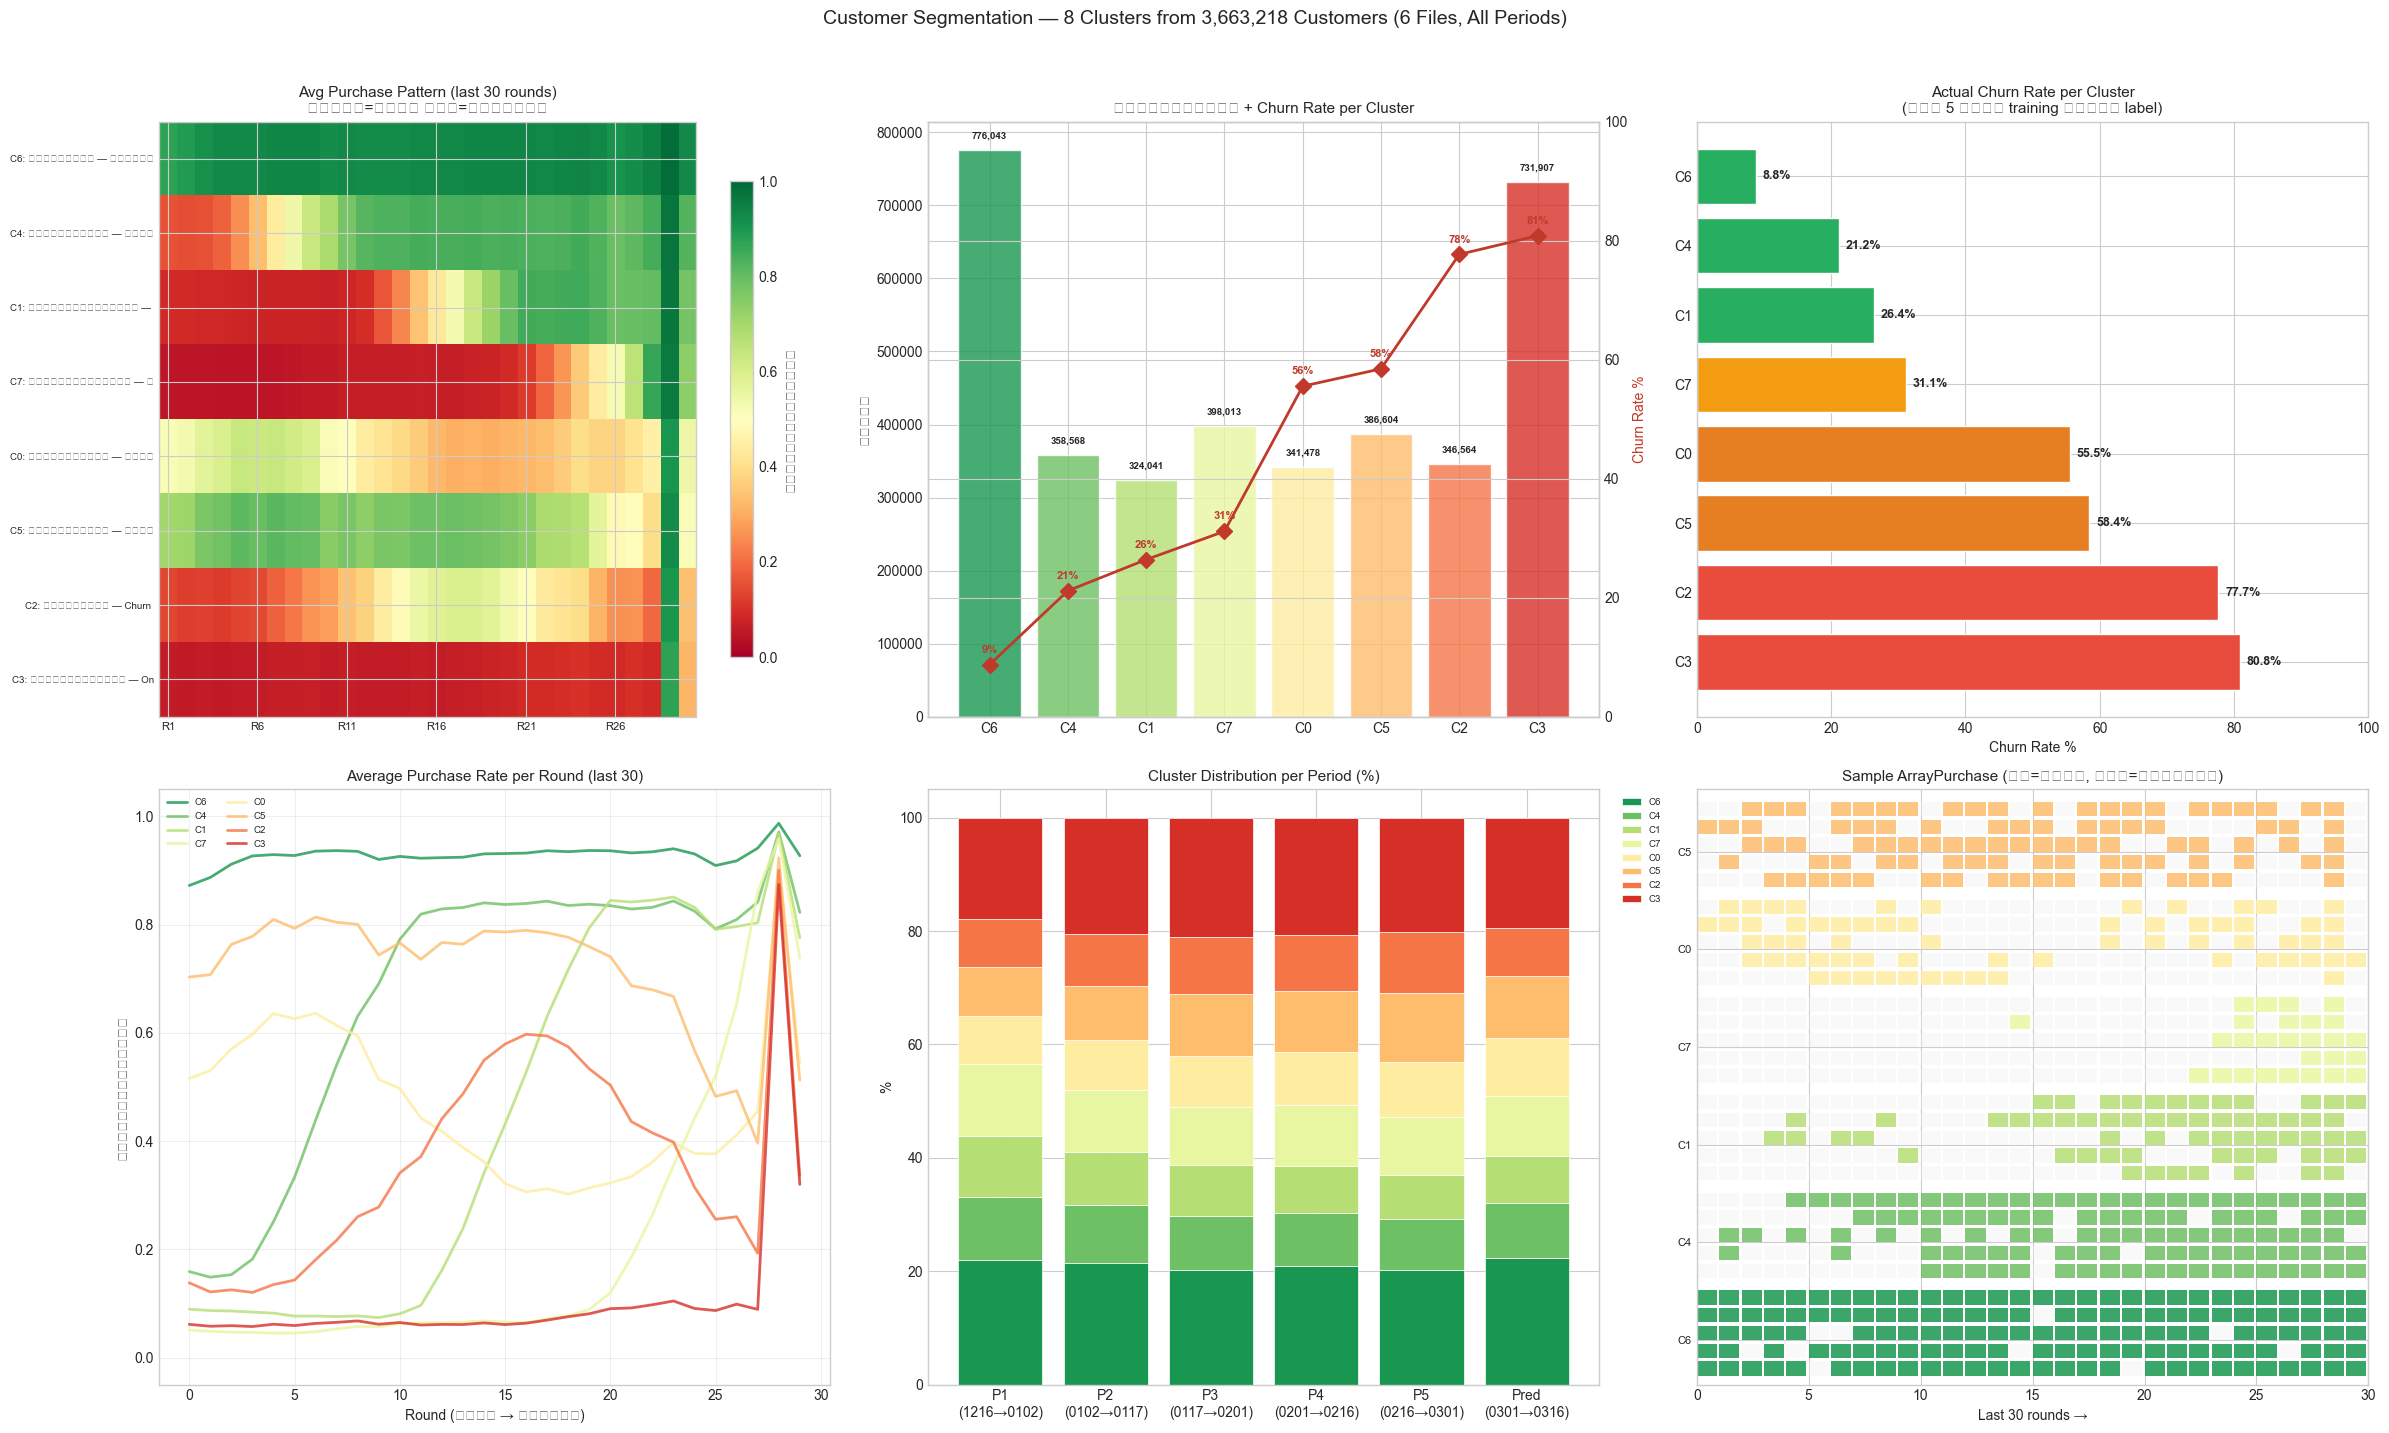

In [33]:
# === Visualization 1: Cluster Overview (8 clusters) ===
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
sorted_ci = cluster_info  # already sorted by churn rate

colors_cl = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, CHOSEN_K))  # red=high churn, green=low
cl_names = [f"C{ci['Cluster']}" for ci in sorted_ci]

# 1. Heatmap — Average ArrayPurchase per cluster
ax = axes[0,0]
pattern_matrix = np.array([ci['Avg_Pattern'] for ci in sorted_ci])
im = ax.imshow(pattern_matrix, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_yticks(range(CHOSEN_K))
ax.set_yticklabels([f"C{ci['Cluster']}: {cluster_labels[ci['Cluster']][:18]}" for ci in sorted_ci], fontsize=7)
ax.set_xticks(range(0, 30, 5))
ax.set_xticklabels([f'R{i+1}' for i in range(0, 30, 5)], fontsize=8)
ax.set_title('Avg Purchase Pattern (last 30 rounds)\nเขียว=ซื้อ แดง=ไม่ซื้อ', fontsize=11)
plt.colorbar(im, ax=ax, label='สัดส่วนที่ซื้อ', shrink=0.8)

# 2. Cluster size bar + churn rate overlay
ax = axes[0,1]
ax2 = ax.twinx()
counts = [ci['Count'] for ci in sorted_ci]
churns = [ci['Churn_Rate']*100 if not np.isnan(ci['Churn_Rate']) else 0 for ci in sorted_ci]
bars = ax.bar(cl_names, counts, color=colors_cl, edgecolor='white', alpha=0.8)
ax2.plot(cl_names, churns, 'D-', color='#C0392B', linewidth=2, markersize=8, zorder=5)
for i, (cnt, ch) in enumerate(zip(counts, churns)):
    ax.text(i, cnt + max(counts)*0.02, f'{cnt:,.0f}', ha='center', fontsize=7, fontweight='bold')
    ax2.text(i, ch + 2, f'{ch:.0f}%', ha='center', fontsize=8, color='#C0392B', fontweight='bold')
ax.set_title('จำนวนลูกค้า + Churn Rate per Cluster', fontsize=11)
ax.set_ylabel('จำนวน')
ax2.set_ylabel('Churn Rate %', color='#C0392B')
ax2.set_ylim(0, 100)

# 3. Churn rate bar chart (clear view)
ax = axes[0,2]
churn_colors = ['#27AE60' if c < 30 else '#F39C12' if c < 50 else '#E67E22' if c < 70 else '#E74C3C' for c in churns]
bars = ax.barh(cl_names, churns, color=churn_colors, edgecolor='white')
for bar, ch in zip(bars, churns):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{ch:.1f}%', va='center', fontsize=9, fontweight='bold')
ax.set_title('Actual Churn Rate per Cluster\n(จาก 5 ไฟล์ training ที่มี label)', fontsize=11)
ax.set_xlabel('Churn Rate %')
ax.set_xlim(0, 100)
ax.invert_yaxis()

# 4. Purchase pattern line chart (last 30 rounds)
ax = axes[1,0]
for i, ci in enumerate(sorted_ci):
    ax.plot(range(30), ci['Avg_Pattern'], '-', color=colors_cl[i],
            label=f"C{ci['Cluster']}", linewidth=2, alpha=0.8)
ax.set_title('Average Purchase Rate per Round (last 30)', fontsize=11)
ax.set_xlabel('Round (เก่า → ล่าสุด)')
ax.set_ylabel('สัดส่วนที่ซื้อ')
ax.legend(fontsize=7, ncol=2)
ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.3)

# 5. Cluster composition per file
ax = axes[1,1]
file_short = {
    'Churn_2025_1216_0102.csv': 'P1\n(1216→0102)',
    'Churn_2026_0102_0117.csv': 'P2\n(0102→0117)',
    'Churn_2026_0117_0201.csv': 'P3\n(0117→0201)',
    'Churn_2026_0201_0216.csv': 'P4\n(0201→0216)',
    'Churn_2026_0216_0301.csv': 'P5\n(0216→0301)',
    'Churn_Pred_2026_0316.csv': 'Pred\n(0301→0316)',
}
file_names = list(file_short.values())
bottom = np.zeros(len(file_short))
for i, ci in enumerate(sorted_ci):
    vals = []
    for fname in file_short.keys():
        file_mask = (meta_df['file'] == fname) & (meta_df['cluster'] == ci['Cluster'])
        file_total = (meta_df['file'] == fname).sum()
        vals.append(file_mask.sum() / file_total * 100)
    ax.bar(file_names, vals, bottom=bottom, color=colors_cl[i], 
           label=f"C{ci['Cluster']}", edgecolor='white', linewidth=0.5)
    bottom += vals
ax.set_title('Cluster Distribution per Period (%)', fontsize=11)
ax.set_ylabel('%')
ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc='upper left')

# 6. Sample ArrayPurchase visual
ax = axes[1,2]
n_last = 30
y_pos = 0
yticks = []
ytick_labels = []
for i, ci in enumerate(sorted_ci[:6]):  # top 6 for readability
    c = ci['Cluster']
    mask_idx = (meta_df['cluster'] == c).values
    binary_sub = X_all[mask_idx, :30]
    np.random.seed(c)
    sidx = np.random.choice(binary_sub.shape[0], min(5, binary_sub.shape[0]), replace=False)
    for j, idx in enumerate(sidx):
        arr = binary_sub[idx]
        for r in range(n_last):
            color = colors_cl[i] if arr[r] > 0.5 else '#f0f0f0'
            alpha = 0.85 if arr[r] > 0.5 else 0.4
            ax.add_patch(plt.Rectangle((r, y_pos), 0.9, 0.8, facecolor=color, alpha=alpha))
        y_pos += 1
    yticks.append(y_pos - 3)
    ytick_labels.append(f'C{c}')
    y_pos += 0.5

ax.set_xlim(0, n_last)
ax.set_ylim(-0.5, y_pos)
ax.set_yticks(yticks)
ax.set_yticklabels(ytick_labels, fontsize=8)
ax.set_xlabel('Last 30 rounds →')
ax.set_title('Sample ArrayPurchase (สี=ซื้อ, เทา=ไม่ซื้อ)', fontsize=11)

plt.suptitle(f'Customer Segmentation — {CHOSEN_K} Clusters from {X_all.shape[0]:,} Customers (6 Files, All Periods)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('charts/segmentation_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
# === Visualization 2: Per-Period Detail + ArrayPurchase Samples ===

# --- Per-file breakdown table ---
print(f"{'='*120}")
print(f"Cluster Breakdown per File — Churn Rate + ArrayPurchase Pattern")
print(f"{'='*120}")

file_short_name = {
    'Churn_2025_1216_0102.csv':  'P1 (ซื้อ 1216→0102)',
    'Churn_2026_0102_0117.csv':  'P2 (ซื้อ 0102→0117)',
    'Churn_2026_0117_0201.csv':  'P3 (ซื้อ 0117→0201)',
    'Churn_2026_0201_0216.csv':  'P4 (ซื้อ 0201→0216)',
    'Churn_2026_0216_0301.csv':  'P5 (ซื้อ 0216→0301)',
    'Churn_Pred_2026_0316.csv':  'Pred (ซื้อ 0301→ทำนาย 0316)',
}

for fname in file_short_name:
    pname = file_short_name[fname]
    file_mask = meta_df['file'] == fname
    subset = meta_df[file_mask]
    n_total = len(subset)
    has_label = period_data[fname]['has_label']
    
    print(f"\n{'─'*100}")
    print(f"📁 {fname} — {pname}")
    print(f"   ลูกค้า: {n_total:,} คน | Rounds: {period_data[fname]['n_rounds']} | Label: {'มี' if has_label else 'ไม่มี (prediction)'}")
    print(f"   {'Cluster':>8} {'Count':>8} {'%':>6} {'Churn%':>8}  Pattern (avg last 30 rounds)")
    
    for ci in cluster_info:
        c = ci['Cluster']
        cmask = file_mask & (meta_df['cluster'] == c)
        count = cmask.sum()
        if count == 0:
            continue
        pct = count / n_total * 100
        
        # Churn for this file + cluster
        if has_label:
            labeled = meta_df[cmask & (meta_df['label_continue'] >= 0)]
            churn = labeled['churn'].mean() * 100 if len(labeled) > 0 else 0
            churn_str = f"{churn:.1f}%"
        else:
            churn_str = "N/A"
        
        # Pattern for this file + cluster
        pattern = X_all[cmask.values, :30].mean(axis=0)
        pattern_str = ''.join(['█' if v > 0.5 else '▓' if v > 0.3 else '░' for v in pattern])
        
        print(f"   C{c:>5}   {count:>8,}  {pct:>5.1f}%  {churn_str:>7}  {pattern_str}  {cluster_labels[c]}")

# --- ArrayPurchase samples per cluster (from prediction file) ---
print(f"\n{'='*120}")
print(f"ArrayPurchase Samples — จากไฟล์ Churn_Pred_2026_0316.csv (ลูกค้าซื้องวด 0301)")
print(f"(█=ซื้อ ░=ไม่ซื้อ — last 30 rounds)")
print(f"{'='*120}")

pred_mask = meta_df['file'] == 'Churn_Pred_2026_0316.csv'
for ci in cluster_info:
    c = ci['Cluster']
    cmask = pred_mask & (meta_df['cluster'] == c)
    count = cmask.sum()
    if count == 0:
        continue
    print(f"\n  C{c}: {cluster_labels[c]} — {count:,} คน")
    
    binary_sub = X_all[cmask.values, :30]
    np.random.seed(c + 100)
    sidx = np.random.choice(binary_sub.shape[0], min(8, binary_sub.shape[0]), replace=False)
    
    # Average pattern
    avg = binary_sub.mean(axis=0)
    print(f"    Avg: {''.join(['█' if v > 0.5 else '▓' if v > 0.3 else '░' for v in avg])}")
    for j, idx in enumerate(sidx):
        arr = binary_sub[idx]
        print(f"    #{j+1}:  {''.join(['█' if v > 0.5 else '░' for v in arr])}")

# --- Summary: Recommended campaigns per cluster ---
print(f"\n{'='*120}")
print("Recommended Campaigns per Cluster:")
print(f"{'='*120}")
campaigns = {
    "ภักดีตลอด — ซื้อต่อเนื่อง": ("Loyalty reward, referral program, exclusive early access", "#27AE60"),
    "ลูกค้าใหม่ภักดี — เพิ่งเริ่มซื้อแต่ติด": ("Welcome series, onboarding bonus, category expansion", "#2ECC71"),
    "เพิ่งเริ่มซื้อ — ลูกค้าใหม่": ("Second purchase incentive, guided recommendations", "#3498DB"),
    "เคยซื้อดี แต่หายไป": ("Win-back campaign, special comeback offer, survey", "#E67E22"),
    "ซื้อๆ หยุดๆ — ไม่สม่ำเสมอ": ("Regular reminders, subscription model, auto-reorder", "#F39C12"),
    "แทบไม่เคยซื้อ — One-time buyer": ("Low-cost re-engagement, last-chance discount", "#E74C3C"),
    "เสี่ยงสูง — Churn pattern": ("Deep discount, personal call, feedback survey", "#C0392B"),
    "ซื้อปานกลาง — มีโอกาสรักษา": ("Upsell, bundle offers, loyalty program invite", "#F39C12"),
}
for ci in cluster_info:
    c = ci['Cluster']
    label = cluster_labels[c]
    churn_str = f"{ci['Churn_Rate']:.1%}" if not np.isnan(ci['Churn_Rate']) else 'N/A'
    campaign = campaigns.get(label, ("Standard retention campaign", "#888"))[0]
    print(f"  C{c}: {label}")
    print(f"    {ci['Count']:,} คน | Churn: {churn_str}")
    print(f"    → Campaign: {campaign}")

Cluster Breakdown per File — Churn Rate + ArrayPurchase Pattern

────────────────────────────────────────────────────────────────────────────────────────────────────
📁 Churn_2025_1216_0102.csv — P1 (ซื้อ 1216→0102)
   ลูกค้า: 590,644 คน | Rounds: 61 | Label: มี
    Cluster    Count      %   Churn%  Pattern (avg last 30 rounds)


   C    6    129,829   22.0%    15.5%  ██████████████████████████████  ภักดีตลอด — ซื้อต่อเนื่อง
   C    4     66,002   11.2%    30.7%  ░░░░░▓▓███████████████████████  ซื้อปานกลาง — มีโอกาสรักษา


   C    1     63,031   10.7%    36.6%  ░░░░░░░░░░░░░░▓▓██████████████  ลูกค้าใหม่ภักดี — เพิ่งเริ่มซื้อแต่ติด
   C    7     74,827   12.7%    40.2%  ░░░░░░░░░░░░░░░░░░░░░░░▓▓█████  เพิ่งเริ่มซื้อ — ลูกค้าใหม่
   C    0     49,902    8.4%    61.1%  ███████████▓▓▓▓░▓▓▓▓▓▓▓▓▓▓▓██▓  ซื้อปานกลาง — มีโอกาสรักษา


   C    5     51,807    8.8%    70.0%  █████████████████████████████▓  ซื้อปานกลาง — มีโอกาสรักษา
   C    2     49,269    8.3%    83.1%  ░░░░░░░░░░▓▓▓▓██████▓▓▓▓▓░▓▓█░  เสี่ยงสูง — Churn pattern


   C    3    105,977   17.9%    83.2%  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░█░  แทบไม่เคยซื้อ — One-time buyer

────────────────────────────────────────────────────────────────────────────────────────────────────
📁 Churn_2026_0102_0117.csv — P2 (ซื้อ 0102→0117)
   ลูกค้า: 557,461 คน | Rounds: 62 | Label: มี
    Cluster    Count      %   Churn%  Pattern (avg last 30 rounds)


...


────────────────────────────────────────────────────────────────────────────────────────────────────
📁 Churn_Pred_2026_0316.csv — Pred (ซื้อ 0301→ทำนาย 0316)
   ลูกค้า: 594,368 คน | Rounds: 65 | Label: ไม่มี (prediction)
    Cluster    Count      %   Churn%  Pattern (avg last 30 rounds)
   C    6    132,653   22.3%      N/A  ██████████████████████████████  ภักดีตลอด — ซื้อต่อเนื่อง


   C    4     58,143    9.8%      N/A  ░░░░░▓▓███████████████████████  ซื้อปานกลาง — มีโอกาสรักษา
   C    1     48,556    8.2%      N/A  ░░░░░░░░░░░░░░▓▓██████████████  ลูกค้าใหม่ภักดี — เพิ่งเริ่มซื้อแต่ติด
   C    7     63,323   10.7%      N/A  ░░░░░░░░░░░░░░░░░░░░░░░▓▓▓████  เพิ่งเริ่มซื้อ — ลูกค้าใหม่
   C    0     61,217   10.3%      N/A  █████████▓▓▓▓▓▓▓░▓▓▓▓▓▓▓░▓▓▓▓█  ซื้อปานกลาง — มีโอกาสรักษา
   C    5     64,050   10.8%      N/A  ████████████████████████▓▓▓▓██  ซื้อปานกลาง — มีโอกาสรักษา
   C    2     50,367    8.5%      N/A  ░░░░░░░░░░▓▓▓███████▓▓▓▓░░░░▓█  เสี่ยงสูง — Churn pattern


   C    3    116,059   19.5%      N/A  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█  แทบไม่เคยซื้อ — One-time buyer

ArrayPurchase Samples — จากไฟล์ Churn_Pred_2026_0316.csv (ลูกค้าซื้องวด 0301)
(█=ซื้อ ░=ไม่ซื้อ — last 30 rounds)

  C6: ภักดีตลอด — ซื้อต่อเนื่อง — 132,653 คน
    Avg: ██████████████████████████████
    #1:  ██████████████████████████░███
    #2:  ███████████░██████░████░██████
    #3:  ░█████░░█░█░█░██████░█████████
    #4:  █████████████████████░████████
    #5:  ████████████░█████████████░███
    #6:  █░████░██░█████████████████░██
    #7:  ███████████░██████████████████
    #8:  ██████████████████████████████

  C4: ซื้อปานกลาง — มีโอกาสรักษา — 58,143 คน
    Avg: ░░░░░▓▓███████████████████████
    #1:  █░░░░░░░░░█████░█░██░░████░███
    #2:  ░░░░░░░░░░░███████████████████
    #3:  ░░░░░░░░██████████████████████
    #4:  ░░░░░░░░░░█████████████████░░█
    #5:  ███░░░██░██░░█████░█░█████████
    #6:  ░░░░░░░░██████░███░█████░█████
    #7:  ░░░░░░░░██████████░██░░██░░░██
    #8:  ░░

    Avg: ░░░░░░░░░░░░░░▓▓██████████████
    #1:  ░██░░░░░░░░░████████████████░█
    #2:  ░░░░░░░░░░░░██████████████████
    #3:  ░░░░░░░░░░░░░░████████████████
    #4:  ░░░░░░░░░░░░█░███░█░█████░█░██
    #5:  ░░░░░░░░░░░░░░░░░░█████░░█░░██
    #6:  ░░░░░░░░█░░░░░░░████░█░████░░█
    #7:  ░░░░░░░░░░░░░░░░██████░███░███
    #8:  ░░░░░░░░░░░░░███░████░░█░█░███

  C7: เพิ่งเริ่มซื้อ — ลูกค้าใหม่ — 63,323 คน
    Avg: ░░░░░░░░░░░░░░░░░░░░░░░▓▓▓████
    #1:  ░░░░░░░░░░░░░░░░░░░░░░░░██░█░█
    #2:  ░░░░░░░░░░░░░░░░░░░░░░██░█░░██
    #3:  ░░░░░░░░░░░░░░░░░░░██░█░░█████
    #4:  ░░░░░░░░░░░░░██░░░░░░░░░░░░███
    #5:  ░░░░░░░░░░░░░░░░░░░░░░░░░░░███
    #6:  ░░░░░░░░░░░░░░░░█░█░░█░░█░██░█
    #7:  ░░░░░░░░░░░░░░░░░░░░░░░███░███
    #8:  █░░░░░░░███░░░░█░░░██░░░█░████

  C0: ซื้อปานกลาง — มีโอกาสรักษา — 61,217 คน
    Avg: █████████▓▓▓▓▓▓▓░▓▓▓▓▓▓▓░▓▓▓▓█
    #1:  ░░░░███████░░█░█░█░░░░░█░░░███
    #2:  ░░███████░░░█░░░░░░█░░░█░░░█░█
    #3:  ████░██░░░░░░░░░░░░░░░░░░░░░██
    #4:  ░░█░████░█░█░░░░░█

    Avg: ████████████████████████▓▓▓▓██
    #1:  ████████░░░░░█░████░█░█░██████
    #2:  ░███████░██████░██░███░░░░████
    #3:  ██░█████████████████████░░█░██
    #4:  █░███████░░░██░████████░█░██░█
    #5:  █░███████░█████░████████░░█░░█
    #6:  █░██████░█████░░░█░██░░█░░█░░█
    #7:  ░░██████░███░█░█░█████░█░░░█░█
    #8:  ████░██░█░████████░░█████░█░██

  C2: เสี่ยงสูง — Churn pattern — 50,367 คน
    Avg: ░░░░░░░░░░▓▓▓███████▓▓▓▓░░░░▓█
    #1:  ░░░░░░░░░░░█░░█░██████░█░░░░██
    #2:  ░░░██░░░░███░░█░█░░░█░░█░░░░░█
    #3:  ░░░░░░░░░░░░░█░███░░█░█░░░░░██
    #4:  ░░░░█░█░░░░█░██░█████░░░░░░░░█
    #5:  ░█░░░░░░░█░░░░░██░░██░░░░░░░░█
    #6:  ░░░░░░░░████░██░░███░█░░░░░█░█
    #7:  ░░░░░░█░██░█████░░░█░░░░░░░░░█
    #8:  ░░░░░░░░█░████░███░█░░░░░░░░░█

  C3: แทบไม่เคยซื้อ — One-time buyer — 116,059 คน
    Avg: ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
    #1:  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██
    #2:  ░░░░░░░░░░░░░░░░░░░░░░░░░░░█░█
    #3:  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██
    #4:  ░░░░░░░░░░░░░░█

## Phase 10: Revenue at Risk Analysis — มูลค่าที่อาจสูญเสีย
วิเคราะห์ลูกค้างวด 0301 ที่มี Risk Score สูง หากปล่อยไว้ไม่ทำ campaign จะ **สูญเสียยอดซื้อ (units)** เท่าไหร่

- **Units at Risk** = จำนวนชิ้นที่ลูกค้าซื้องวดล่าสุด × ความน่าจะเป็นที่จะ churn
- แยกตาม Risk Level: Low / Medium / High / Critical
- คำนวณ scenario ถ้าทำ retention campaign ลด churn ได้ 20-50%

In [35]:
# === Phase 10: Revenue at Risk — โหลดข้อมูลและคำนวณ ===

# โหลดข้อมูลลูกค้างวด 0301 (ไฟล์ prediction ที่มีประวัติซื้อ)
pred_raw = pd.read_csv('Churn_Pred_2026_0316.csv')
risk_df = pd.read_csv('Churn_RiskScore_2026_0316.csv')

# Merge risk score กับข้อมูลดิบ
merged = pred_raw.merge(risk_df[['userNo', 'churn_score_rf_multi', 'risk_level', 
                                  'items_last_3', 'trend_slope']], on='userNo', how='inner')

# คำนวณยอดซื้องวดล่าสุด (item2026_03_01 = งวด 0301)
item_cols = [c for c in pred_raw.columns if c.startswith('item')]
last_round_col = item_cols[-1]  # งวดล่าสุด
last_3_cols = item_cols[-3:]     # 3 งวดล่าสุด

merged['units_last_round'] = merged[last_round_col]
merged['units_last_3_avg'] = merged[last_3_cols].mean(axis=1)
merged['churn_prob'] = merged['churn_score_rf_multi'] / 100

# === Units at Risk ===
# ถ้าลูกค้า churn → สูญเสียยอดซื้อเฉลี่ย 3 งวดล่าสุด
merged['units_at_risk'] = merged['units_last_3_avg'] * merged['churn_prob']

print(f"ลูกค้าทั้งหมด: {len(merged):,} คน")
print(f"งวดล่าสุดที่ใช้: {last_round_col}")
print(f"3 งวดล่าสุด: {', '.join(last_3_cols)}")
print(f"\n{'='*70}")
print(f"{'Risk Level':<12} {'จำนวน':>10} {'ยอดซื้อเฉลี่ย/งวด':>18} {'Units at Risk':>15} {'สัดส่วน':>10}")
print(f"{'='*70}")

level_order = ['Low', 'Medium', 'High', 'Critical', 'New']
total_risk = merged['units_at_risk'].sum()

summary_rows = []
for level in level_order:
    group = merged[merged['risk_level'] == level]
    if len(group) == 0:
        continue
    n = len(group)
    avg_units = group['units_last_3_avg'].mean()
    risk_units = group['units_at_risk'].sum()
    pct = risk_units / total_risk * 100
    summary_rows.append({'level': level, 'n': n, 'avg': avg_units, 'risk': risk_units, 'pct': pct})
    print(f"{level:<12} {n:>10,} {avg_units:>18,.1f} {risk_units:>15,.0f} {pct:>9.1f}%")

print(f"{'─'*70}")
print(f"{'Total':<12} {len(merged):>10,} {merged['units_last_3_avg'].mean():>18,.1f} {total_risk:>15,.0f} {'100.0':>9}%")
print(f"\n💡 หากปล่อยทุกคนไว้ไม่ทำอะไร → เสี่ยงสูญเสียรวม {total_risk:,.0f} units/งวด")

ลูกค้าทั้งหมด: 594,368 คน
งวดล่าสุดที่ใช้: item2026_03_01
3 งวดล่าสุด: item2026_02_01, item2026_02_16, item2026_03_01

Risk Level        จำนวน  ยอดซื้อเฉลี่ย/งวด   Units at Risk    สัดส่วน


Low             125,465               25.6         319,041      22.9%
Medium          163,167                8.7         514,177      36.9%


High            188,775                3.9         446,752      32.1%
Critical         91,680                1.6         114,893       8.2%
──────────────────────────────────────────────────────────────────────
Total           594,368                9.6       1,393,075     100.0%

💡 หากปล่อยทุกคนไว้ไม่ทำอะไร → เสี่ยงสูญเสียรวม 1,393,075 units/งวด


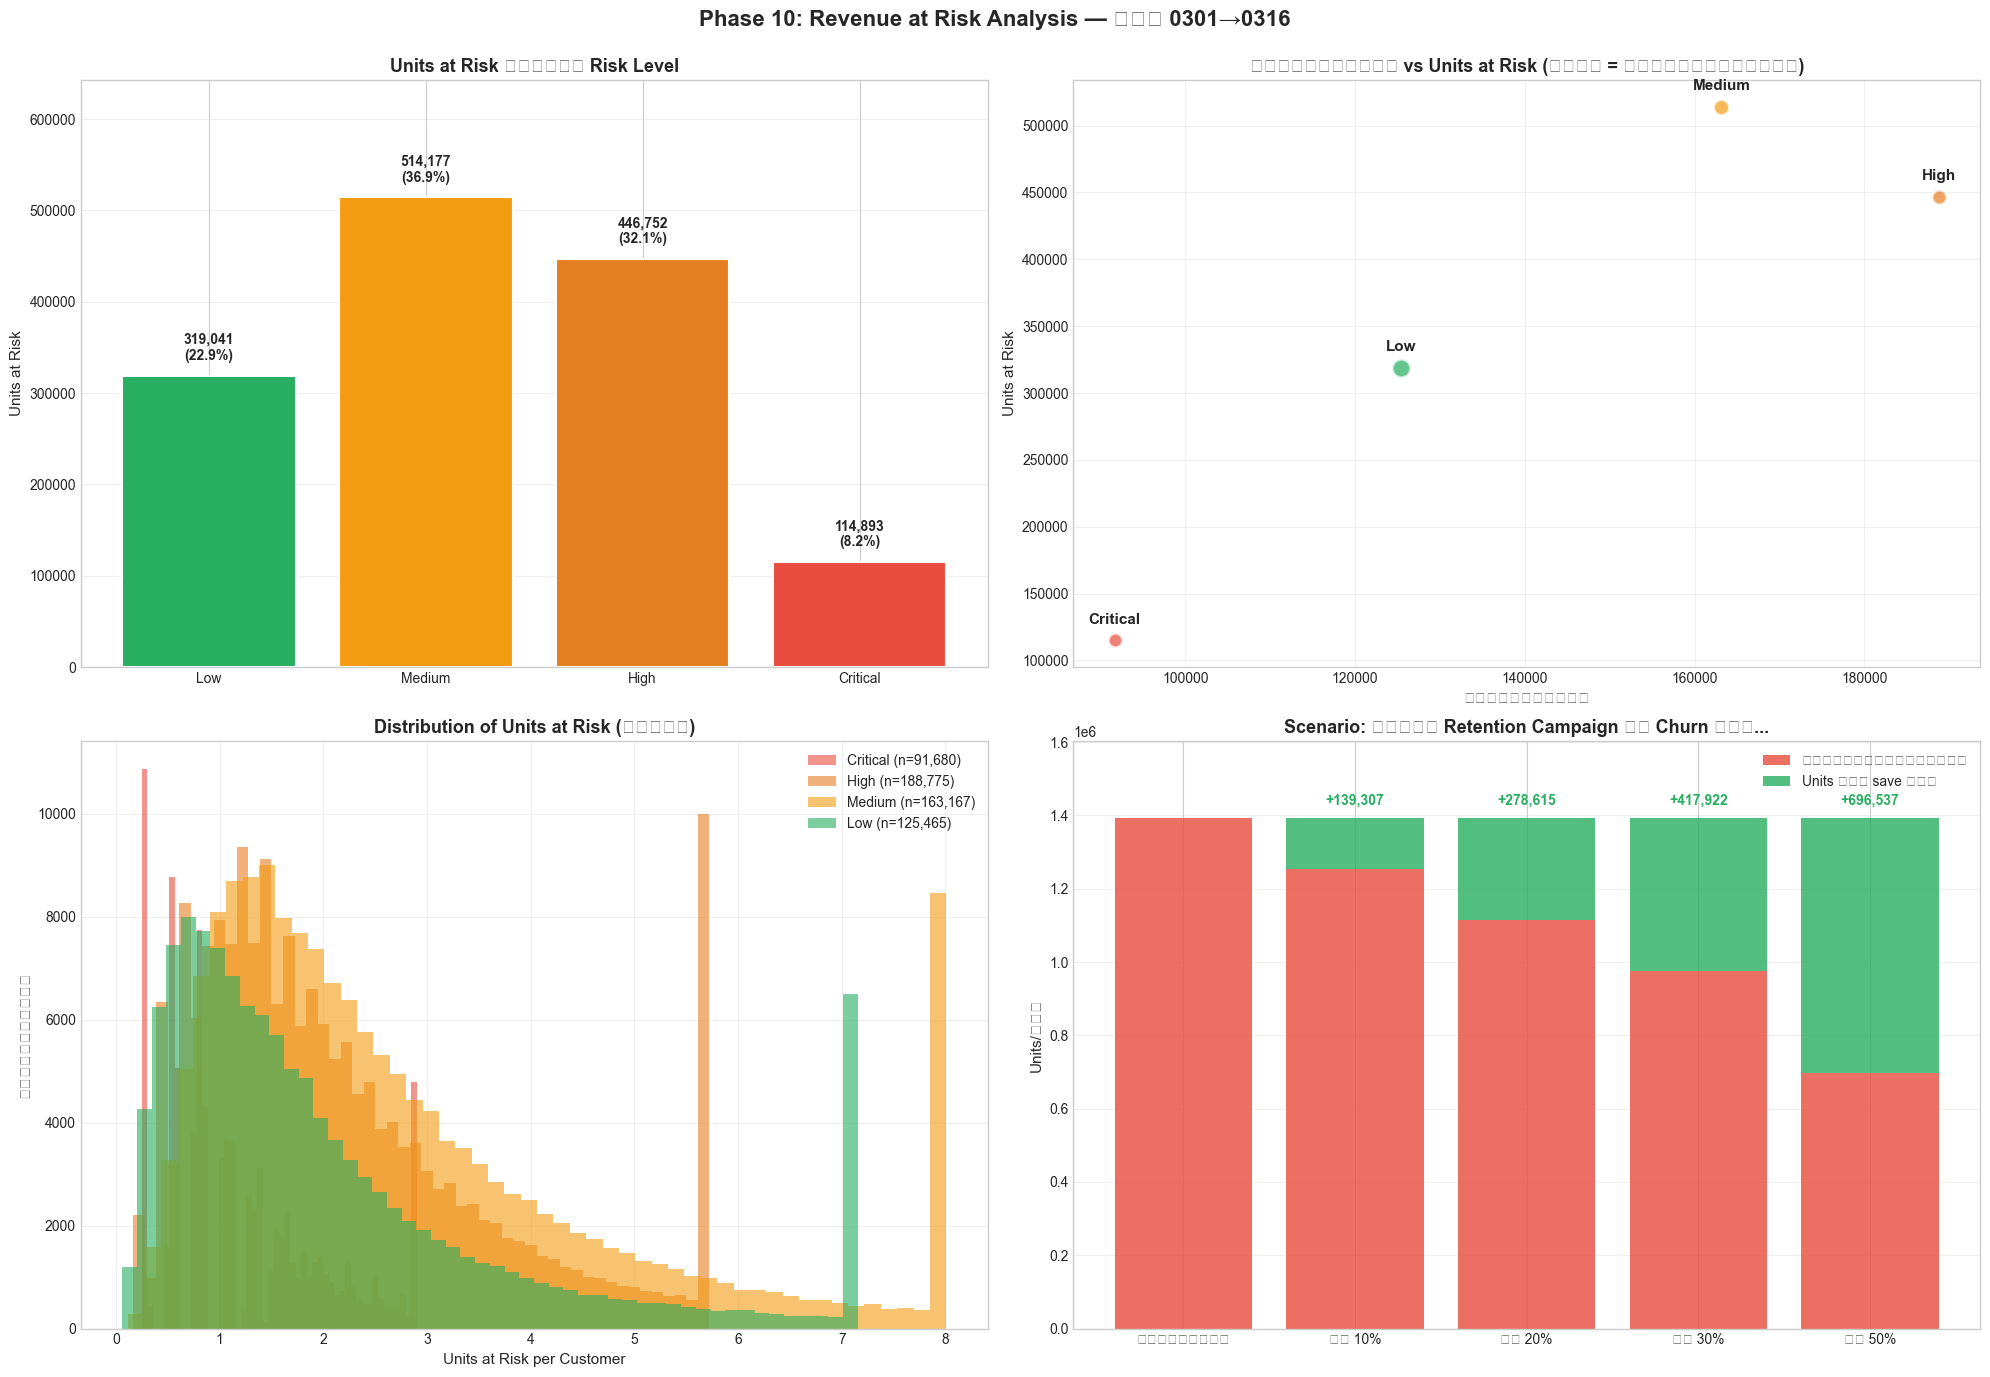

In [36]:
# === Visualization: Revenue at Risk Dashboard ===

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('Phase 10: Revenue at Risk Analysis — งวด 0301→0316', fontsize=16, fontweight='bold')

level_colors = {'Low': '#27AE60', 'Medium': '#F39C12', 'High': '#E67E22', 'Critical': '#E74C3C', 'New': '#95A5A6'}

# --- 1. Units at Risk by Risk Level (Stacked Bar) ---
ax = axes[0, 0]
summary = pd.DataFrame(summary_rows)
bars = ax.bar(summary['level'], summary['risk'], 
              color=[level_colors[l] for l in summary['level']], edgecolor='white', linewidth=1.5)
for bar, row in zip(bars, summary_rows):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total_risk*0.01,
            f"{row['risk']:,.0f}\n({row['pct']:.1f}%)", ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Units at Risk', fontsize=11)
ax.set_title('Units at Risk แยกตาม Risk Level', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(summary['risk']) * 1.25)

# --- 2. จำนวนลูกค้า vs Units at Risk (Bubble) ---
ax = axes[0, 1]
for _, row in summary.iterrows():
    ax.scatter(row['n'], row['risk'], s=row['avg']*3+100, 
              color=level_colors[row['level']], alpha=0.7, edgecolors='white', linewidth=2)
    ax.annotate(row['level'], (row['n'], row['risk']), fontsize=11, fontweight='bold',
               ha='center', va='bottom', xytext=(0, 10), textcoords='offset points')
ax.set_xlabel('จำนวนลูกค้า', fontsize=11)
ax.set_ylabel('Units at Risk', fontsize=11)
ax.set_title('จำนวนลูกค้า vs Units at Risk (ขนาด = ยอดซื้อเฉลี่ย)', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)

# --- 3. Distribution of Units at Risk per Customer ---
ax = axes[1, 0]
for level in ['Critical', 'High', 'Medium', 'Low']:
    group = merged[merged['risk_level'] == level]
    risk_vals = group['units_at_risk']
    risk_vals = risk_vals[risk_vals > 0]
    if len(risk_vals) > 0:
        ax.hist(risk_vals.clip(upper=risk_vals.quantile(0.95)), bins=50, alpha=0.6, 
                label=f"{level} (n={len(risk_vals):,})", color=level_colors[level])
ax.set_xlabel('Units at Risk per Customer', fontsize=11)
ax.set_ylabel('จำนวนลูกค้า', fontsize=11)
ax.set_title('Distribution of Units at Risk (ต่อคน)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# --- 4. Retention Campaign Scenario ---
ax = axes[1, 1]
scenarios = [0, 10, 20, 30, 50]  # % churn reduction
scenario_results = []
for reduction in scenarios:
    saved = total_risk * (reduction / 100)
    remaining = total_risk - saved
    scenario_results.append({'reduction': reduction, 'saved': saved, 'remaining': remaining})

scenario_df = pd.DataFrame(scenario_results)
bars_remain = ax.bar(range(len(scenarios)), scenario_df['remaining'], color='#E74C3C', alpha=0.8, label='ยังเสี่ยงสูญเสีย')
bars_saved = ax.bar(range(len(scenarios)), scenario_df['saved'], bottom=scenario_df['remaining'], 
                     color='#27AE60', alpha=0.8, label='Units ที่ save ได้')

for i, row in scenario_df.iterrows():
    if row['saved'] > 0:
        ax.text(i, total_risk * 1.02, f"+{row['saved']:,.0f}", ha='center', va='bottom', 
                fontsize=10, fontweight='bold', color='#27AE60')

ax.set_xticks(range(len(scenarios)))
ax.set_xticklabels([f"ลด {s}%" if s > 0 else "ไม่ทำอะไร" for s in scenarios], fontsize=10)
ax.set_ylabel('Units/งวด', fontsize=11)
ax.set_title('Scenario: ถ้าทำ Retention Campaign ลด Churn ได้...', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, total_risk * 1.15)

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.savefig('charts/revenue_at_risk.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
# === Top 20 ลูกค้าที่เสี่ยงสูญเสียมากที่สุด ===

top20 = merged.nlargest(20, 'units_at_risk')[
    ['userNo', 'risk_level', 'churn_score_rf_multi', 'units_last_round', 
     'units_last_3_avg', 'units_at_risk', 'trend_slope']
].reset_index(drop=True)
top20.index = top20.index + 1

print("🔴 Top 20 ลูกค้าที่เสี่ยงสูญเสียยอดซื้อมากที่สุด")
print("="*90)
display(top20.style.format({
    'churn_score_rf_multi': '{:.1f}',
    'units_last_round': '{:,.0f}',
    'units_last_3_avg': '{:,.1f}',
    'units_at_risk': '{:,.1f}',
    'trend_slope': '{:+.1f}'
}).bar(subset=['units_at_risk'], color='#E74C3C', vmin=0)
 .background_gradient(subset=['churn_score_rf_multi'], cmap='RdYlGn_r'))

# === สรุป Insight ===
critical_high = merged[merged['risk_level'].isin(['Critical', 'High'])]
print(f"\n{'='*70}")
print(f"📊 สรุป Revenue at Risk — งวด 0301→0316")
print(f"{'='*70}")
print(f"  ลูกค้าทั้งหมด:           {len(merged):>10,} คน")
print(f"  Units at Risk รวม:       {total_risk:>10,.0f} units/งวด")
print(f"  Critical+High:           {len(critical_high):>10,} คน ({len(critical_high)/len(merged)*100:.1f}%)")
print(f"  Units at Risk (Crit+Hi): {critical_high['units_at_risk'].sum():>10,.0f} units ({critical_high['units_at_risk'].sum()/total_risk*100:.1f}%)")
print(f"{'='*70}")
print(f"\n💡 กลุ่ม Critical+High คิดเป็น {len(critical_high)/len(merged)*100:.0f}% ของลูกค้า")
print(f"   แต่คิดเป็น {critical_high['units_at_risk'].sum()/total_risk*100:.0f}% ของ Units at Risk ทั้งหมด")
print(f"   → ควรทำ Retention Campaign เจาะกลุ่มนี้ก่อน!")

🔴 Top 20 ลูกค้าที่เสี่ยงสูญเสียยอดซื้อมากที่สุด


,userNo,risk_level,churn_score_rf_multi,units_last_round,units_last_3_avg,units_at_risk,trend_slope
1,P7034046,Medium,37.6,"11,514","6,316.0","2,374.8",+43.6
2,P5969964,Low,3.8,"27,551","40,522.7","1,539.9",+615.1
3,P12352003,Medium,26.0,"4,066","5,038.7","1,310.1",+295.5
4,P6389791,Medium,28.0,"6,622","2,865.3",802.3,+21.2
5,P12294568,High,67.8,"3,240","1,080.0",732.2,+70.7
6,P12830761,High,59.1,"2,740",913.3,539.8,+49.5
7,P6439168,Medium,47.8,726,965.3,461.4,+2.6
8,P6294873,Low,21.7,"2,051","1,762.0",382.4,+3.8
9,P12669659,Medium,26.5,747,"1,432.0",379.5,+110.7
10,P7881362,Medium,26.3,493,"1,367.3",359.6,-14.7



📊 สรุป Revenue at Risk — งวด 0301→0316
  ลูกค้าทั้งหมด:              594,368 คน
  Units at Risk รวม:        1,393,075 units/งวด
  Critical+High:              280,455 คน (47.2%)
  Units at Risk (Crit+Hi):    561,645 units (40.3%)

💡 กลุ่ม Critical+High คิดเป็น 47% ของลูกค้า
   แต่คิดเป็น 40% ของ Units at Risk ทั้งหมด
   → ควรทำ Retention Campaign เจาะกลุ่มนี้ก่อน!


## Phase 11: SHAP Explainability — ทำไมลูกค้าถึงได้ Risk Score แบบนั้น?
ใช้ SHAP (SHapley Additive exPlanations) อธิบายว่าแต่ละ feature มีส่วนทำให้ Risk Score สูง/ต่ำอย่างไร  
- **Global**: ภาพรวม feature ไหนสำคัญที่สุดในการทำนาย  
- **Local**: ลูกค้าแต่ละคน ได้คะแนนเพราะอะไร (Top 5 เหตุผล)  
- **Export CSV**: ไฟล์พร้อมใช้สำหรับ marketing team

In [38]:
%%time
import shap

# === คำนวณ SHAP values — ใช้ LightGBM (native SHAP, เร็วกว่า RF 100x) ===
_, lgb_model_multi = models_multi['LightGBM']

explainer = shap.TreeExplainer(lgb_model_multi)
print(f"Computing SHAP values for {X_pred.shape[0]:,} customers (LightGBM)...")
shap_values_raw = explainer.shap_values(X_pred)

# LightGBM binary classification: shap_values อาจเป็น list [class0, class1] หรือ 2D array
if isinstance(shap_values_raw, list):
    shap_churn = shap_values_raw[1]  # class 1 = churn
    print(f"Format: list of {len(shap_values_raw)} arrays")
else:
    shap_churn = shap_values_raw  # already 2D for positive class
    print(f"Format: single array")

print(f"shap_churn shape: {shap_churn.shape}")
print(f"Features: {len(feature_cols)}")
assert len(shap_churn.shape) == 2, f"Expected 2D, got {shap_churn.shape}"
print("Done!")

Computing SHAP values for 569,087 customers (LightGBM)...


Format: single array
shap_churn shape: (569087, 33)
Features: 33
Done!
CPU times: user 21min 11s, sys: 19.5 s, total: 21min 30s
Wall time: 5min 55s


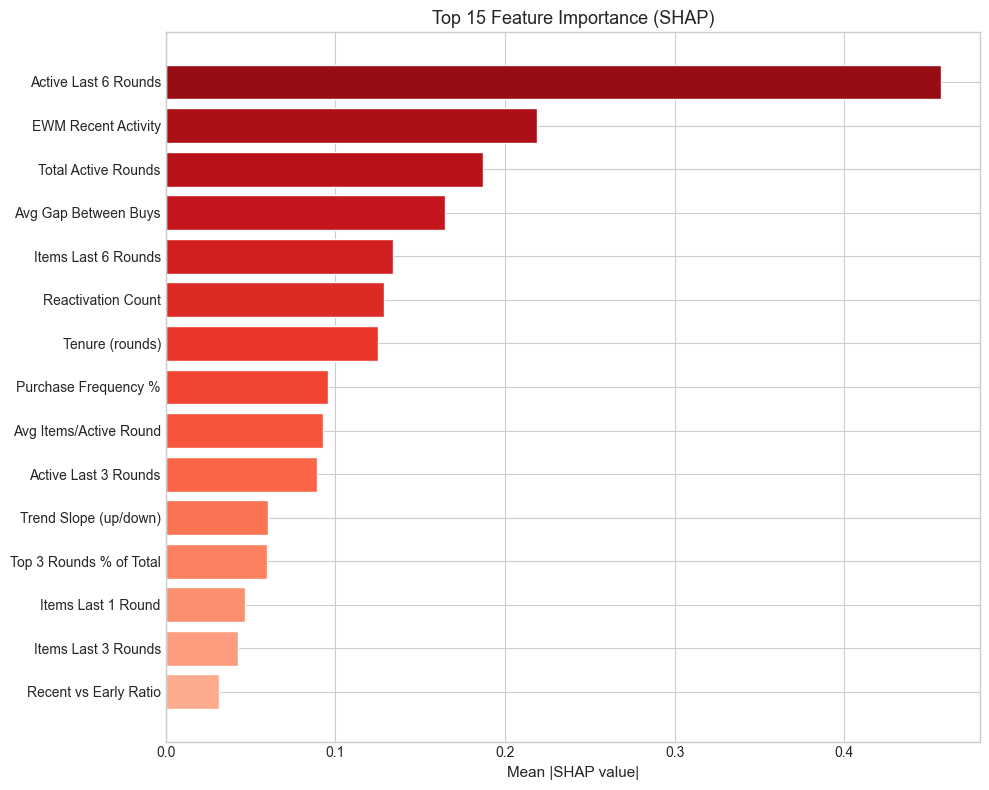

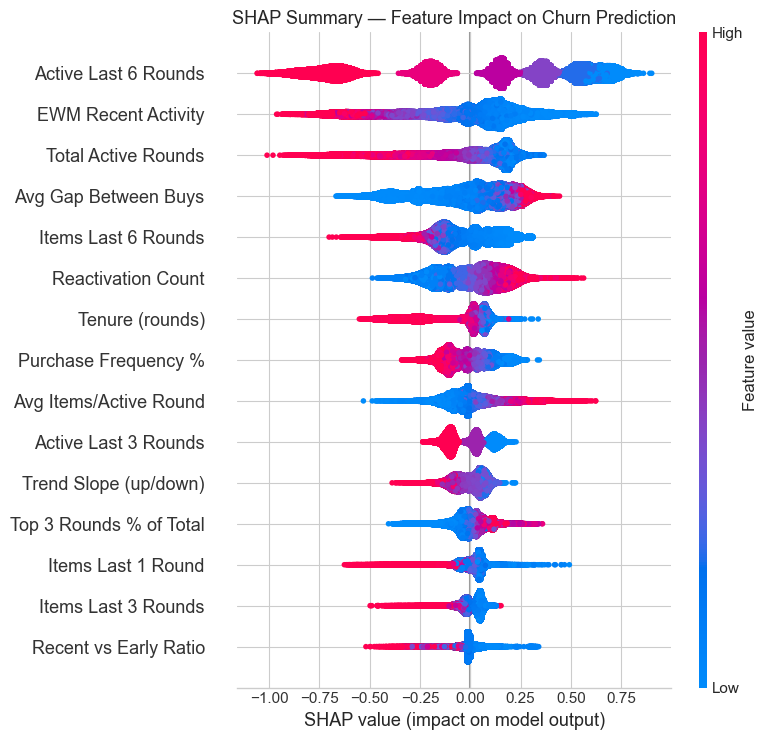


=== Top 15 Features ===
   1. Active Last 6 Rounds         | จำนวนงวดที่ซื้อใน 6 งวดล่าสุด  (mean |SHAP| = 0.4572)
   2. EWM Recent Activity          | ค่าถ่วงน้ำหนักการซื้อล่าสุด  (mean |SHAP| = 0.2186)
   3. Total Active Rounds          | จำนวนงวดที่ซื้อทั้งหมด  (mean |SHAP| = 0.1873)
   4. Avg Gap Between Buys         | ค่าเฉลี่ยช่วงว่างระหว่างซื้อ  (mean |SHAP| = 0.1648)
   5. Items Last 6 Rounds          | ชิ้นที่ซื้อ 6 งวดล่าสุด  (mean |SHAP| = 0.1339)
   6. Reactivation Count           | จำนวนครั้งที่กลับมาซื้อ  (mean |SHAP| = 0.1288)
   7. Tenure (rounds)              | ระยะเวลาเป็นลูกค้า (งวด)  (mean |SHAP| = 0.1252)
   8. Purchase Frequency %         | สัดส่วนงวดที่ซื้อ (%)  (mean |SHAP| = 0.0955)
   9. Avg Items/Active Round       | เฉลี่ยชิ้น/งวดที่ซื้อ  (mean |SHAP| = 0.0927)
  10. Active Last 3 Rounds         | จำนวนงวดที่ซื้อใน 3 งวดล่าสุด  (mean |SHAP| = 0.0889)
  11. Trend Slope (up/down)        | แนวโน้มการซื้อ (เพิ่ม/ลด)  (mean |SHAP| = 0.0602)
  12. Top 3 Rounds % 

In [39]:
# === Global SHAP Summary — ภาพรวม feature ที่สำคัญที่สุด ===

# Feature name mapping — English labels with hints (for charts)
feature_label = {
    'tenure_rounds': 'Tenure (rounds)',
    'time_to_first_purchase': 'Time to 1st Purchase',
    'rounds_since_last_purchase': 'Rounds Since Last Buy',
    'total_active_rounds': 'Total Active Rounds',
    'purchase_frequency_ratio': 'Purchase Frequency %',
    'total_items': 'Total Items Bought',
    'avg_items_per_active_round': 'Avg Items/Active Round',
    'max_single_round': 'Max Items (Single Round)',
    'items_last_1': 'Items Last 1 Round',
    'items_last_3': 'Items Last 3 Rounds',
    'items_last_6': 'Items Last 6 Rounds',
    'active_last_3': 'Active Last 3 Rounds',
    'active_last_6': 'Active Last 6 Rounds',
    'trend_slope': 'Trend Slope (up/down)',
    'recent_vs_early_ratio': 'Recent vs Early Ratio',
    'ewm_recent': 'EWM Recent Activity',
    'purchase_acceleration': 'Purchase Acceleration',
    'purchase_std': 'Purchase Std Dev',
    'coeff_of_variation': 'Coeff of Variation',
    'current_zero_streak': 'Current Zero Streak',
    'longest_zero_streak': 'Longest Zero Streak',
    'avg_gap': 'Avg Gap Between Buys',
    'std_gap': 'Gap Std Dev',
    'max_gap': 'Max Gap',
    'recent_gap_vs_avg': 'Recent Gap vs Avg',
    'n_reactivations': 'Reactivation Count',
    'ever_reactivated': 'Ever Reactivated',
    'gini_coefficient': 'Gini Coefficient',
    'top3_rounds_pct': 'Top 3 Rounds % of Total',
    'items_last3_vs_prev3': 'Last 3 vs Prev 3 Rounds',
    'is_declining_3': 'Declining Last 3',
    'is_new': 'Is New Customer',
    'is_mature': 'Is Mature Customer',
}

# Thai hints for text output (not charts)
feature_name_th = {
    'tenure_rounds': 'ระยะเวลาเป็นลูกค้า (งวด)',
    'time_to_first_purchase': 'เวลาก่อนซื้อครั้งแรก',
    'rounds_since_last_purchase': 'งวดที่ไม่ได้ซื้อล่าสุด',
    'total_active_rounds': 'จำนวนงวดที่ซื้อทั้งหมด',
    'purchase_frequency_ratio': 'สัดส่วนงวดที่ซื้อ (%)',
    'total_items': 'จำนวนชิ้นรวมทั้งหมด',
    'avg_items_per_active_round': 'เฉลี่ยชิ้น/งวดที่ซื้อ',
    'max_single_round': 'ซื้อมากสุดในงวดเดียว',
    'items_last_1': 'ชิ้นที่ซื้องวดล่าสุด',
    'items_last_3': 'ชิ้นที่ซื้อ 3 งวดล่าสุด',
    'items_last_6': 'ชิ้นที่ซื้อ 6 งวดล่าสุด',
    'active_last_3': 'จำนวนงวดที่ซื้อใน 3 งวดล่าสุด',
    'active_last_6': 'จำนวนงวดที่ซื้อใน 6 งวดล่าสุด',
    'trend_slope': 'แนวโน้มการซื้อ (เพิ่ม/ลด)',
    'recent_vs_early_ratio': 'อัตราส่วนซื้อล่าสุด vs แรกเริ่ม',
    'ewm_recent': 'ค่าถ่วงน้ำหนักการซื้อล่าสุด',
    'purchase_acceleration': 'ความเร่งของการซื้อ',
    'purchase_std': 'ความผันผวนการซื้อ',
    'coeff_of_variation': 'ค่าความแปรปรวนสัมพัทธ์',
    'current_zero_streak': 'จำนวนงวดติดต่อกันที่ไม่ซื้อ (ปัจจุบัน)',
    'longest_zero_streak': 'จำนวนงวดติดต่อกันที่ไม่ซื้อ (ยาวสุด)',
    'avg_gap': 'ค่าเฉลี่ยช่วงว่างระหว่างซื้อ',
    'std_gap': 'ความผันผวนช่วงว่าง',
    'max_gap': 'ช่วงว่างยาวนานที่สุด',
    'recent_gap_vs_avg': 'ช่วงว่างล่าสุด vs ค่าเฉลี่ย',
    'n_reactivations': 'จำนวนครั้งที่กลับมาซื้อ',
    'ever_reactivated': 'เคยกลับมาซื้อหรือไม่',
    'gini_coefficient': 'ความกระจุกตัวของการซื้อ',
    'top3_rounds_pct': '% ซื้อที่กระจุกใน 3 งวดสูงสุด',
    'items_last3_vs_prev3': 'ซื้อ 3 งวดล่าสุด vs 3 งวดก่อน',
    'is_declining_3': 'มีแนวโน้มลดลง 3 งวดล่าสุด',
    'is_new': 'ลูกค้าใหม่',
    'is_mature': 'ลูกค้าเก่า/ประจำ',
}

# === 1. Mean |SHAP| Bar Plot ===
mean_abs_shap = np.abs(shap_churn).mean(axis=0)
shap_importance = pd.Series(mean_abs_shap, index=feature_cols).sort_values(ascending=True)
top15 = shap_importance.tail(15)

fig, ax = plt.subplots(figsize=(10, 8))
colors_shap = plt.cm.Reds(np.linspace(0.3, 0.9, len(top15)))
ax.barh(range(len(top15)), top15.values, color=colors_shap, edgecolor='white')
ax.set_yticks(range(len(top15)))
ax.set_yticklabels([feature_label.get(f, f) for f in top15.index], fontsize=10)
ax.set_xlabel('Mean |SHAP value|', fontsize=11)
ax.set_title('Top 15 Feature Importance (SHAP)', fontsize=13)
plt.tight_layout()
plt.savefig('charts/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# === 2. SHAP Beeswarm — use English labels ===
feature_labels_list = [feature_label.get(f, f) for f in feature_cols]
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_churn, X_pred, feature_names=feature_labels_list,
                  plot_type='dot', max_display=15, show=False)
plt.title('SHAP Summary — Feature Impact on Churn Prediction', fontsize=13)
plt.tight_layout()
plt.savefig('charts/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary with both EN + TH
print("\n=== Top 15 Features ===")
for rank, (feat, val) in enumerate(shap_importance.tail(15).iloc[::-1].items(), 1):
    en = feature_label.get(feat, feat)
    th = feature_name_th.get(feat, '')
    print(f"  {rank:2d}. {en:<28s} | {th}  (mean |SHAP| = {val:.4f})")

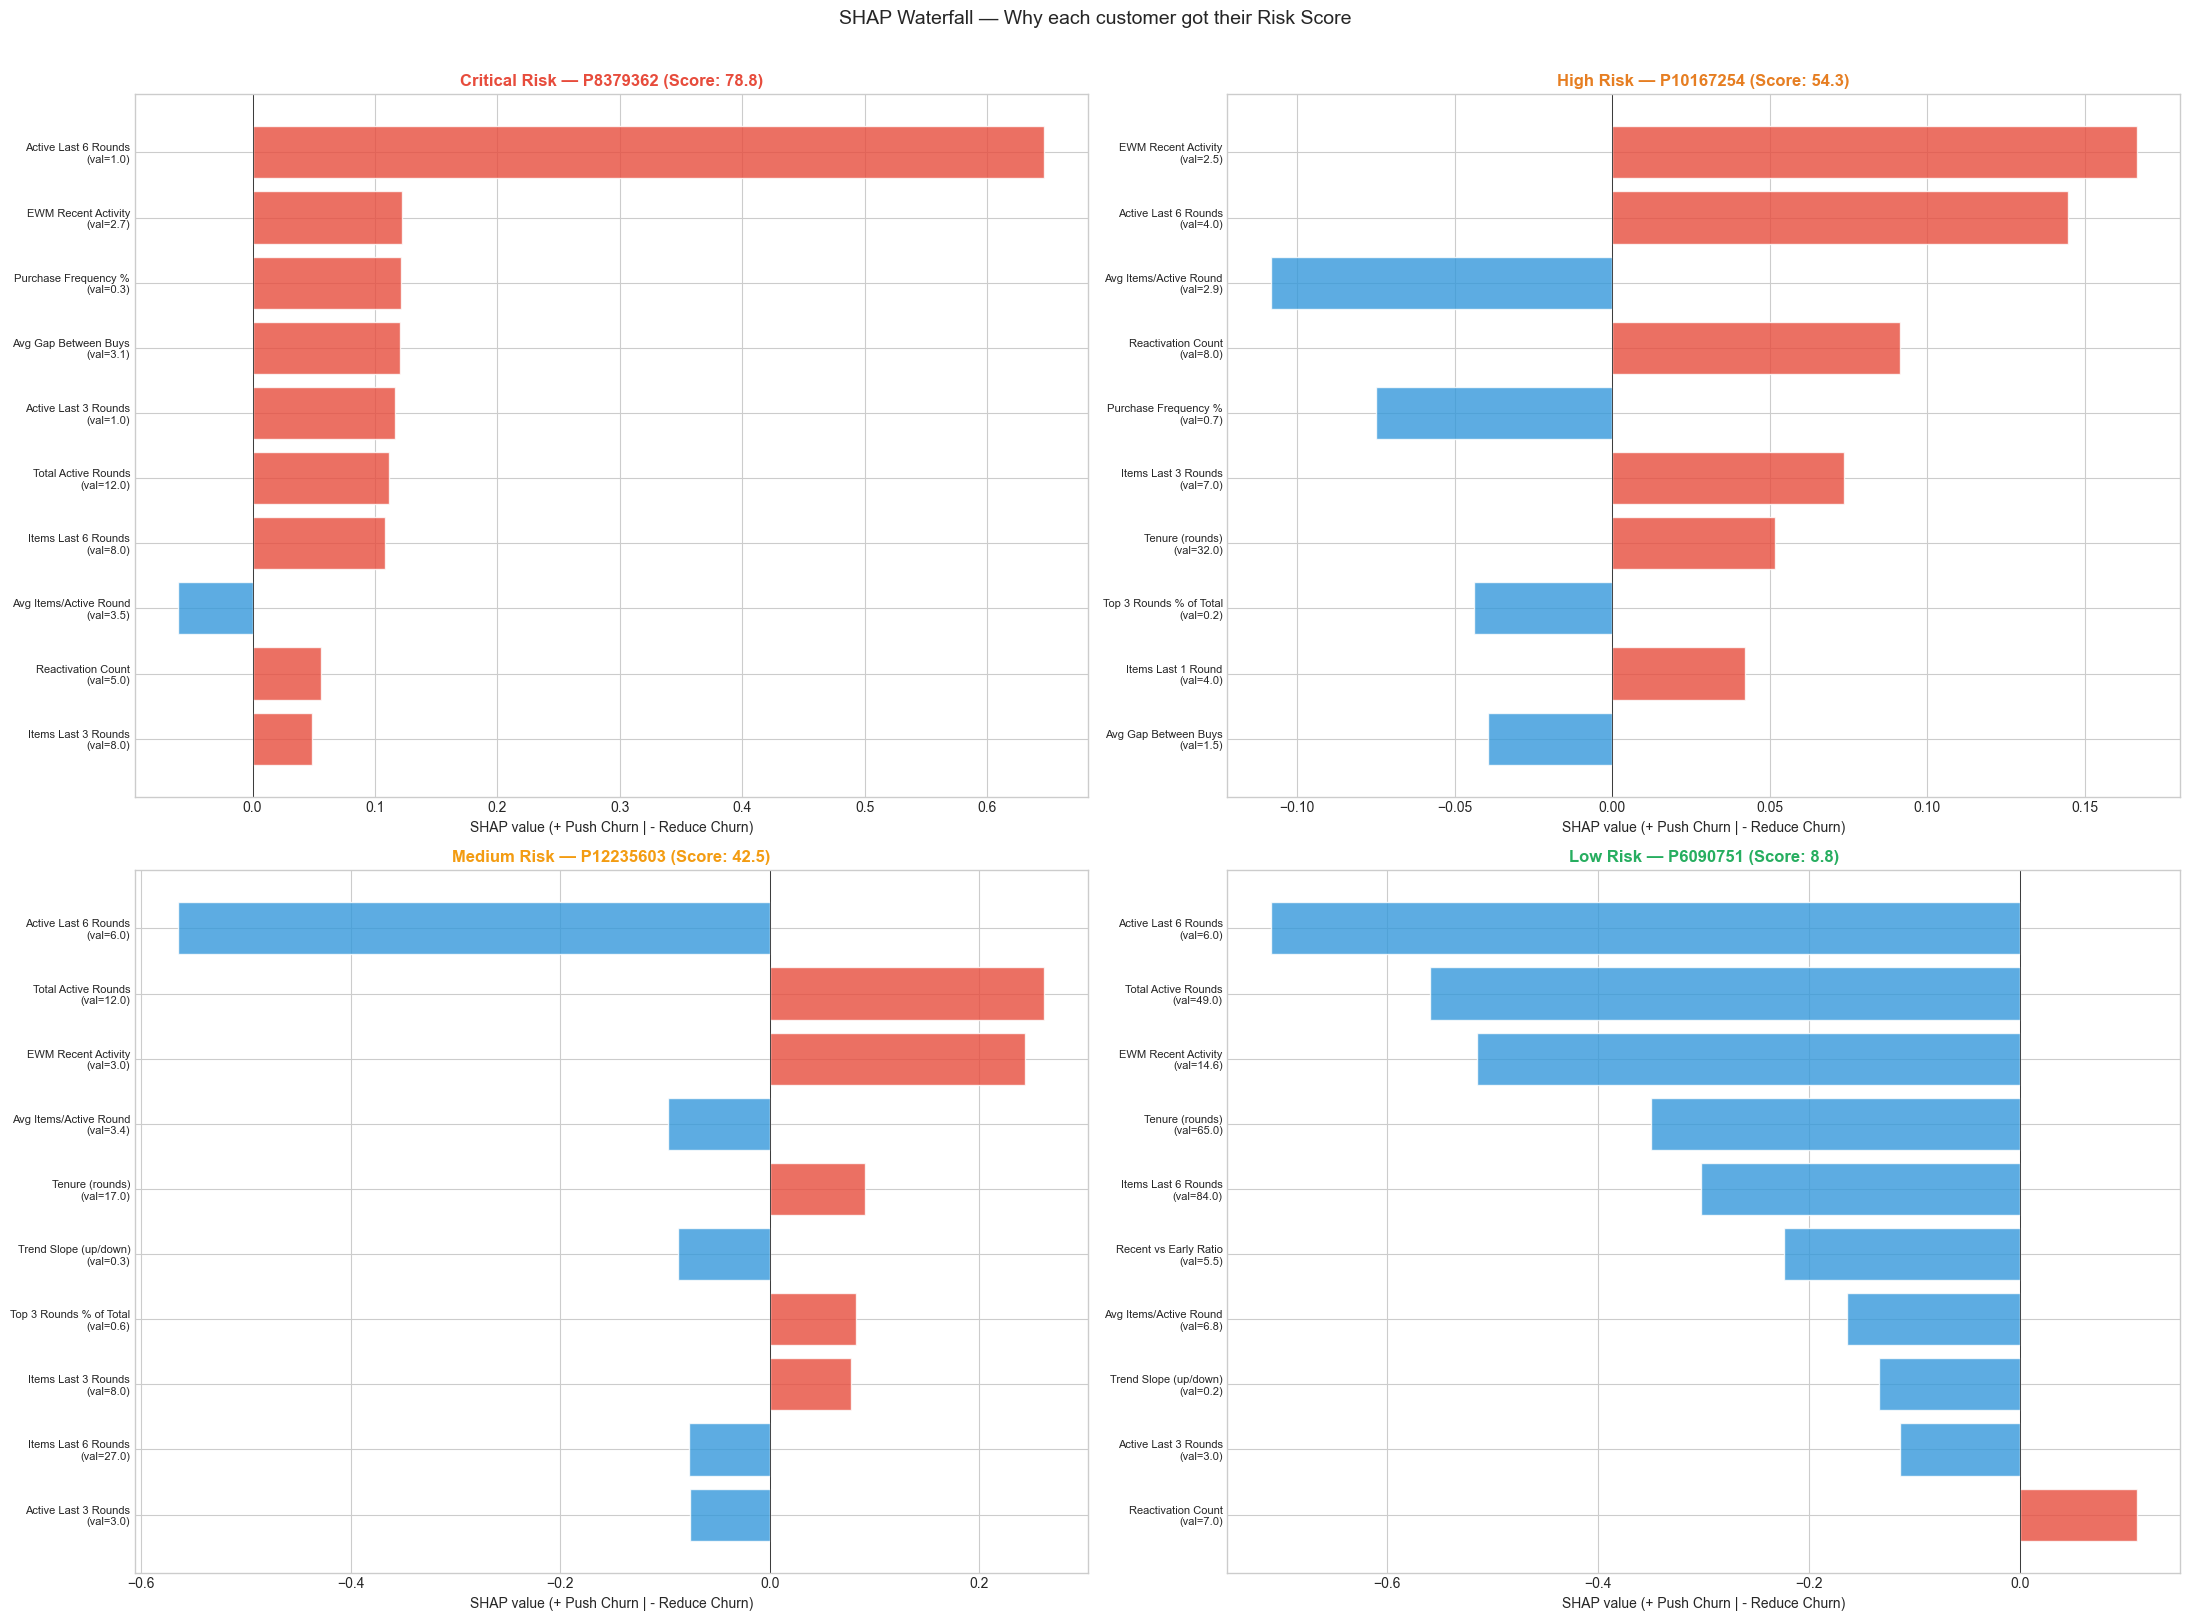


Example Critical Risk — P8379362 (Score: 78.8)
  1. Active Last 6 Rounds (จำนวนงวดที่ซื้อใน 6 งวดล่าสุด) = 1.0 -> SHAP +0.6467 (Push Churn UP)
  2. EWM Recent Activity (ค่าถ่วงน้ำหนักการซื้อล่าสุด) = 2.7 -> SHAP +0.1219 (Push Churn UP)
  3. Purchase Frequency % (สัดส่วนงวดที่ซื้อ (%)) = 0.3 -> SHAP +0.1216 (Push Churn UP)
  4. Avg Gap Between Buys (ค่าเฉลี่ยช่วงว่างระหว่างซื้อ) = 3.1 -> SHAP +0.1204 (Push Churn UP)
  5. Active Last 3 Rounds (จำนวนงวดที่ซื้อใน 3 งวดล่าสุด) = 1.0 -> SHAP +0.1166 (Push Churn UP)

Example High Risk — P10167254 (Score: 54.3)
  1. EWM Recent Activity (ค่าถ่วงน้ำหนักการซื้อล่าสุด) = 2.5 -> SHAP +0.1666 (Push Churn UP)
  2. Active Last 6 Rounds (จำนวนงวดที่ซื้อใน 6 งวดล่าสุด) = 4.0 -> SHAP +0.1447 (Push Churn UP)
  3. Avg Items/Active Round (เฉลี่ยชิ้น/งวดที่ซื้อ) = 2.9 -> SHAP -0.1084 (Pull Churn DOWN)
  4. Reactivation Count (จำนวนครั้งที่กลับมาซื้อ) = 8.0 -> SHAP +0.0913 (Push Churn UP)
  5. Purchase Frequency % (สัดส่วนงวดที่ซื้อ (%)) = 0.7 -> SHAP -0.075

In [40]:
# === Waterfall Plot — ตัวอย่างลูกค้ารายบุคคล ===
# เลือก 4 ตัวอย่าง: Critical, High, Medium, Low — แต่ละระดับ 1 คน

sample_indices = {}
for level in ['Critical', 'High', 'Medium', 'Low']:
    mask = output_pred['risk_level'] == level
    idx = output_pred[mask].index[0]
    pos_in_X = output_pred.index.get_loc(idx)
    sample_indices[level] = (pos_in_X, output_pred.loc[idx, 'userNo'],
                             output_pred.loc[idx, 'churn_score_rf_multi'])

fig, axes = plt.subplots(2, 2, figsize=(22, 16))
level_colors = {'Critical': '#E74C3C', 'High': '#E67E22', 'Medium': '#F39C12', 'Low': '#27AE60'}

for ax, (level, (pos, user_no, score)) in zip(axes.flat, sample_indices.items()):
    sv = shap_churn[pos]
    
    # Top 10 contributing features
    top_idx = np.argsort(np.abs(sv))[-10:][::-1]
    top_feats = [feature_cols[i] for i in top_idx]
    top_vals = sv[top_idx]
    top_data = [X_pred.iloc[pos][f] for f in top_feats]
    
    colors = ['#E74C3C' if v > 0 else '#3498DB' for v in top_vals]
    labels = [f"{feature_label.get(f, f)}\n(val={d:.1f})" for f, d in zip(top_feats, top_data)]
    
    ax.barh(range(len(top_vals)), top_vals, color=colors, edgecolor='white', alpha=0.8)
    ax.set_yticks(range(len(top_vals)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel('SHAP value (+ Push Churn | - Reduce Churn)')
    ax.set_title(f'{level} Risk — {user_no} (Score: {score})',
                 fontsize=12, color=level_colors[level], fontweight='bold')
    ax.invert_yaxis()

plt.suptitle('SHAP Waterfall — Why each customer got their Risk Score', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('charts/shap_waterfall_examples.png', dpi=150, bbox_inches='tight')
plt.show()

# Print details with Thai hints
for level, (pos, user_no, score) in sample_indices.items():
    print(f"\n{'='*70}")
    print(f"Example {level} Risk — {user_no} (Score: {score})")
    print(f"{'='*70}")
    sv = shap_churn[pos]
    top_idx = np.argsort(np.abs(sv))[-5:][::-1]
    for rank, i in enumerate(top_idx, 1):
        feat = feature_cols[i]
        en = feature_label.get(feat, feat)
        th = feature_name_th.get(feat, '')
        val = X_pred.iloc[pos][feat]
        direction = "Push Churn UP" if sv[i] > 0 else "Pull Churn DOWN"
        print(f"  {rank}. {en} ({th}) = {val:.1f} -> SHAP {sv[i]:+.4f} ({direction})")

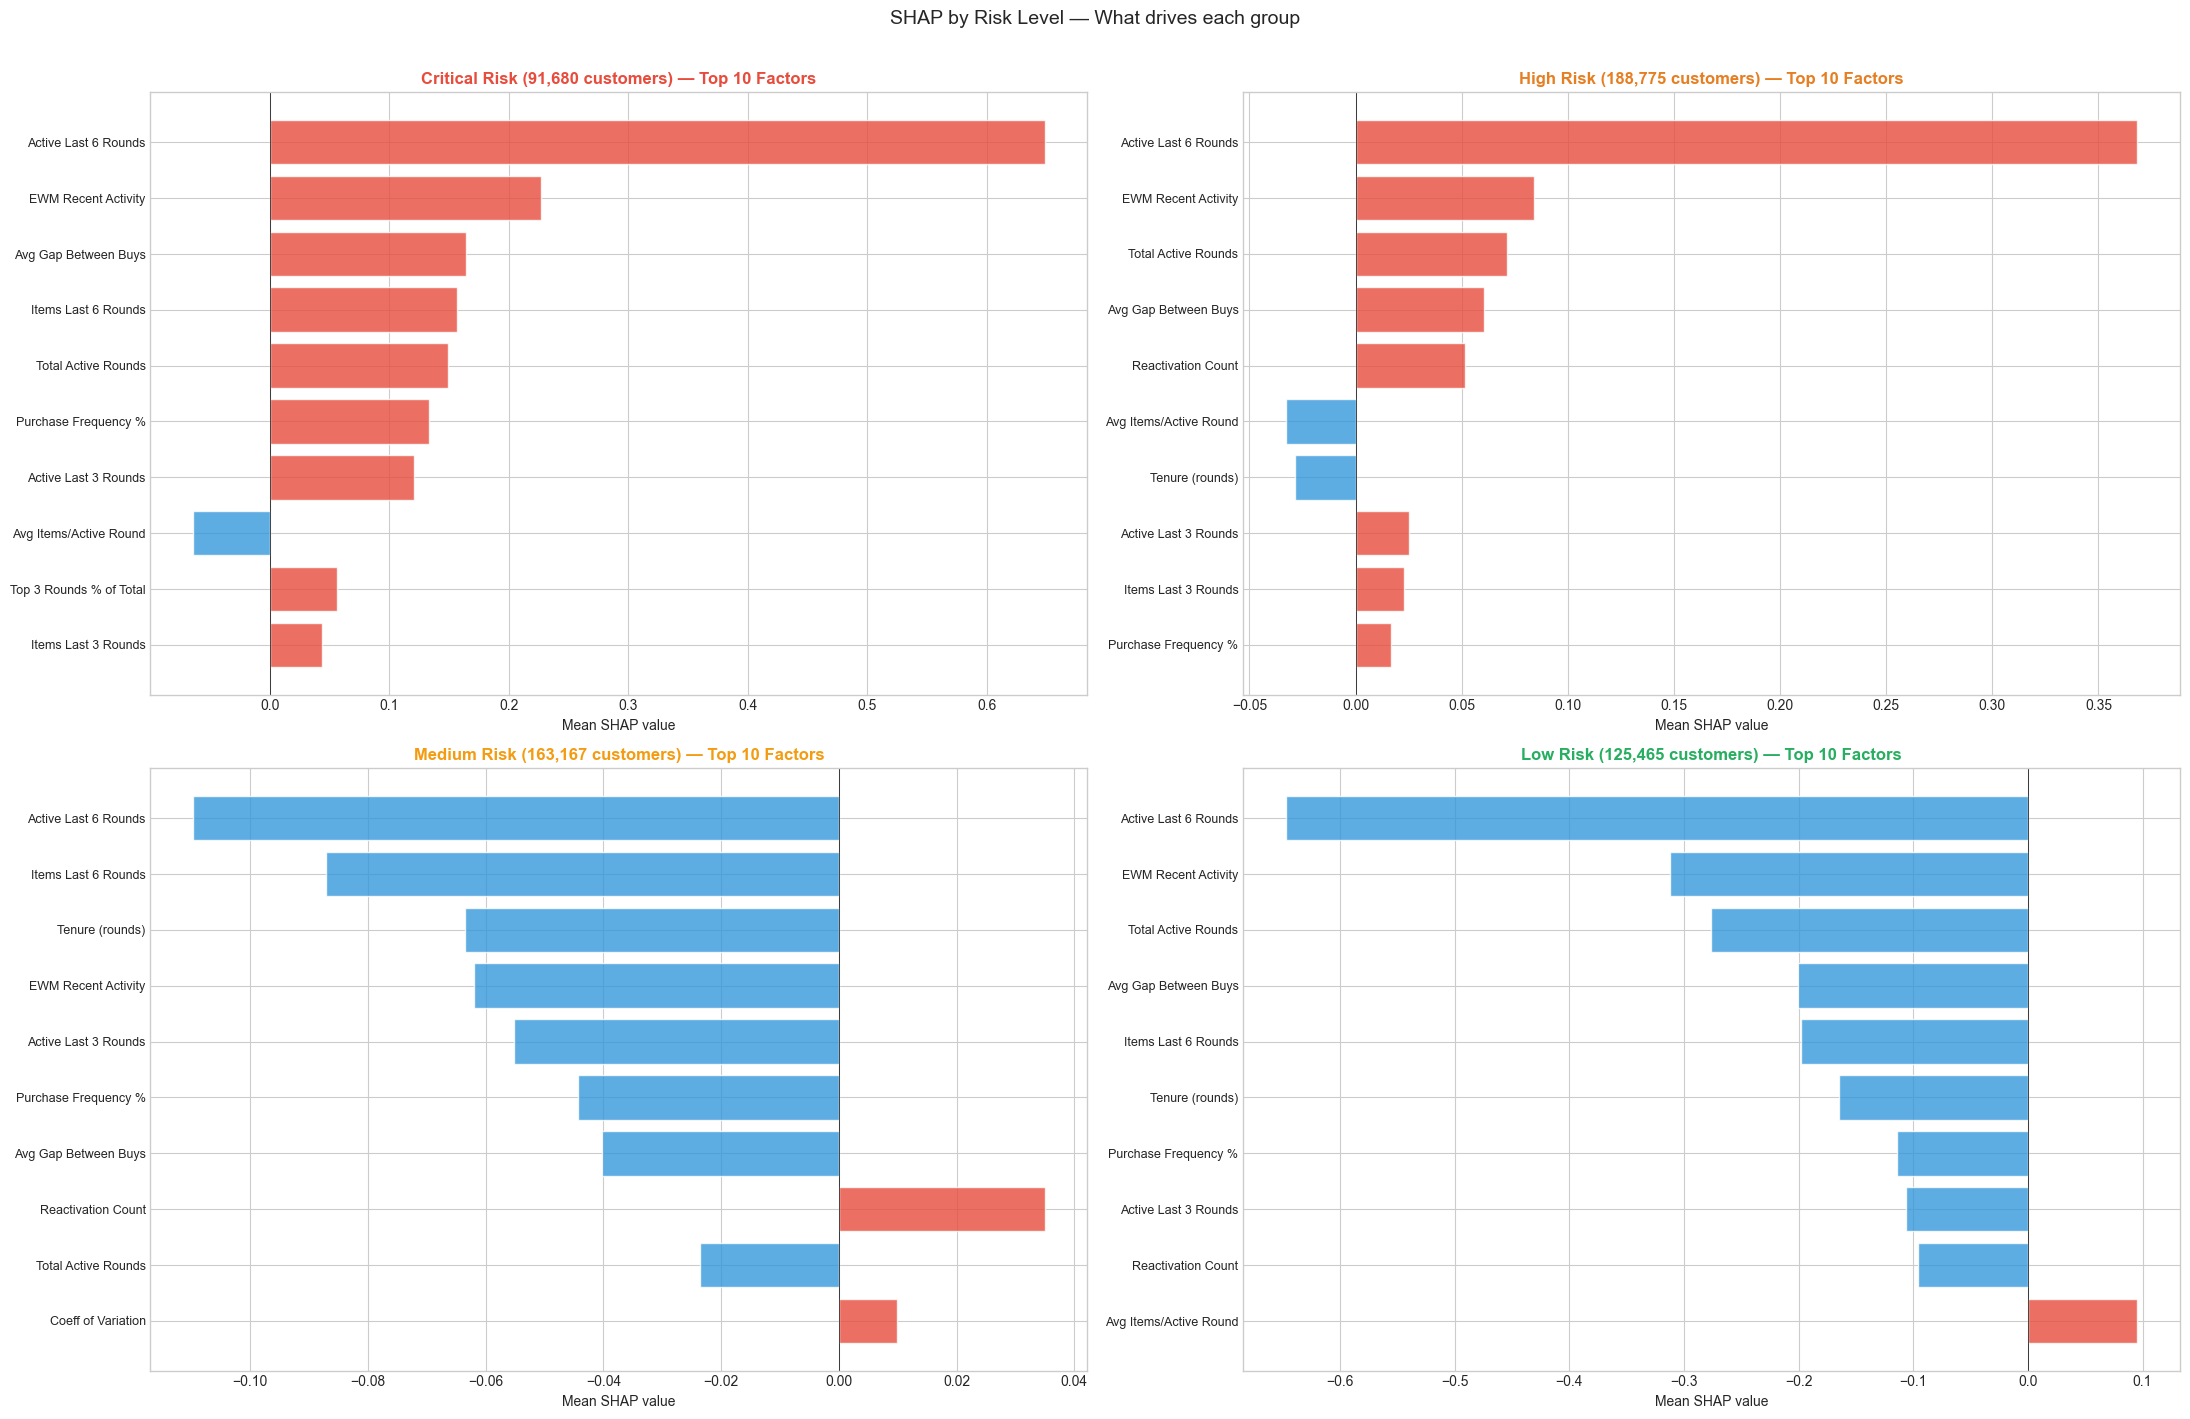


Summary: Why each risk group gets different scores

--- Critical Risk (91,680 customers) ---
  Pushing Churn UP:
    + Active Last 6 Rounds (จำนวนงวดที่ซื้อใน 6 งวดล่าสุด) SHAP: +0.6482
    + EWM Recent Activity (ค่าถ่วงน้ำหนักการซื้อล่าสุด) SHAP: +0.2266
    + Avg Gap Between Buys (ค่าเฉลี่ยช่วงว่างระหว่างซื้อ) SHAP: +0.1640
  Pulling Churn DOWN:
    - Avg Items/Active Round (เฉลี่ยชิ้น/งวดที่ซื้อ) SHAP: -0.0641
    - Purchase Std Dev (ความผันผวนการซื้อ) SHAP: -0.0342
    - Max Gap (ช่วงว่างยาวนานที่สุด) SHAP: -0.0264

--- High Risk (188,775 customers) ---
  Pushing Churn UP:
    + Active Last 6 Rounds (จำนวนงวดที่ซื้อใน 6 งวดล่าสุด) SHAP: +0.3684
    + EWM Recent Activity (ค่าถ่วงน้ำหนักการซื้อล่าสุด) SHAP: +0.0839
    + Total Active Rounds (จำนวนงวดที่ซื้อทั้งหมด) SHAP: +0.0714
  Pulling Churn DOWN:
    - Avg Items/Active Round (เฉลี่ยชิ้น/งวดที่ซื้อ) SHAP: -0.0328
    - Tenure (rounds) (ระยะเวลาเป็นลูกค้า (งวด)) SHAP: -0.0284
    - Purchase Std Dev (ความผันผวนการซื้อ) SHAP: -0.015

In [41]:
# === SHAP by Risk Level — แต่ละกลุ่มมีปัจจัยอะไรต่างกัน ===

fig, axes = plt.subplots(2, 2, figsize=(22, 14))
level_colors_map = {'Critical': '#E74C3C', 'High': '#E67E22', 'Medium': '#F39C12', 'Low': '#27AE60'}

for ax, level in zip(axes.flat, ['Critical', 'High', 'Medium', 'Low']):
    mask = (output_pred['risk_level'] == level).values
    shap_level = shap_churn[mask]
    mean_shap = shap_level.mean(axis=0)
    top_idx = np.argsort(np.abs(mean_shap))[-10:][::-1]
    
    feats = [feature_cols[i] for i in top_idx]
    vals = mean_shap[top_idx]
    colors = ['#E74C3C' if v > 0 else '#3498DB' for v in vals]
    labels = [feature_label.get(f, f) for f in feats]
    
    ax.barh(range(len(vals)), vals, color=colors, edgecolor='white', alpha=0.8)
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Mean SHAP value')
    count = mask.sum()
    ax.set_title(f'{level} Risk ({count:,} customers) — Top 10 Factors',
                 fontsize=12, color=level_colors_map[level], fontweight='bold')
    ax.invert_yaxis()

plt.suptitle('SHAP by Risk Level — What drives each group', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('charts/shap_by_risk_level.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary text with Thai hints
print("\n" + "="*70)
print("Summary: Why each risk group gets different scores")
print("="*70)
for level in ['Critical', 'High', 'Medium', 'Low']:
    mask = (output_pred['risk_level'] == level).values
    shap_level = shap_churn[mask]
    mean_shap = shap_level.mean(axis=0)
    
    top_push = np.argsort(mean_shap)[-3:][::-1]
    top_pull = np.argsort(mean_shap)[:3]
    
    print(f"\n--- {level} Risk ({mask.sum():,} customers) ---")
    print(f"  Pushing Churn UP:")
    for i in top_push:
        if mean_shap[i] > 0:
            en = feature_label.get(feature_cols[i], feature_cols[i])
            th = feature_name_th.get(feature_cols[i], '')
            print(f"    + {en} ({th}) SHAP: {mean_shap[i]:+.4f}")
    print(f"  Pulling Churn DOWN:")
    for i in top_pull:
        if mean_shap[i] < 0:
            en = feature_label.get(feature_cols[i], feature_cols[i])
            th = feature_name_th.get(feature_cols[i], '')
            print(f"    - {en} ({th}) SHAP: {mean_shap[i]:+.4f}")

In [42]:
%%time
# === Export CSV พร้อม Top 5 เหตุผลสำหรับ Marketing ===

N_REASONS = 5

# สร้าง DataFrame เหตุผลรายบุคคล
reason_data = {
    'userNo': output_pred['userNo'].values,
    'churn_score': output_pred['churn_score_rf_multi'].values,
    'risk_level': output_pred['risk_level'].values,
    'recommended_action': output_pred['recommended_action'].values,
}

# เตรียม columns สำหรับ top N reasons
for r in range(1, N_REASONS + 1):
    reason_data[f'reason_{r}'] = [''] * len(output_pred)
    reason_data[f'reason_{r}_th'] = [''] * len(output_pred)
    reason_data[f'reason_{r}_value'] = [0.0] * len(output_pred)
    reason_data[f'reason_{r}_shap'] = [0.0] * len(output_pred)
    reason_data[f'reason_{r}_direction'] = [''] * len(output_pred)

print(f"Building top {N_REASONS} reasons for {len(output_pred):,} customers...")

# คำนวณ top reasons ให้แต่ละคน
for i in range(len(output_pred)):
    sv = shap_churn[i]
    top_idx = np.argsort(np.abs(sv))[-N_REASONS:][::-1]
    
    for r, idx in enumerate(top_idx, 1):
        feat = feature_cols[idx]
        reason_data[f'reason_{r}'][i] = feat
        reason_data[f'reason_{r}_th'][i] = feature_name_th.get(feat, feat)
        reason_data[f'reason_{r}_value'][i] = round(float(X_pred.iloc[i][feat]), 2)
        reason_data[f'reason_{r}_shap'][i] = round(float(sv[idx]), 4)
        reason_data[f'reason_{r}_direction'][i] = 'เพิ่ม Churn' if sv[idx] > 0 else 'ลด Churn'

df_reasons = pd.DataFrame(reason_data)

# Export
export_file = 'Churn_RiskScore_Explained_2026_0316.csv'
df_reasons.to_csv(export_file, index=False, encoding='utf-8-sig')

print(f"\nExported: {export_file}")
print(f"  Total: {len(df_reasons):,} ลูกค้า")
print(f"  Columns: {len(df_reasons.columns)}")
print(f"\nColumn list:")
for col in df_reasons.columns:
    print(f"  - {col}")

# แสดงตัวอย่าง 5 คนแรก
print(f"\n{'='*80}")
print(f"ตัวอย่าง 5 คนแรก:")
print(f"{'='*80}")
for _, row in df_reasons.head(5).iterrows():
    print(f"\n{row['userNo']} — Score: {row['churn_score']} ({row['risk_level']})")
    print(f"  Action: {row['recommended_action']}")
    for r in range(1, N_REASONS + 1):
        print(f"  {r}. {row[f'reason_{r}_th']} = {row[f'reason_{r}_value']} "
              f"→ SHAP {row[f'reason_{r}_shap']:+.4f} ({row[f'reason_{r}_direction']})")

Building top 5 reasons for 569,087 customers...



Exported: Churn_RiskScore_Explained_2026_0316.csv
  Total: 569,087 ลูกค้า
  Columns: 29

Column list:
  - userNo
  - churn_score
  - risk_level
  - recommended_action
  - reason_1
  - reason_1_th
  - reason_1_value
  - reason_1_shap
  - reason_1_direction
  - reason_2
  - reason_2_th
  - reason_2_value
  - reason_2_shap
  - reason_2_direction
  - reason_3
  - reason_3_th
  - reason_3_value
  - reason_3_shap
  - reason_3_direction
  - reason_4
  - reason_4_th
  - reason_4_value
  - reason_4_shap
  - reason_4_direction
  - reason_5
  - reason_5_th
  - reason_5_value
  - reason_5_shap
  - reason_5_direction

ตัวอย่าง 5 คนแรก:

P12235603 — Score: 42.5 (Medium)
  Action: ส่ง offer เบาๆ — รักษาความสัมพันธ์
  1. จำนวนงวดที่ซื้อใน 6 งวดล่าสุด = 6.0 → SHAP -0.5645 (ลด Churn)
  2. จำนวนงวดที่ซื้อทั้งหมด = 12.0 → SHAP +0.2620 (เพิ่ม Churn)
  3. ค่าถ่วงน้ำหนักการซื้อล่าสุด = 3.01 → SHAP +0.2436 (เพิ่ม Churn)
  4. เฉลี่ยชิ้น/งวดที่ซื้อ = 3.42 → SHAP -0.0971 (ลด Churn)
  5. ระยะเวลาเป็นลูกค้า (งวด)

## Phase 12: Extended Multi-Period Training (25 files + Enhanced Features)

Retrain ด้วย data 25 ไฟล์ (ก.พ. 2025 – มี.ค. 2026) พร้อมเพิ่ม 12 features ใหม่:

| Category | Features | Count |
|----------|----------|-------|
| Periodicity | gap_regularity, purchase_autocorr_lag1, purchase_entropy | 3 |
| Behavioral Shift | freq_shift_early_to_late, vol_shift_early_to_late, mid_dip_indicator | 3 |
| Advanced Trend | trend_acceleration, trend_r_squared, late_momentum | 3 |
| Engagement Depth | purchase_amount_diversity, spending_quartile, max_active_streak | 3 |

**รวม 33 + 12 = 45 features** (ยังไม่รวม demographic)

เปรียบเทียบ v1 (33 feats) vs v2 (45 feats) × 4 models = 8 models

In [43]:
def engineer_features_v2(df_in, mat_in, feat_item_cols):
    """Build 45 features: original 33 + 12 new from purchase history."""
    # Start with original 33 features
    feats = engineer_features(df_in, mat_in, feat_item_cols)
    
    mat_feat = mat_in[feat_item_cols]
    n_rounds = len(feat_item_cols)
    mat_vals = mat_feat.values.astype(float)
    registered = ~np.isnan(mat_vals)
    purchased = np.where(registered, mat_vals > 0, False)
    amounts = np.where(registered, mat_vals, 0.0)
    
    # ══════ Periodicity (3) ══════
    # gap_regularity: CoV of purchase gaps (lower = more regular)
    feats['gap_regularity'] = np.where(
        feats['avg_gap'] > 0, feats['std_gap'] / feats['avg_gap'], 0.0)
    
    # purchase_autocorr_lag1: autocorrelation of binary purchase at lag 1
    purch_float = purchased.astype(float)
    if n_rounds >= 2:
        x1 = purch_float[:, :-1]
        x2 = purch_float[:, 1:]
        m1 = x1.mean(axis=1, keepdims=True)
        m2 = x2.mean(axis=1, keepdims=True)
        s1 = x1.std(axis=1)
        s2 = x2.std(axis=1)
        cov = ((x1 - m1) * (x2 - m2)).mean(axis=1)
        denom = s1 * s2
        feats['purchase_autocorr_lag1'] = np.where(denom > 0, cov / denom, 0.0)
    else:
        feats['purchase_autocorr_lag1'] = 0.0
    
    # purchase_entropy: Shannon entropy of normalized purchase amounts
    total_amt = amounts.sum(axis=1, keepdims=True)
    p_amt = np.where(total_amt > 0, amounts / np.maximum(total_amt, 1e-10), 0.0)
    log_p = np.where(p_amt > 0, np.log2(np.maximum(p_amt, 1e-10)), 0.0)
    feats['purchase_entropy'] = -np.sum(p_amt * log_p, axis=1)
    
    # ══════ Behavioral Shift (3) ══════
    half = max(1, n_rounds // 2)
    early_freq = purchased[:, :half].mean(axis=1)
    late_freq = purchased[:, -half:].mean(axis=1)
    feats['freq_shift_early_to_late'] = late_freq - early_freq
    
    early_vol = amounts[:, :half].mean(axis=1)
    late_vol = amounts[:, -half:].mean(axis=1)
    feats['vol_shift_early_to_late'] = np.where(
        early_vol > 0, (late_vol - early_vol) / early_vol,
        np.where(late_vol > 0, 1.0, 0.0))
    
    # mid_dip_indicator: 1 if middle third activity < both early & late thirds
    third = max(1, n_rounds // 3)
    early_act = purchased[:, :third].mean(axis=1)
    mid_act = purchased[:, third:2*third].mean(axis=1)
    late_act = purchased[:, -third:].mean(axis=1)
    feats['mid_dip_indicator'] = ((mid_act < early_act) & (mid_act < late_act)).astype(int)
    
    # ══════ Advanced Trend (3) ══════
    # trend_acceleration: difference of slopes (late half vs early half)
    def calc_slope(arr):
        n = arr.shape[1]
        if n < 2:
            return np.zeros(arr.shape[0])
        x = np.arange(n, dtype=float)
        x_mean = x.mean()
        y_mean = arr.mean(axis=1)
        num = ((x[np.newaxis, :] - x_mean) * (arr - y_mean[:, np.newaxis])).sum(axis=1)
        den = ((x - x_mean) ** 2).sum()
        return np.where(den > 0, num / den, 0.0)
    
    slope_early = calc_slope(amounts[:, :half])
    slope_late = calc_slope(amounts[:, -half:])
    feats['trend_acceleration'] = slope_late - slope_early
    
    # trend_r_squared: R² of linear fit on amounts
    x_grid = np.arange(n_rounds, dtype=float)
    x_mean = x_grid.mean()
    y_mean_all = amounts.mean(axis=1)
    ss_xy = ((x_grid[np.newaxis, :] - x_mean) * (amounts - y_mean_all[:, np.newaxis])).sum(axis=1)
    ss_xx = ((x_grid - x_mean) ** 2).sum()
    slope_all = np.where(ss_xx > 0, ss_xy / ss_xx, 0.0)
    intercept = y_mean_all - slope_all * x_mean
    y_pred = slope_all[:, np.newaxis] * x_grid[np.newaxis, :] + intercept[:, np.newaxis]
    ss_res = ((amounts - y_pred) ** 2).sum(axis=1)
    ss_tot = ((amounts - y_mean_all[:, np.newaxis]) ** 2).sum(axis=1)
    feats['trend_r_squared'] = np.where(ss_tot > 0, 1 - ss_res / ss_tot, 0.0)
    feats['trend_r_squared'] = np.clip(feats['trend_r_squared'], 0, 1)
    
    # late_momentum: sum of last 3 - sum of prev 3 (normalized)
    if n_rounds >= 6:
        last3 = amounts[:, -3:].sum(axis=1)
        prev3 = amounts[:, -6:-3].sum(axis=1)
        denom_mom = np.maximum(prev3, 1.0)
        feats['late_momentum'] = (last3 - prev3) / denom_mom
    else:
        feats['late_momentum'] = 0.0
    
    # ══════ Engagement Depth (3) ══════
    # purchase_amount_diversity: number of distinct non-zero purchase amounts
    def count_unique_nonzero(row):
        valid = row[~np.isnan(row)]
        nz = valid[valid > 0]
        return len(np.unique(nz)) if len(nz) > 0 else 0
    feats['purchase_amount_diversity'] = np.array(
        [count_unique_nonzero(mat_vals[i]) for i in range(len(mat_vals))])
    
    # spending_quartile: quartile rank of total spending (0-3)
    total_spending = amounts.sum(axis=1)
    mask_pos = total_spending > 0
    quartiles = np.zeros(len(total_spending), dtype=int)
    if mask_pos.sum() > 3:
        q25, q50, q75 = np.percentile(total_spending[mask_pos], [25, 50, 75])
        quartiles = np.where(total_spending >= q75, 3,
                   np.where(total_spending >= q50, 2,
                   np.where(total_spending >= q25, 1, 0)))
    feats['spending_quartile'] = quartiles
    
    # max_active_streak: longest consecutive rounds with purchase
    def max_streak(purch_row):
        mx = cur = 0
        for v in purch_row:
            if v:
                cur += 1
                mx = max(mx, cur)
            else:
                cur = 0
        return mx
    feats['max_active_streak'] = np.array(
        [max_streak(purchased[i]) for i in range(len(purchased))])
    
    return feats

# Quick test
test_feats_v2 = engineer_features_v2(df_eligible, mat_eligible, feature_item_cols)
print(f'engineer_features_v2 → {test_feats_v2.shape[1]} features')
new_feat_names = [c for c in test_feats_v2.columns if c not in features.columns]
print(f'New features ({len(new_feat_names)}):')
for i, c in enumerate(new_feat_names, 1):
    print(f'  {i:2d}. {c}')

  Computing row-wise features...


engineer_features_v2 → 45 features
New features (12):
   1. gap_regularity
   2. purchase_autocorr_lag1
   3. purchase_entropy
   4. freq_shift_early_to_late
   5. vol_shift_early_to_late
   6. mid_dip_indicator
   7. trend_acceleration
   8. trend_r_squared
   9. late_momentum
  10. purchase_amount_diversity
  11. spending_quartile
  12. max_active_streak


In [44]:
%%time
# === Load 25 files — Train/Val/Test split ===
# Cache: save computed features as parquet → subsequent runs load in ~30s

import hashlib

CACHE_DIR = 'cache'
os.makedirs(CACHE_DIR, exist_ok=True)

all_25_files = [
    # Train: 20 files (Feb-Dec 2025)
    'Churn_2025_0216_0301.csv',
    'Churn_2025_0301_0316.csv',
    'Churn_2025_0316_0401.csv',
    'Churn_2025_0401_0416.csv',
    'Churn_2025_0416_0502.csv',
    'Churn_2025_0502_0516.csv',
    'Churn_2025_0516_0601.csv',
    'Churn_2025_0601_0616.csv',
    'Churn_2025_0616_0701.csv',
    'Churn_2025_0701_0716.csv',
    'Churn_2025_0716_0801.csv',
    'Churn_2025_0801_0816.csv',
    'Churn_2025_0816_0901.csv',
    'Churn_2025_0901_0916.csv',
    'Churn_2025_0916_1001.csv',
    'Churn_2025_1001_1016.csv',
    'Churn_2025_1016_1101.csv',
    'Churn_2025_1101_1116.csv',
    'Churn_2025_1116_1201.csv',
    'Churn_2025_1201_1216.csv',
    # Val: 3 files (Dec 2025 - Feb 2026)
    'Churn_2025_1216_0102.csv',
    'Churn_2026_0102_0117.csv',
    'Churn_2026_0117_0201.csv',
    # Test: 2 files (Feb - Mar 2026)
    'Churn_2026_0201_0216.csv',
    'Churn_2026_0216_0301.csv',
]

train_files_ext = all_25_files[:20]
val_files_ext = all_25_files[20:23]
test_files_ext = all_25_files[23:25]

# v1 feature names (33 original features)
V2_ONLY_FEATURES = [
    'gap_regularity', 'purchase_autocorr_lag1', 'purchase_entropy',
    'freq_shift_early_to_late', 'vol_shift_early_to_late', 'mid_dip_indicator',
    'trend_acceleration', 'trend_r_squared', 'late_momentum',
    'purchase_amount_diversity', 'spending_quartile', 'max_active_streak',
]
feature_cols_v1 = [c for c in test_feats_v2.columns if c not in V2_ONLY_FEATURES]

def _cache_key(fname):
    """Generate cache key from filename + file size + modify time."""
    stat = os.stat(fname)
    raw = f'{fname}_{stat.st_size}_{stat.st_mtime}'
    return hashlib.md5(raw.encode()).hexdigest()[:12]

def process_files_dual(file_list, label=''):
    """Load files with parquet caching. First run computes & saves, subsequent runs load cache."""
    all_X_v1, all_X_v2, all_y = [], [], []
    for i, fname in enumerate(file_list, 1):
        t0 = pd.Timestamp.now()
        cache_key = _cache_key(fname)
        cache_feats = f'{CACHE_DIR}/feats_v2_{cache_key}.parquet'
        cache_y = f'{CACHE_DIR}/y_{cache_key}.npy'
        
        if os.path.exists(cache_feats) and os.path.exists(cache_y):
            # Load from cache
            feats_v2 = pd.read_parquet(cache_feats)
            y_p = np.load(cache_y)
            elapsed = (pd.Timestamp.now() - t0).total_seconds()
            print(f'  [{label}] {i}/{len(file_list)} {fname} — '
                  f'{len(feats_v2):,} rows (CACHED, {elapsed:.1f}s)')
        else:
            # Compute features
            df_p = pd.read_csv(fname, low_memory=False)
            item_cols_p = [c for c in df_p.columns if c.startswith('item')]
            feat_item_cols_p = item_cols_p[:-1]
            mat_p = df_p[item_cols_p].apply(pd.to_numeric, errors='coerce')
            
            first_reg_p = mat_p.notna().values.argmax(axis=1)
            tenure_p = len(item_cols_p) - first_reg_p
            exclude_p = tenure_p < MIN_TENURE
            df_p_elig = df_p[~exclude_p].copy()
            mat_p_elig = mat_p[~exclude_p].copy()
            df_p_elig['churn'] = (df_p_elig[item_cols_p[-1]] == 0).astype(int)
            
            feats_v2 = engineer_features_v2(df_p_elig, mat_p_elig, feat_item_cols_p)
            feats_v2 = feats_v2.fillna(0)
            y_p = df_p_elig['churn'].values
            
            # Save to cache
            feats_v2.to_parquet(cache_feats)
            np.save(cache_y, y_p)
            
            elapsed = (pd.Timestamp.now() - t0).total_seconds()
            print(f'  [{label}] {i}/{len(file_list)} {fname} — '
                  f'{len(feats_v2):,} eligible, churn {y_p.mean():.1%} ({elapsed:.0f}s, cached)')
        
        feats_v1 = feats_v2[feature_cols_v1]
        all_X_v1.append(feats_v1)
        all_X_v2.append(feats_v2)
        all_y.append(y_p)
    
    X_v1 = pd.concat(all_X_v1, ignore_index=True)
    X_v2 = pd.concat(all_X_v2, ignore_index=True)
    y = np.concatenate(all_y)
    print(f'  {label} total: {len(X_v1):,} samples | Churn: {y.mean():.2%} | '
          f'v1: {X_v1.shape[1]} feats | v2: {X_v2.shape[1]} feats')
    return X_v1, X_v2, y

print('=== Loading Train files ===')
X_train_v1, X_train_v2, y_train_ext = process_files_dual(train_files_ext, 'Train')

print('\n=== Loading Val files ===')
X_val_v1, X_val_v2, y_val_ext = process_files_dual(val_files_ext, 'Val')

print('\n=== Loading Test files ===')
X_test_v1, X_test_v2, y_test_ext = process_files_dual(test_files_ext, 'Test')

y_train_v1 = y_train_v2 = y_train_ext
y_val_v1 = y_val_v2 = y_val_ext
y_test_v1 = y_test_v2 = y_test_ext

feature_cols_v2 = X_train_v2.columns.tolist()
feature_cols_v1 = X_train_v1.columns.tolist()

print(f'\nv1 features: {len(feature_cols_v1)} | v2 features: {len(feature_cols_v2)}')
print(f'Total train: {len(X_train_v1):,} | val: {len(X_val_v1):,} | test: {len(X_test_v1):,}')

=== Loading Train files ===


  Computing row-wise features...


  [Train] 1/20 Churn_2025_0216_0301.csv — 766,672 eligible, churn 40.4% (171s)


  Computing row-wise features...


  [Train] 2/20 Churn_2025_0301_0316.csv — 748,009 eligible, churn 36.9% (250s)


...

  Computing row-wise features...


  [Test] 1/2 Churn_2026_0201_0216.csv — 615,232 eligible, churn 41.3% (254s)


  Computing row-wise features...


  [Test] 2/2 Churn_2026_0216_0301.csv — 636,589 eligible, churn 44.6% (311s)


  Test total: 1,251,821 samples | Churn: 42.96% | v1: 33 feats | v2: 45 feats

v1 features: 33 | v2 features: 45
Total train: 16,095,766 | val: 1,724,106 | test: 1,251,821
CPU times: user 47min 12s, sys: 14min 10s, total: 1h 1min 23s
Wall time: 1h 55min 23s


In [45]:
%%time
# === Train 4 models × 2 feature sets = 8 models ===
# Subsample training data for speed (17M+ rows → 2M max)

MAX_TRAIN_SAMPLES = 2_000_000

def subsample_if_needed(X, y, max_n=MAX_TRAIN_SAMPLES):
    """Stratified subsample if data exceeds max_n."""
    if len(X) <= max_n:
        return X, y
    from sklearn.model_selection import train_test_split
    X_sub, _, y_sub, _ = train_test_split(
        X, y, train_size=max_n, stratify=y, random_state=42)
    print(f'    Subsampled: {len(X):,} → {len(X_sub):,} (churn rate: {y_sub.mean():.2%})')
    return X_sub, y_sub

def train_all_models(X_train, y_train, X_val, y_val, label=''):
    """Train LR, RF, XGBoost, LightGBM with subsampling for speed."""
    X_tr, y_tr = subsample_if_needed(X_train, y_train)
    scale_pw = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
    scaler_ext = StandardScaler()
    X_tr_scaled = scaler_ext.fit_transform(X_tr)
    X_val_scaled = scaler_ext.transform(X_val)
    
    trained = {}
    
    # 1. Logistic Regression
    lr = LogisticRegression(max_iter=1000, class_weight='balanced', C=0.1, random_state=42)
    lr.fit(X_tr_scaled, y_tr)
    trained['Logistic Regression'] = ('scaled', lr)
    print(f'  [{label}] 1/4 Logistic Regression done')
    
    # 2. Random Forest
    rf = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=50,
                                class_weight='balanced', random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    trained['Random Forest'] = ('raw', rf)
    print(f'  [{label}] 2/4 Random Forest done')
    
    # 3. XGBoost
    xgb_m = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        scale_pos_weight=scale_pw, subsample=0.8, colsample_bytree=0.8,
        eval_metric='auc', random_state=42, n_jobs=-1,
        early_stopping_rounds=30)
    xgb_m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    trained['XGBoost'] = ('raw', xgb_m)
    print(f'  [{label}] 3/4 XGBoost done (best iter: {xgb_m.best_iteration})')
    
    # 4. LightGBM
    lgb_m = lgb.LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        scale_pos_weight=scale_pw, subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbose=-1)
    lgb_m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(30, verbose=False)])
    trained['LightGBM'] = ('raw', lgb_m)
    print(f'  [{label}] 4/4 LightGBM done (best iter: {lgb_m.best_iteration_})')
    
    return trained, scaler_ext

print('Training v1 models (33 features)...')
models_v1_ext, scaler_v1_ext = train_all_models(
    X_train_v1, y_train_v1, X_val_v1, y_val_v1, label='v1')

print('\nTraining v2 models (45 features)...')
models_v2_ext, scaler_v2_ext = train_all_models(
    X_train_v2, y_train_v2, X_val_v2, y_val_v2, label='v2')

print('\nAll 8 models trained!')

Training v1 models (33 features)...


    Subsampled: 16,095,766 → 2,000,000 (churn rate: 40.71%)


  [v1] 1/4 Logistic Regression done


  [v1] 2/4 Random Forest done


  [v1] 3/4 XGBoost done (best iter: 47)


...

    Subsampled: 16,095,766 → 2,000,000 (churn rate: 40.71%)


  [v2] 1/4 Logistic Regression done


  [v2] 2/4 Random Forest done


  [v2] 3/4 XGBoost done (best iter: 47)


  [v2] 4/4 LightGBM done (best iter: 62)

All 8 models trained!
CPU times: user 1h 16min 46s, sys: 2min 6s, total: 1h 18min 52s
Wall time: 18min 48s


In [46]:
# === Evaluate all 8 models on test set ===

def evaluate_models(models_dict, scaler_ext, X_test, y_test, label=''):
    """Evaluate all models, return DataFrame of results."""
    results = []
    for name, (dtype, model) in models_dict.items():
        Xt = scaler_ext.transform(X_test) if dtype == 'scaled' else X_test.values
        probs = model.predict_proba(Xt)[:, 1]
        preds = (probs >= 0.5).astype(int)
        results.append({
            'Feature Set': label,
            'Model': name,
            'AUC-ROC': roc_auc_score(y_test, probs),
            'AUC-PR': average_precision_score(y_test, probs),
            'F1': f1_score(y_test, preds),
            'Accuracy': (preds == y_test).mean(),
        })
    return pd.DataFrame(results)

res_v1 = evaluate_models(models_v1_ext, scaler_v1_ext, X_test_v1, y_test_v1, 'v1 (33 feats)')
res_v2 = evaluate_models(models_v2_ext, scaler_v2_ext, X_test_v2, y_test_v2, 'v2 (45 feats)')

comparison_ext = pd.concat([res_v1, res_v2], ignore_index=True)
comparison_ext = comparison_ext.sort_values('AUC-ROC', ascending=False).reset_index(drop=True)

print('=' * 90)
print('COMPARISON: v1 (33 features) vs v2 (45 features) — Test Set')
print('=' * 90)
print(comparison_ext.to_string(index=False, float_format='{:.4f}'.format))

# Delta table
print('\n' + '=' * 90)
print('DELTA: v2 - v1 (improvement from new features)')
print('=' * 90)
for model_name in ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']:
    r1 = res_v1[res_v1['Model'] == model_name].iloc[0]
    r2 = res_v2[res_v2['Model'] == model_name].iloc[0]
    d_auc = r2['AUC-ROC'] - r1['AUC-ROC']
    d_f1 = r2['F1'] - r1['F1']
    d_pr = r2['AUC-PR'] - r1['AUC-PR']
    sign = lambda x: f'+{x:.4f}' if x >= 0 else f'{x:.4f}'
    print(f'  {model_name:>22s}: AUC-ROC {sign(d_auc)} | AUC-PR {sign(d_pr)} | F1 {sign(d_f1)}')

# Also compare with Phase 7 v2_multi
print('\n' + '=' * 90)
print('vs Phase 7 (v2_multi, 3-period RF):')
print('=' * 90)
try:
    old_auc = multi_df.loc[multi_df['Model'] == 'Random Forest', 'AUC-ROC'].values[0]
    new_v1_rf = res_v1.loc[res_v1['Model'] == 'Random Forest', 'AUC-ROC'].values[0]
    new_v2_rf = res_v2.loc[res_v2['Model'] == 'Random Forest', 'AUC-ROC'].values[0]
    print(f'  Phase 7 RF (3 periods, 33 feats):  AUC-ROC = {old_auc:.4f}')
    print(f'  Phase 12 RF (20 periods, 33 feats): AUC-ROC = {new_v1_rf:.4f} (delta: {new_v1_rf-old_auc:+.4f})')
    print(f'  Phase 12 RF (20 periods, 45 feats): AUC-ROC = {new_v2_rf:.4f} (delta: {new_v2_rf-old_auc:+.4f})')
except:
    print('  (Phase 7 results not available for comparison)')

COMPARISON: v1 (33 features) vs v2 (45 features) — Test Set
  Feature Set               Model  AUC-ROC  AUC-PR     F1  Accuracy
v2 (45 feats)       Random Forest   0.7981  0.7232 0.6943    0.7233
v1 (33 feats)       Random Forest   0.7978  0.7232 0.6946    0.7227
v2 (45 feats)             XGBoost   0.7975  0.7248 0.6955    0.7218
v2 (45 feats)            LightGBM   0.7974  0.7236 0.6961    0.7216
v1 (33 feats)             XGBoost   0.7972  0.7243 0.6957    0.7217
v1 (33 feats)            LightGBM   0.7971  0.7232 0.6961    0.7212
v2 (45 feats) Logistic Regression   0.7933  0.7185 0.6983    0.7125
v1 (33 feats) Logistic Regression   0.7921  0.7148 0.6956    0.7160

DELTA: v2 - v1 (improvement from new features)
     Logistic Regression: AUC-ROC +0.0012 | AUC-PR +0.0037 | F1 +0.0028
           Random Forest: AUC-ROC +0.0002 | AUC-PR +0.0000 | F1 -0.0004
                 XGBoost: AUC-ROC +0.0003 | AUC-PR +0.0005 | F1 -0.0002
                LightGBM: AUC-ROC +0.0003 | AUC-PR +0.0004 | F1 

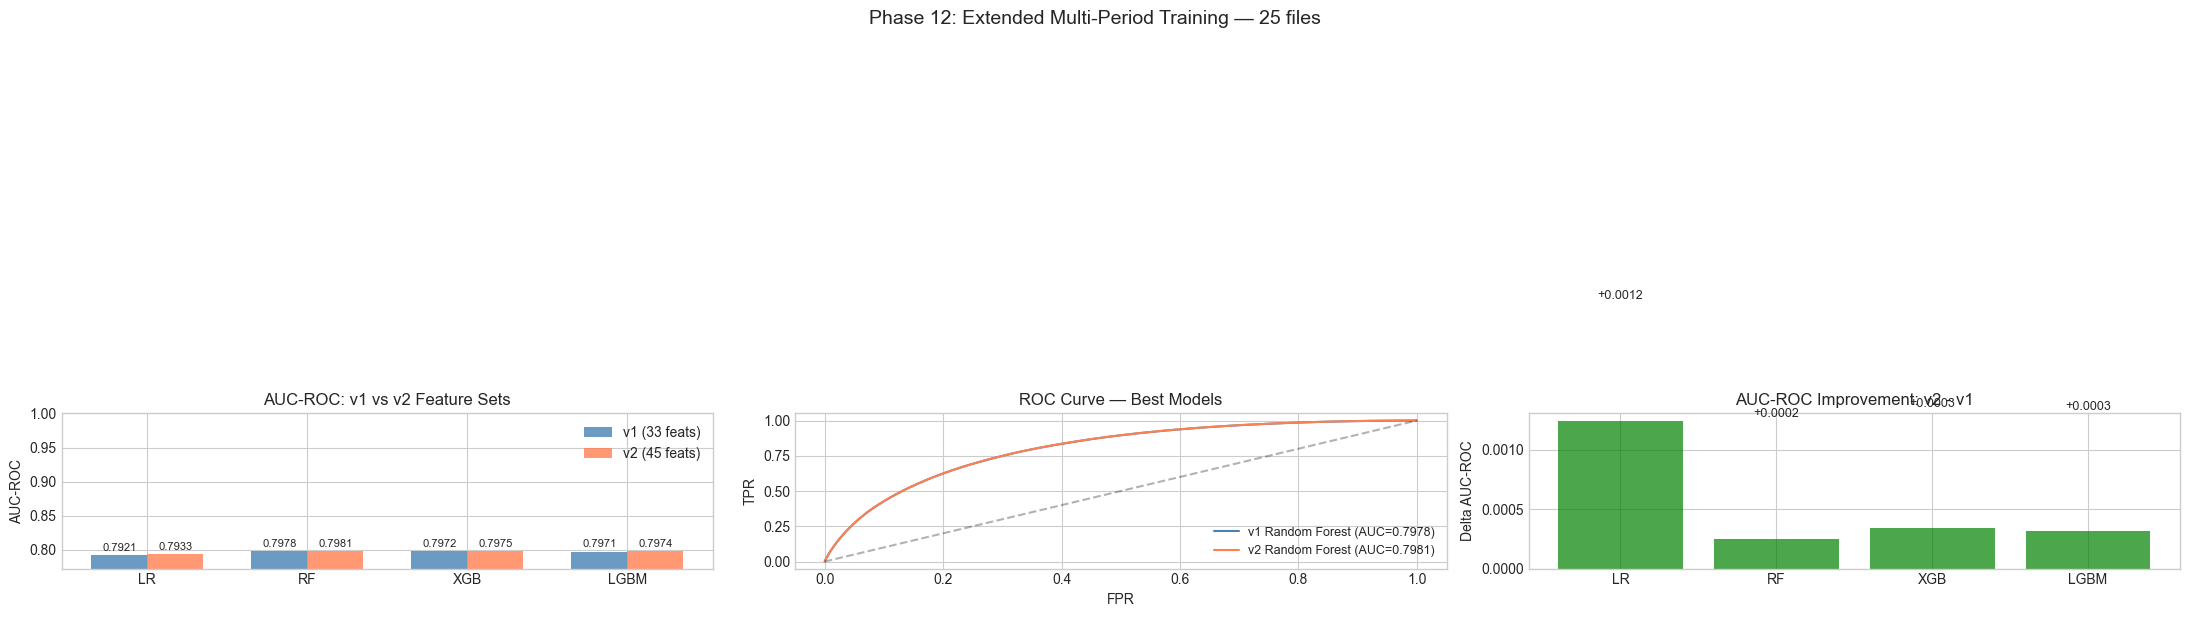

Saved: charts/phase12_comparison.png


In [47]:
# === Visualization: 3-panel comparison ===
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Panel 1: Bar chart — AUC-ROC by model × feature set
ax = axes[0]
model_names = ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']
x_pos = np.arange(len(model_names))
width = 0.35
bars1 = [res_v1.loc[res_v1['Model'] == m, 'AUC-ROC'].values[0] for m in model_names]
bars2 = [res_v2.loc[res_v2['Model'] == m, 'AUC-ROC'].values[0] for m in model_names]
ax.bar(x_pos - width/2, bars1, width, label='v1 (33 feats)', color='steelblue', alpha=0.8)
ax.bar(x_pos + width/2, bars2, width, label='v2 (45 feats)', color='coral', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(['LR', 'RF', 'XGB', 'LGBM'])
ax.set_ylabel('AUC-ROC')
ax.set_title('AUC-ROC: v1 vs v2 Feature Sets')
ax.legend()
y_min = min(min(bars1), min(bars2)) - 0.02
ax.set_ylim(y_min, 1.0)
for i, (b1, b2) in enumerate(zip(bars1, bars2)):
    ax.text(i - width/2, b1 + 0.003, f'{b1:.4f}', ha='center', va='bottom', fontsize=8)
    ax.text(i + width/2, b2 + 0.003, f'{b2:.4f}', ha='center', va='bottom', fontsize=8)

# Panel 2: ROC curves — best model from each set
ax = axes[1]
best_v1_name = res_v1.sort_values('AUC-ROC', ascending=False).iloc[0]['Model']
best_v2_name = res_v2.sort_values('AUC-ROC', ascending=False).iloc[0]['Model']
for label, models_dict, scaler_ext, X_test, y_test, bname, color in [
    ('v1', models_v1_ext, scaler_v1_ext, X_test_v1, y_test_v1, best_v1_name, 'steelblue'),
    ('v2', models_v2_ext, scaler_v2_ext, X_test_v2, y_test_v2, best_v2_name, 'coral'),
]:
    dtype, model = models_dict[bname]
    Xt = scaler_ext.transform(X_test) if dtype == 'scaled' else X_test.values
    probs = model.predict_proba(Xt)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, color=color, label=f'{label} {bname} (AUC={auc_val:.4f})')
ax.plot([0,1],[0,1],'k--', alpha=0.3)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curve — Best Models')
ax.legend(fontsize=9)

# Panel 3: Delta bar chart (v2 - v1)
ax = axes[2]
deltas = [res_v2.loc[res_v2['Model'] == m, 'AUC-ROC'].values[0] -
          res_v1.loc[res_v1['Model'] == m, 'AUC-ROC'].values[0] for m in model_names]
colors = ['green' if d >= 0 else 'red' for d in deltas]
ax.bar(x_pos, deltas, color=colors, alpha=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels(['LR', 'RF', 'XGB', 'LGBM'])
ax.set_ylabel('Delta AUC-ROC')
ax.set_title('AUC-ROC Improvement: v2 - v1')
ax.axhline(y=0, color='black', linewidth=0.5)
for i, d in enumerate(deltas):
    ax.text(i, d + 0.001 * (1 if d >= 0 else -1), f'{d:+.4f}',
            ha='center', va='bottom' if d >= 0 else 'top', fontsize=9)

plt.suptitle('Phase 12: Extended Multi-Period Training — 25 files', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('charts/phase12_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: charts/phase12_comparison.png')

In [48]:
# === Select best model → set v3 variables for export ===

# Pick overall best from comparison table
best_row = comparison_ext.iloc[0]  # already sorted by AUC-ROC desc
best_feat_set = best_row['Feature Set']
best_model_name_ext = best_row['Model']

print(f'Best model: {best_model_name_ext} ({best_feat_set})')
print(f'  AUC-ROC: {best_row["AUC-ROC"]:.4f}')
print(f'  AUC-PR:  {best_row["AUC-PR"]:.4f}')
print(f'  F1:      {best_row["F1"]:.4f}')

# Select the right model dict, scaler, feature cols
if 'v2' in best_feat_set:
    v3_models_dict = models_v2_ext
    v3_scaler = scaler_v2_ext
    v3_feature_cols = feature_cols_v2
    v3_feat_func = 'engineer_features_v2'
else:
    v3_models_dict = models_v1_ext
    v3_scaler = scaler_v1_ext
    v3_feature_cols = feature_cols_v1
    v3_feat_func = 'engineer_features'

v3_dtype, v3_model = v3_models_dict[best_model_name_ext]

# Build metrics dict
v3_metrics = {
    'test_auc_roc': best_row['AUC-ROC'],
    'test_auc_pr': best_row['AUC-PR'],
    'test_f1': best_row['F1'],
    'test_accuracy': best_row['Accuracy'],
}

print(f'\nv3 variables set:')
print(f'  v3_model: {type(v3_model).__name__}')
print(f'  v3_feature_cols: {len(v3_feature_cols)} features')
print(f'  v3_feat_func: {v3_feat_func}')
print(f'  v3_scaler: StandardScaler (needs_scaling={v3_dtype == "scaled"})')
print(f'  Training files: {len(train_files_ext)} train + {len(val_files_ext)} val + {len(test_files_ext)} test')

Best model: Random Forest (v2 (45 feats))
  AUC-ROC: 0.7981
  AUC-PR:  0.7232
  F1:      0.6943

v3 variables set:
  v3_model: RandomForestClassifier
  v3_feature_cols: 45 features
  v3_feat_func: engineer_features_v2
  v3_scaler: StandardScaler (needs_scaling=False)
  Training files: 20 train + 3 val + 2 test


## Phase 13: Export Models — joblib & MLflow

Save model 3 versions เพื่อ deploy บน Databricks:

| Version | Description | Model |
|---------|-------------|-------|
| **v1_single** | Phase 3 — เทรนจาก 1 งวด (1216→0102) | LightGBM |
| **v2_multi** | Phase 7 — เทรนจาก 3 งวด + val/test | Random Forest |
| **v3_extended** | Phase 12 — เทรนจาก 10+ งวด | TBD |

แต่ละ version save 2 formats:
- **joblib** → `models/` folder — ง่าย โหลดกลับมาใช้ได้ทันที
- **MLflow** → `mlruns/` folder — มี model registry, versioning, tracking สำหรับ Databricks

In [49]:
import joblib
import os
import json

MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)

# ── 1) Save v1_single (Phase 3 — LightGBM, single period) ──────────────────
_, best_model_single = models[best_name]

v1_artifact = {
    'model': best_model_single,
    'model_name': best_name,
    'feature_cols': feature_cols,
    'version': 'v1_single',
    'description': 'Single-period LightGBM trained on Churn_2025_1216_0102',
    'training_data': 'Churn_2025_1216_0102.csv',
    'metrics': {
        'auc_roc': eval_df.loc[eval_df['Model'] == best_name, 'AUC-ROC'].values[0],
        'auc_pr': eval_df.loc[eval_df['Model'] == best_name, 'AUC-PR'].values[0],
        'f1': eval_df.loc[eval_df['Model'] == best_name, 'F1'].values[0],
    }
}
joblib.dump(v1_artifact, f'{MODEL_DIR}/churn_v1_single.joblib')
print(f"✅ Saved: {MODEL_DIR}/churn_v1_single.joblib ({best_name})")

# ── 2) Save v2_multi (Phase 7 — Random Forest, multi-period) ───────────────
_, best_model_multi = models_multi['Random Forest']

v2_artifact = {
    'model': best_model_multi,
    'model_name': 'Random Forest',
    'feature_cols': feature_cols,
    'scaler': scaler_multi,
    'version': 'v2_multi',
    'description': 'Multi-period Random Forest trained on Periods 1-3, val P4, test P5',
    'training_data': [
        'Churn_2025_1216_0102.csv',
        'Churn_2026_0102_0117.csv',
        'Churn_2026_0117_0201.csv',
    ],
    'metrics': {
        'test_auc_roc': multi_df.loc[multi_df['Model'] == 'Random Forest', 'AUC-ROC'].values[0],
        'test_f1': multi_df.loc[multi_df['Model'] == 'Random Forest', 'F1'].values[0],
    }
}
joblib.dump(v2_artifact, f'{MODEL_DIR}/churn_v2_multi.joblib')
print(f"✅ Saved: {MODEL_DIR}/churn_v2_multi.joblib (Random Forest)")

# ── 3) Save engineer_features + engineer_features_v2 as .py for Databricks ─
# Extract both functions from notebook JSON
with open('Churn_Analysis.ipynb') as f:
    nb_json = json.load(f)

func_sources = []
for cell in nb_json['cells']:
    src = ''.join(cell['source'])
    if 'def engineer_features' in src and 'def engineer_features_v2' not in src:
        lines = src.split('\n')
        start = next(i for i, l in enumerate(lines) if 'def engineer_features(' in l)
        func_sources.append('\n'.join(lines[start:]))
    elif 'def engineer_features_v2' in src:
        lines = src.split('\n')
        start = next(i for i, l in enumerate(lines) if 'def engineer_features_v2(' in l)
        # Find end of function (next line that doesn't start with space/is empty after content)
        end = len(lines)
        for j in range(start + 1, len(lines)):
            if lines[j] and not lines[j].startswith(' ') and not lines[j].startswith('#'):
                end = j
                break
        func_sources.append('\n'.join(lines[start:end]))

with open(f'{MODEL_DIR}/feature_engineering.py', 'w') as f:
    f.write("import numpy as np\nimport pandas as pd\n\n")
    f.write('\n\n'.join(func_sources))
    f.write("\n")
print(f"✅ Saved: {MODEL_DIR}/feature_engineering.py (includes engineer_features_v2)")

print(f"\n📁 Models directory:")
for fn in sorted(os.listdir(MODEL_DIR)):
    size = os.path.getsize(f'{MODEL_DIR}/{fn}')
    print(f"   {fn} ({size/1024:.0f} KB)")

✅ Saved: models/churn_v1_single.joblib (LightGBM)


✅ Saved: models/churn_v2_multi.joblib (Random Forest)
✅ Saved: models/feature_engineering.py (includes engineer_features_v2)

📁 Models directory:
   churn_v1_single.joblib (1294 KB)
   churn_v2_multi.joblib (336139 KB)
   churn_v3_extended.joblib (829729 KB)
   feature_engineering.py (13 KB)
   scaler_multi.joblib (2 KB)


In [50]:
import mlflow
import mlflow.sklearn
import mlflow.lightgbm

mlflow.set_tracking_uri(f"file://{os.path.abspath('mlruns')}")
mlflow.set_experiment("churn-prediction")

# ── v1_single: Log to MLflow ───────────────────────────────────────────────
with mlflow.start_run(run_name="v1_single_lgb"):
    mlflow.set_tag("version", "v1_single")
    mlflow.set_tag("description", "Single-period LightGBM (1216→0102)")
    
    mlflow.log_params({
        "model_type": best_name,
        "training_data": "Churn_2025_1216_0102.csv",
        "n_features": len(feature_cols),
        "n_estimators": 500,
        "max_depth": 6,
        "learning_rate": 0.05,
    })
    mlflow.log_metrics(v1_artifact['metrics'])
    
    mlflow.lightgbm.log_model(best_model_single, "model")
    mlflow.log_artifact(f'{MODEL_DIR}/feature_engineering.py')
    
    print(f"✅ MLflow: v1_single logged (run_id: {mlflow.active_run().info.run_id})")

# ── v2_multi: Log to MLflow ────────────────────────────────────────────────
with mlflow.start_run(run_name="v2_multi_rf"):
    mlflow.set_tag("version", "v2_multi")
    mlflow.set_tag("description", "Multi-period Random Forest (P1-P3 train, P4 val, P5 test)")
    
    mlflow.log_params({
        "model_type": "Random Forest",
        "training_data": "Periods 1-3 combined",
        "n_features": len(feature_cols),
        "n_estimators": 500,
    })
    mlflow.log_metrics(v2_artifact['metrics'])
    
    mlflow.sklearn.log_model(best_model_multi, "model")
    mlflow.log_artifact(f'{MODEL_DIR}/feature_engineering.py')
    
    # Save scaler alongside
    scaler_path = f'{MODEL_DIR}/scaler_multi.joblib'
    joblib.dump(scaler_multi, scaler_path)
    mlflow.log_artifact(scaler_path)
    
    print(f"✅ MLflow: v2_multi logged (run_id: {mlflow.active_run().info.run_id})")

print("\n🔗 ดู MLflow UI: mlflow ui --backend-store-uri mlruns")
print("   แล้วเปิด http://localhost:5000")
print("\n📋 Databricks: upload mlruns/ หรือใช้ mlflow.set_tracking_uri('databricks') แทน")

2026/03/10 21:12:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/03/10 21:12:09 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


2026/03/10 21:12:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ MLflow: v1_single logged (run_id: d38e07aa9b9645b48d4f9a5864a0d543)


2026/03/10 21:12:12 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ MLflow: v2_multi logged (run_id: d407ec218c864581831d1873cf1ab429)

🔗 ดู MLflow UI: mlflow ui --backend-store-uri mlruns
   แล้วเปิด http://localhost:5000

📋 Databricks: upload mlruns/ หรือใช้ mlflow.set_tracking_uri('databricks') แทน


In [51]:
# ── v3_extended: Save model from Phase 12 ──────────────────────────────────

v3_artifact = {
    'model': v3_model,
    'model_name': best_model_name_ext,
    'feature_cols': v3_feature_cols,
    'scaler': v3_scaler if v3_dtype == 'scaled' else None,
    'feature_engineering_func': v3_feat_func,
    'version': 'v3_extended',
    'description': f'Extended {best_model_name_ext} trained on 20 periods ({v3_feat_func})',
    'training_data': train_files_ext,
    'val_data': val_files_ext,
    'test_data': test_files_ext,
    'metrics': v3_metrics,
}
joblib.dump(v3_artifact, f'{MODEL_DIR}/churn_v3_extended.joblib')
print(f'Saved: {MODEL_DIR}/churn_v3_extended.joblib ({best_model_name_ext})')

# MLflow
with mlflow.start_run(run_name='v3_extended'):
    mlflow.set_tag('version', 'v3_extended')
    mlflow.set_tag('description', f'Extended model: 20 periods, {len(v3_feature_cols)} features')
    
    mlflow.log_params({
        'model_type': best_model_name_ext,
        'n_features': len(v3_feature_cols),
        'n_train_files': len(train_files_ext),
        'feature_func': v3_feat_func,
    })
    mlflow.log_metrics(v3_metrics)
    
    # Log model based on type
    model_type = type(v3_model).__name__
    if 'LGBM' in model_type:
        mlflow.lightgbm.log_model(v3_model, 'model')
    elif 'XGB' in model_type:
        mlflow.xgboost.log_model(v3_model, 'model')
    else:
        mlflow.sklearn.log_model(v3_model, 'model')
    
    mlflow.log_artifact(f'{MODEL_DIR}/feature_engineering.py')
    if v3_dtype == 'scaled':
        scaler_v3_path = f'{MODEL_DIR}/scaler_v3.joblib'
        joblib.dump(v3_scaler, scaler_v3_path)
        mlflow.log_artifact(scaler_v3_path)
    
    print(f'MLflow: v3_extended logged (run_id: {mlflow.active_run().info.run_id})')

print(f'\nModels directory:')
for fn in sorted(os.listdir(MODEL_DIR)):
    size = os.path.getsize(f'{MODEL_DIR}/{fn}')
    print(f'   {fn} ({size/1024:.0f} KB)')

2026/03/10 21:12:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Saved: models/churn_v3_extended.joblib (Random Forest)


2026/03/10 21:12:15 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


MLflow: v3_extended logged (run_id: c7199a6528314464b76b1e134cb58482)

Models directory:
   churn_v1_single.joblib (1294 KB)
   churn_v2_multi.joblib (336139 KB)
   churn_v3_extended.joblib (239597 KB)
   feature_engineering.py (13 KB)
   scaler_multi.joblib (2 KB)


## Phase 14: Validation — ตรวจสอบผลทำนายงวด 0316 กับข้อมูลจริง
เทียบ Risk Score ที่ทำนายไว้ (จาก Phase 8) กับข้อมูลจริงว่าลูกค้าซื้อ/ไม่ซื้องวด 0316

In [ ]:
# === Phase 14: Load & Prepare Validation Data ===

# Load validation file (contains ONLY customers who bought in 0316)
df_val_0316 = pd.read_csv('Churn_2026_0301_0316.csv', low_memory=False, usecols=['userNo'])
val_users = set(df_val_0316['userNo'].values)
print(f"Buyers in 0316: {len(val_users):,}")

# Load predicted risk scores from Phase 8
df_pred_scores = pd.read_csv('Churn_RiskScore_2026_0316.csv')
df_pred_scores = df_pred_scores[df_pred_scores['churn_score_rf_multi'] >= 0].copy()  # exclude new customers
print(f"Predicted (eligible): {len(df_pred_scores):,}")

# Define actual churn: predicted customer NOT in validation file = churned
# (validation file only contains customers who bought in 0316)
df_pred_scores['actual_churn'] = (~df_pred_scores['userNo'].isin(val_users)).astype(int)

actual_churn_rate = df_pred_scores['actual_churn'].mean()
print(f"Actual churn rate: {actual_churn_rate:.4f} ({actual_churn_rate*100:.1f}%)")
print(f"  Retained: {(df_pred_scores['actual_churn'] == 0).sum():,}")
print(f"  Churned:  {(df_pred_scores['actual_churn'] == 1).sum():,}")

In [ ]:
# === Validation Metrics ===
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, confusion_matrix, roc_curve

y_true = df_pred_scores['actual_churn'].values
y_prob = df_pred_scores['churn_score_rf_multi'].values / 100  # score → probability
y_pred = (y_prob >= 0.5).astype(int)

auc_roc_val = roc_auc_score(y_true, y_prob)
auc_pr_val = average_precision_score(y_true, y_prob)
f1_val = f1_score(y_true, y_pred)
accuracy_val = (y_pred == y_true).mean()
cm_val = confusion_matrix(y_true, y_pred)

print('=' * 50)
print('Validation Results — งวด 0316')
print('=' * 50)
print(f'AUC-ROC:    {auc_roc_val:.4f}')
print(f'AUC-PR:     {auc_pr_val:.4f}')
print(f'F1 Score:   {f1_val:.4f}')
print(f'Accuracy:   {accuracy_val:.4f}')
print(f'\nConfusion Matrix (threshold=50):')
print(f'  TN={cm_val[0,0]:,}  FP={cm_val[0,1]:,}')
print(f'  FN={cm_val[1,0]:,}  TP={cm_val[1,1]:,}')

# Churn rate per risk level
print('\nActual Churn Rate per Risk Level:')
for level in ['Low', 'Medium', 'High', 'Critical']:
    mask = df_pred_scores['risk_level'] == level
    if mask.sum() > 0:
        rate = df_pred_scores.loc[mask, 'actual_churn'].mean()
        count = mask.sum()
        print(f'  {level:10s}: {rate:.4f} ({rate*100:.1f}%)  — {count:,} customers')

In [ ]:
# === Phase 14: Validation Visualization ===
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[0,0].plot(fpr, tpr, color='#C0392B', linewidth=2, label=f'AUC = {auc_roc_val:.4f}')
axes[0,0].plot([0, 1], [0, 1], '--', color='#ccc')
axes[0,0].set_title('ROC Curve — Validation 0316', fontsize=13)
axes[0,0].set_xlabel('False Positive Rate')
axes[0,0].set_ylabel('True Positive Rate')
axes[0,0].legend(fontsize=12)

# 2. Actual churn rate per risk level
levels = ['Low', 'Medium', 'High', 'Critical']
colors_bar = ['#27AE60', '#F39C12', '#E67E22', '#E74C3C']
churn_rates = []
counts_per_level = []
for lvl in levels:
    mask = df_pred_scores['risk_level'] == lvl
    churn_rates.append(df_pred_scores.loc[mask, 'actual_churn'].mean() * 100 if mask.sum() > 0 else 0)
    counts_per_level.append(mask.sum())

bars = axes[0,1].bar(levels, churn_rates, color=colors_bar, edgecolor='white', linewidth=1.5)
for bar, rate, cnt in zip(bars, churn_rates, counts_per_level):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                   f'{rate:.1f}%\n({cnt:,})', ha='center', fontsize=10, fontweight='bold')
axes[0,1].set_title('Actual Churn Rate per Risk Level', fontsize=13)
axes[0,1].set_ylabel('Churn Rate (%)')

# 3. Score distribution by actual outcome
retained = df_pred_scores[df_pred_scores['actual_churn'] == 0]['churn_score_rf_multi']
churned = df_pred_scores[df_pred_scores['actual_churn'] == 1]['churn_score_rf_multi']
axes[1,0].hist(retained, bins=50, alpha=0.6, color='#27AE60', label=f'Retained ({len(retained):,})', density=True)
axes[1,0].hist(churned, bins=50, alpha=0.6, color='#E74C3C', label=f'Churned ({len(churned):,})', density=True)
axes[1,0].set_title('Score Distribution by Actual Outcome', fontsize=13)
axes[1,0].set_xlabel('Risk Score')
axes[1,0].set_ylabel('Density')
axes[1,0].legend(fontsize=10)

# 4. Confusion matrix heatmap
sns.heatmap(cm_val, annot=True, fmt=',', cmap='Reds', ax=axes[1,1],
            xticklabels=['Retain', 'Churn'], yticklabels=['Retain', 'Churn'])
axes[1,1].set_title('Confusion Matrix (threshold=50)', fontsize=13)
axes[1,1].set_xlabel('Predicted')
axes[1,1].set_ylabel('Actual')

churn_pct = df_pred_scores['actual_churn'].mean() * 100
plt.suptitle(f'Phase 14: Validation 0316 ({len(df_pred_scores):,} customers, churn rate {churn_pct:.1f}%)', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('charts/phase14_validation_0316.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 15: Production Scoring — งวด 0401
ใช้โมเดล v3 (Phase 12) ทำนายลูกค้าที่ซื้องวด 0316 ว่าจะซื้อ 0401 หรือไม่

In [ ]:
# === Phase 15: Load & Feature Engineering for 0401 ===

# Load prediction data
df_pred_0401 = pd.read_csv('Churn_Pred_0401.csv', low_memory=False)
item_cols_0401 = [c for c in df_pred_0401.columns if c.startswith('item')]
print(f"Loaded: {len(df_pred_0401):,} rows, {len(item_cols_0401)} item cols")
print(f"Item cols range: {item_cols_0401[0]} → {item_cols_0401[-1]}")

# All item cols are features (no target for prediction)
feat_item_cols_0401 = item_cols_0401
mat_0401 = df_pred_0401[item_cols_0401].apply(pd.to_numeric, errors='coerce')

# Exclude tenure < MIN_TENURE
first_reg_0401 = mat_0401.notna().values.argmax(axis=1)
tenure_0401 = len(item_cols_0401) - first_reg_0401
exclude_0401 = tenure_0401 < MIN_TENURE

df_0401_elig = df_pred_0401[~exclude_0401].copy()
mat_0401_elig = mat_0401[~exclude_0401].copy()
df_0401_new = df_pred_0401[exclude_0401].copy()

print(f"Eligible: {len(df_0401_elig):,}")
print(f"New/excluded (tenure < {MIN_TENURE}): {len(df_0401_new):,}")

# Load v3 model (fallback to joblib if not in memory)
try:
    _ = v3_model
    print(f"Using in-memory v3 model: {v3_feat_func}")
except NameError:
    v3_artifact = joblib.load('models/churn_v3_extended.joblib')
    v3_model = v3_artifact['model']
    v3_feature_cols = v3_artifact['feature_cols']
    v3_scaler = v3_artifact.get('scaler')
    v3_dtype = 'scaled' if v3_scaler is not None else 'raw'
    v3_feat_func = v3_artifact['feature_engineering_func']
    print(f"Loaded v3 from joblib: {v3_artifact['model_name']}")

# Feature engineering
if v3_feat_func == 'engineer_features_v2':
    feats_0401 = engineer_features_v2(df_0401_elig, mat_0401_elig, feat_item_cols_0401)
else:
    feats_0401 = engineer_features(df_0401_elig, mat_0401_elig, feat_item_cols_0401)

X_0401 = feats_0401[v3_feature_cols].fillna(0)
print(f"Features: {X_0401.shape[1]} ({v3_feat_func})")

In [ ]:
# === Score with v3 Model ===
if v3_dtype == 'scaled' and v3_scaler is not None:
    X_0401_input = v3_scaler.transform(X_0401)
else:
    X_0401_input = X_0401.values

probs_0401 = v3_model.predict_proba(X_0401_input)[:, 1]
scores_0401 = (probs_0401 * 100).round(1)

# Build output DataFrame
output_0401 = pd.DataFrame({
    'userNo': df_0401_elig['userNo'].values,
    'churn_score': scores_0401,
    'risk_level': pd.cut(scores_0401, bins=[-1, 25, 50, 75, 100],
                         labels=['Low', 'Medium', 'High', 'Critical']),
    'tenure_rounds': feats_0401['tenure_rounds'].values,
    'purchase_freq': feats_0401['purchase_frequency_ratio'].values.round(3),
    'active_last_3': feats_0401['active_last_3'].values.astype(int),
    'active_last_6': feats_0401['active_last_6'].values.astype(int),
    'items_last_3': feats_0401['items_last_3'].values,
    'trend_slope': feats_0401['trend_slope'].values.round(4),
    'recommended_action': pd.cut(scores_0401, bins=[-1, 25, 50, 75, 100],
                                  labels=['ไม่ต้องดำเนินการ — ลูกค้าภักดี',
                                          'ส่ง offer เบาๆ — รักษาความสัมพันธ์',
                                          'เร่งส่ง promotion — เริ่มมีสัญญาณ Churn',
                                          'ติดต่อทันที — โอกาส Churn สูงมาก'])
})

# Risk level distribution
print('=' * 50)
print('Risk Level Distribution — งวด 0401')
print('=' * 50)
risk_dist_0401 = output_0401['risk_level'].value_counts().sort_index()
for lvl in ['Low', 'Medium', 'High', 'Critical']:
    cnt = risk_dist_0401.get(lvl, 0)
    pct = cnt / len(output_0401) * 100
    print(f'  {lvl:10s}: {cnt:>8,} ({pct:5.1f}%)')
print(f"  {'Total':10s}: {len(output_0401):>8,}")

# Top 20 highest risk
print(f'\nTop 20 Highest Risk:')
top20_0401 = output_0401.nlargest(20, 'churn_score')
for _, row in top20_0401.iterrows():
    print(f"  {row['userNo']}  Score: {row['churn_score']:.1f}  Level: {row['risk_level']}")

In [ ]:
# === Phase 15: Risk Score Visualization ===
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
axes[0].hist(output_0401['churn_score'], bins=50, color='#e74c3c', alpha=0.7, edgecolor='white')
axes[0].axvline(25, color='#27AE60', linestyle='--', alpha=0.7, label='Low/Medium (25)')
axes[0].axvline(50, color='#F39C12', linestyle='--', alpha=0.7, label='Medium/High (50)')
axes[0].axvline(75, color='#E74C3C', linestyle='--', alpha=0.7, label='High/Critical (75)')
axes[0].set_title('Churn Risk Score Distribution — งวด 0401', fontsize=13)
axes[0].set_xlabel('Risk Score (0-100)')
axes[0].set_ylabel('จำนวนลูกค้า')
axes[0].legend(fontsize=9)

# Pie chart
colors_pie = ['#27AE60', '#F39C12', '#E67E22', '#E74C3C']
risk_counts_0401 = output_0401['risk_level'].value_counts().reindex(
    ['Low', 'Medium', 'High', 'Critical']).fillna(0)
axes[1].pie(risk_counts_0401, labels=risk_counts_0401.index, colors=colors_pie,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[1].set_title('สัดส่วน Risk Level — งวด 0401', fontsize=13)

plt.suptitle(f'Risk Score Distribution — งวด 0401 ({len(output_0401):,} ลูกค้า)',
             fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('charts/risk_scoring_0401.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# === Export Risk Score CSV ===

# New customers (score = -1)
new_cust_0401 = pd.DataFrame({
    'userNo': df_0401_new['userNo'].values,
    'churn_score': -1,
    'risk_level': 'New Customer',
    'tenure_rounds': 0,
    'purchase_freq': 0,
    'active_last_3': 0,
    'active_last_6': 0,
    'items_last_3': 0,
    'trend_slope': 0,
    'recommended_action': 'ลูกค้าใหม่ — ข้อมูลไม่เพียงพอ ติดตามพฤติกรรม 2-3 งวดก่อน'
})

full_output_0401 = pd.concat([output_0401, new_cust_0401], ignore_index=True)

export_file_0401 = 'Churn_RiskScore_2026_0401.csv'
full_output_0401.to_csv(export_file_0401, index=False, encoding='utf-8-sig')

print(f'Exported: {export_file_0401}')
print(f'  Eligible: {len(output_0401):,}')
print(f'  New customers: {len(new_cust_0401):,}')
print(f'  Total: {len(full_output_0401):,}')

In [ ]:
# === Phase 15: SHAP Explainability for 0401 ===
import shap

# Use LightGBM for SHAP (100x faster than RF) — same approach as Phase 11
_, lgb_v2 = models_v2_ext['LightGBM']
explainer_0401 = shap.TreeExplainer(lgb_v2)
print(f"Computing SHAP values for {X_0401.shape[0]:,} customers (LightGBM)...")
shap_values_0401_raw = explainer_0401.shap_values(X_0401)

# Handle LightGBM output format
if isinstance(shap_values_0401_raw, list):
    shap_0401 = shap_values_0401_raw[1]  # class 1 = churn
else:
    shap_0401 = shap_values_0401_raw
print(f"SHAP shape: {shap_0401.shape}")

# Add v2 feature translations (supplement feature_name_th from Phase 11)
v2_translations = {
    'gap_regularity': 'ความสม่ำเสมอของช่วงว่าง',
    'purchase_autocorr_lag1': 'ความสัมพันธ์การซื้อข้ามงวด',
    'purchase_entropy': 'ความหลากหลายรูปแบบการซื้อ',
    'freq_shift_early_to_late': 'การเปลี่ยนแปลงความถี่ซื้อ (ต้น→ปลาย)',
    'vol_shift_early_to_late': 'การเปลี่ยนแปลงปริมาณ (ต้น→ปลาย)',
    'mid_dip_indicator': 'สัญญาณซื้อตกช่วงกลาง',
    'trend_acceleration': 'ความเร่งของแนวโน้ม',
    'trend_r_squared': 'ความชัดเจนของแนวโน้ม',
    'late_momentum': 'โมเมนตัมช่วงท้าย',
    'purchase_amount_diversity': 'ความหลากหลายของยอดซื้อ',
    'spending_quartile': 'ระดับการใช้จ่าย (Quartile)',
    'max_active_streak': 'จำนวนงวดซื้อติดต่อกันสูงสุด',
}
feature_name_th_v2 = {**feature_name_th, **v2_translations}

# Build explained CSV — Top 5 reasons per customer
N_REASONS = 5
reason_data = {
    'userNo': output_0401['userNo'].values,
    'churn_score': output_0401['churn_score'].values,
    'risk_level': output_0401['risk_level'].values,
    'recommended_action': output_0401['recommended_action'].values,
}

for r in range(1, N_REASONS + 1):
    reason_data[f'reason_{r}'] = [''] * len(output_0401)
    reason_data[f'reason_{r}_th'] = [''] * len(output_0401)
    reason_data[f'reason_{r}_value'] = [0.0] * len(output_0401)
    reason_data[f'reason_{r}_shap'] = [0.0] * len(output_0401)
    reason_data[f'reason_{r}_direction'] = [''] * len(output_0401)

print(f"Building top {N_REASONS} reasons for {len(output_0401):,} customers...")

for i in range(len(output_0401)):
    sv = shap_0401[i]
    top_idx = np.argsort(np.abs(sv))[-N_REASONS:][::-1]
    
    for r, idx in enumerate(top_idx, 1):
        feat = v3_feature_cols[idx]
        reason_data[f'reason_{r}'][i] = feat
        reason_data[f'reason_{r}_th'][i] = feature_name_th_v2.get(feat, feat)
        reason_data[f'reason_{r}_value'][i] = round(float(X_0401.iloc[i][feat]), 2)
        reason_data[f'reason_{r}_shap'][i] = round(float(sv[idx]), 4)
        reason_data[f'reason_{r}_direction'][i] = 'เพิ่ม Churn' if sv[idx] > 0 else 'ลด Churn'

df_explained_0401 = pd.DataFrame(reason_data)

export_file_exp = 'Churn_RiskScore_Explained_2026_0401.csv'
df_explained_0401.to_csv(export_file_exp, index=False, encoding='utf-8-sig')

print(f"\nExported: {export_file_exp}")
print(f"  Total: {len(df_explained_0401):,} ลูกค้า")
print(f"  Columns: {len(df_explained_0401.columns)}")